## 0) Setup & Reproducibility

In this section, we set up a clean, reproducible notebook foundation:
- Import core libraries for data wrangling and visualization.
- Define global configuration (market/game scope, visual contracts, paths).
- Centralize reusable helper functions to keep later analysis consistent and maintainable.
- Set a fixed random seed for reproducibility.

In [1]:
# =========================
# 0) Setup — Imports, Config, Visual Contract
# =========================

# --- Core ---
from datetime import datetime
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# --- Utilities (used in later steps; kept here intentionally) ---
import math
import unicodedata

SEED = 42
np.random.seed(SEED)

# =========================
# PANDAS DISPLAY OPTIONS
# =========================

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.precision", 4)

# =========================
# GLOBAL VISUAL CONTRACT
# =========================

# --- Dark analytical theme (monitoring / product analytics mindset) ---
sns.set_theme(style="dark")

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#E6E6E6",
    "xtick.color": "#AAAAAA",
    "ytick.color": "#AAAAAA",
    "grid.color": "#222222",
    "text.color": "#E6E6E6",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "figure.dpi": 120,
    "legend.frameon": False,
})

# =========================
# COUNTRY VISUAL CONTRACT
# =========================

COUNTRY_PALETTE = {
    # MAIN MARKET — STRONG ANCHOR
    "Turkey": "#163EB8",

    # EUROPE
    "United Kingdom": "#4F7FE6",
    "Germany":        "#7FA2E8",

    # NORTH AMERICA
    "United States":  "#8FD5C8",
    "Canada":         "#CFEDE4",

    # ASIA
    "Japan":          "#B9A6D8",
}

# =========================
# GAME VISUAL CONTRACT
# =========================

HIGHLIGHT_GAME = "Royal Match"

# Fixed competitor universe (used everywhere)
GAME_ORDER = [
    "Royal Match",
    "Toon Blast",
    "Candy Crush Saga",
    "Gardenscapes"
]

# Royal Match: premium blue
HIGHLIGHT_COLOR = "#1f4ed8"

# Competitors: grayscale ramp (background context)
COMPETITOR_PALETTE = {
    "Toon Blast": "#374151",        # darkest gray
    "Candy Crush Saga": "#6b7280",  # medium gray
    "Gardenscapes": "#9ca3af"       # light gray
}

def make_game_palette():
    """
    Deterministic game-color mapping:
    - Royal Match -> highlight color
    - Competitors -> fixed grayscale tones
    """
    return {HIGHLIGHT_GAME: HIGHLIGHT_COLOR, **COMPETITOR_PALETTE}

# =========================
# DATA FILE (RAW INPUT)
# =========================

DATA_FILE = "appstore_reviews.csv"

In [2]:
# =========================
# Helper Functions — EDA Utilities (Defined, Not Executed)
# =========================

# -------------------------
# Text safety & features
# -------------------------

def safe_text(x) -> str:
    if pd.isna(x):
        return ""
    text = str(x).replace("\u0000", " ").strip()
    return unicodedata.normalize("NFKC", text)


def add_text_features(df: pd.DataFrame) -> pd.DataFrame:
    df["review"] = df["review"].map(safe_text)
    df["title"] = df["title"].map(safe_text)
    df["char_count"] = df["review"].str.len()
    df["has_text"] = (df["char_count"] > 0).astype(int)
    df["word_count"] = df["review"].str.split().str.len().fillna(0).astype(int)
    return df

# -------------------------
# Core EDA profiles
# -------------------------

def review_data_profile(df: pd.DataFrame):
    """
    High-level quantitative snapshot of the dataset.
    Assumes:
      - game, country, rating, date, version, review_id exist
      - is_competitor is optional
    """

    print("\n" + "=" * 100)
    print("DATASET OVERVIEW")
    print("=" * 100)
    print(f"Total reviews: {len(df):,}")
    print(f"Games: {df['game'].nunique()} → {df['game'].unique()}")
    print(f"Countries: {df['country'].nunique()} → {df['country'].unique()}")
    print(f"Versions: {df['version'].nunique():,}")
    print(f"Unique users: {df['user_uri'].nunique():,}")

    if "is_competitor" in df.columns:
        print(f"Competitor split: {df['is_competitor'].value_counts().to_dict()}")

    print("\n" + "=" * 100)
    print("GLOBAL TIME COVERAGE")
    print("=" * 100)
    print(f"{df['date'].min().date()} → {df['date'].max().date()}")

    print("\n" + "=" * 100)
    print("TIME COVERAGE BY GAME × COUNTRY")
    print("=" * 100)
    display(
        df.groupby(["game", "country"])
          .agg(
              first_review=("date", "min"),
              last_review=("date", "max"),
              days_covered=("date", lambda x: (x.max() - x.min()).days),
              reviews=("review_id", "count"),
              n_version=("version", "nunique")
          )
          .reset_index()
          .sort_values("days_covered")
          .style
          .apply(highlight_and_bold_royal_match, axis=1)
    )

    print("\n" + "=" * 100)
    print("AVG RATING BY GAME (GLOBAL)")
    print("=" * 100)
    display(
        df.groupby("game")
          .agg(
              reviews=("rating", "count"),
              avg_rating=("rating", "mean"),
              median_rating=("rating", "median"),
              one_star_pct=("rating", lambda x: (x == 1).mean()),
              five_star_pct=("rating", lambda x: (x == 5).mean())
          )
          .reset_index()
          .sort_values("avg_rating")
          .style
          .apply(highlight_and_bold_royal_match, axis=1)
    )

    print("\n" + "=" * 100)
    print("RATING BY GAME × COUNTRY")
    print("=" * 100)
    display(
        df.groupby(["game", "country"])
          .agg(
              reviews=("rating", "count"),
              avg_rating=("rating", "mean"),
              median_rating=("rating", "median"),
              p25_rating=("rating", lambda x: x.quantile(0.25)),
              p75_rating=("rating", lambda x: x.quantile(0.75)),
              one_star_pct=("rating", lambda x: (x == 1).mean()),
              five_star_pct=("rating", lambda x: (x == 5).mean())
          )
          .reset_index()
          .sort_values(["game", "avg_rating"])
          .style
          .apply(highlight_and_bold_royal_match, axis=1)
    )

    if "is_competitor" in df.columns:
        print("\n" + "=" * 100)
        print("ROYAL MATCH vs COMPETITORS")
        print("=" * 100)
        display(
            df.groupby("is_competitor")
              .agg(
                  reviews=("rating", "count"),
                  avg_rating=("rating", "mean"),
                  median_rating=("rating", "median"),
                  p25_rating=("rating", lambda x: x.quantile(0.25)),
                  p75_rating=("rating", lambda x: x.quantile(0.75)),
                  one_star_pct=("rating", lambda x: (x == 1).mean()),
                  five_star_pct=("rating", lambda x: (x == 5).mean())
              )
        )


def text_signal_profile(df: pd.DataFrame, exclude_countries=None):
    if exclude_countries is None:
        exclude_countries = ("Japan",)
    df_text = df[(~df["country"].isin(exclude_countries)) & (df["has_text"] == 1)].copy()

    print("\n" + "=" * 100)
    print(f"TEXT SIGNAL & RATING BY COUNTRY (EXCL: {', '.join(exclude_countries)})")
    print("=" * 100)

    display(
        df_text.groupby("country")
               .agg(
                   reviews=("review_id", "count"),
                   avg_rating=("rating", "mean"),
                   one_star_pct=("rating", lambda x: (x == 1).mean()),
                   avg_char_count=("char_count", "mean"),
                   median_char_count=("char_count", "median"),
                   p95_char_count=("char_count", lambda x: x.quantile(0.95)),
                   avg_word_count=("word_count", "mean"),
                   median_word_count=("word_count", "median"),
                   p95_word_count=("word_count", lambda x: x.quantile(0.95))
               )
               .sort_values("avg_rating")
    )

    print("\n" + "=" * 100)
    print(f"TEXT SIGNAL BY GAME (EXCL: {', '.join(exclude_countries)})")
    print("=" * 100)

    display(
        df_text.groupby("game")
               .agg(
                   reviews=("review_id", "count"),
                   avg_rating=("rating", "mean"),
                   avg_char_count=("char_count", "mean"),
                   median_char_count=("char_count", "median"),
                   p95_char_count=("char_count", lambda x: x.quantile(0.95)),
                   avg_word_count=("word_count", "mean"),
                   median_word_count=("word_count", "median"),
                   p95_word_count=("word_count", lambda x: x.quantile(0.95))
               )
               .reset_index()
               .sort_values("avg_rating")
               .style
               .apply(highlight_and_bold_royal_match, axis=1)
    )


# -------------------------
# Generic EDA utilities
# -------------------------

def data_understanding(
    df: pd.DataFrame,
    percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99],
    head_n: int = 5,
    max_unique: int = 10
):
    print("=" * 90)
    print("DATA UNDERSTANDING — OVERVIEW")
    print("=" * 90)
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    print("\n" + "=" * 90)
    print("COLUMNS & DTYPES")
    print("=" * 90)
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}))

    print("\n" + "=" * 90)
    print(f"FIRST {head_n} ROWS")
    print("=" * 90)
    display(df.head(head_n))

    print("\n" + "=" * 90)
    print("MISSING VALUES (%)")
    print("=" * 90)
    miss = (df.isna().mean() * 100).sort_values(ascending=False)
    display(miss[miss > 0].to_frame("missing_pct"))

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print("\n" + "=" * 90)
    print("NUMERIC DESCRIPTIVE STATS")
    print("=" * 90)
    if num_cols:
        display(df[num_cols].describe(percentiles=percentiles).T)
    else:
        print("No numeric columns detected.")

    print("\n" + "=" * 90)
    print("QUICK UNIQUE VALUES (SAMPLE)")
    print("=" * 90)
    for c in [c for c in ["game", "country", "version", "content_type"] if c in df.columns]:
        vals = df[c].dropna().unique()[:max_unique]
        print(f"{c} | n_unique={df[c].nunique()} | sample={list(vals)}")

    if "date" in df.columns:
        print("\n" + "=" * 90)
        print("RAW DATE SAMPLE (UNPARSED)")
        print("=" * 90)
        print(df["date"].head(5).tolist())


# -------------------------
# Presentation helpers
# -------------------------

def section(title: str, width: int = 90, char: str = "="):
    line = char * width
    print("\n" + line)
    print(title)
    print(line)


def highlight_and_bold_royal_match(row):
    """
    Highlight Royal Match rows in summary tables.
    Pure presentation helper (no data logic).
    """
    if row["game"] == "Royal Match":
        return ["background-color: #deebf7; font-weight: bold"] * len(row)
    return [""] * len(row)

## 1) Objective & Analysis Scope

This notebook is designed as an **exploratory data analysis (EDA)** of App Store reviews for Royal Match and selected competitors.

The purpose of this EDA is to:
- understand the **coverage structure** of the dataset across games, countries, and time,
- describe **rating behavior** and market-level differences within a comparable recent window,
- surface early **text-based signals** such as rule-based themes and mixed sentiment,
- examine **temporal dynamics and update-level impacts** on rating behavior,
- and identify which patterns are strong enough to justify further investigation through **topic modeling, sentiment analysis, and formal hypothesis testing**.

Observed differences are used to guide analytical focus, assess comparability, and prepare a reliable base for downstream modeling.

### Key EDA Questions

- How comparable is review coverage across **games, countries, and recent time windows**?
- What do rating distributions suggest about **market-level positioning**?
- Which early text signals appear strong enough to investigate further in later analytical steps?
- Do **app updates** produce visible shifts in rating behavior across markets?

### Expected Output of This Notebook

By the end of this notebook, the analysis should provide:
- a **clean and interpretable EDA base** for 2025+ reviews,
- a **descriptive view of market and rating patterns** within comparable windows,
- a **temporal and update-level diagnostic layer** identifying critical events,
- and a **synthesis of key findings** with explicit handoff to downstream pipelines (topic modeling, sentiment analysis, hypothesis testing).

## 2) Data Acquisition & Known Limitations

App Store reviews are **not a random sample of the full player base**. All findings in this notebook are treated as **comparative and directional**, not as population-level estimates.

### Key constraints

- **Pagination limit (10 pages):** The collection captures **most recent reviews** only, creating recency and selection bias — especially across markets with different review volumes.
- **Uneven coverage across game × country:** Different markets have different start/end dates and volumes. Direct comparisons require **time-window alignment**.
- **Language effects:** Text-based features behave differently across languages, and country is not a perfect proxy for review language — text analyses require **language-aware handling**.
- **Written reviews ≠ all ratings:** App Store distinguishes between **star-only ratings** (one-tap, prompted) and **written reviews** (text + star). This dataset contains only written reviews, which represent a **self-selected, more engaged and typically more critical subset**. Rating averages in this dataset are expected to be **systematically lower** than App Store headline ratings.
- **Platform-level negativity bias:** Empirical comparison across the same games shows that App Store written reviews carry **lower average ratings** than their Google Play counterparts. This suggests a platform-specific selection effect where App Store reviewers skew more critical, and should be kept in mind when interpreting absolute rating levels.
- **Incomplete player picture:** Reviews reflect expressed sentiment from players who chose to write, not overall player satisfaction, retention, or usage patterns.

### Mitigation approach

- **Same-window comparisons** (e.g., last 90 days) to reduce coverage bias.
- **Low-volume caution** in markets or slices with small sample sizes.
- **Language-validated subsets** for all text-based analyses (Step 5).

## 3) Load Raw Data & First Data Check

In this step, I load the raw CSV file and do a **first-pass check of the data** before applying any filtering, feature engineering, or time-window decisions.

At this stage, my goal is to:
- inspect the raw schema and data types as they come from the source file,
- check for obvious data quality issues such as duplicates or missing values,
- review basic numeric distributions,
- and spot potential parsing risks, especially in date and text fields.

I treat everything in this step as an **early diagnostic read** of the dataset.  
The purpose is not to clean or reshape the data yet, but to understand what the raw file looks like and what needs attention in the next steps.

In [3]:
# =========================
# STEP 3 — Load Raw Data
# =========================

df_raw = pd.read_csv(DATA_FILE)

# First-pass data understanding (no parsing or cleaning yet)
data_understanding(df_raw)


DATA UNDERSTANDING — OVERVIEW
Shape: 11,760 rows × 13 columns

COLUMNS & DTYPES


,column,dtype
review_id,review_id,int64
game,game,object
country,country,object
username,username,object
user_uri,user_uri,object
version,version,object
rating,rating,int64
title,title,object
review,review,object
date,date,object



FIRST 5 ROWS


,review_id,game,country,username,user_uri,version,rating,title,review,date,helpful_votes,helpful_total,content_type
0,13621253308,Royal Match,United States,Trevorja,https://itunes.apple.com/us/reviews/id123341067,33201,5,Completely addicting,That’s both a good and bad thing. This game is designed so well that hours can go by without you noticing. It can become problematic.,2026-01-11 06:23:00-07:00,0,0,Application
1,13621145831,Royal Match,United States,Drummerboy91626,https://itunes.apple.com/us/reviews/id735226356,33201,5,Drummerboy72,Love this game 😃,2026-01-11 05:50:58-07:00,0,0,Application
2,13620927203,Royal Match,United States,J pure,https://itunes.apple.com/us/reviews/id1179548303,33201,5,The Best yet!!!,I’ve been playing this magnificent game for years!! It’s a game for great thinkers!! Thanks for putting this game together!! It’s still awesome from day 1!!!!!,2026-01-11 04:41:17-07:00,0,0,Application
3,13620904535,Royal Match,United States,Teddees47,https://itunes.apple.com/us/reviews/id141672772,33201,5,Great Game,Awesome Game,2026-01-11 04:33:28-07:00,0,0,Application
4,13619937847,Royal Match,United States,dvdhnxhdhxch,https://itunes.apple.com/us/reviews/id611836094,33201,1,!!NOT LIKE ADD!!,"The game is nothing like the ad. I am not saving the king from a dragon. He’s just sitting up at the top of the screen, staring down at me.",2026-01-10 21:55:16-07:00,0,0,Application



MISSING VALUES (%)


,missing_pct



NUMERIC DESCRIPTIVE STATS


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
review_id,11760.0,1.2679e+10,1.1068e+09,6.4067e+09,7.6723e+09,1.0371e+10,1.1644e+10,1.2330e+10,1.2993e+10,1.3412e+10,1.3566e+10,1.3593e+10,1.3615e+10,1.3621e+10
rating,11760.0,2.7405e+00,1.7338e+00,1.0000e+00,1.0000e+00,1.0000e+00,1.0000e+00,1.0000e+00,2.0000e+00,5.0000e+00,5.0000e+00,5.0000e+00,5.0000e+00,5.0000e+00
helpful_votes,11760.0,3.2509e-01,1.1541e+01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,1.0000e+00,1.0000e+00,3.0000e+00,1.2460e+03
helpful_total,11760.0,3.9150e-01,1.1931e+01,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,0.0000e+00,1.0000e+00,1.0000e+00,3.0000e+00,1.2780e+03



QUICK UNIQUE VALUES (SAMPLE)
game | n_unique=4 | sample=['Royal Match', 'Candy Crush Saga', 'Gardenscapes', 'Toon Blast']
country | n_unique=6 | sample=['United States', 'Japan', 'United Kingdom', 'Turkey', 'Canada', 'Germany']
version | n_unique=329 | sample=['33201', '32984', '32967', '32672', '32473', '32263', '32131', '31832', '31487', '31110']
content_type | n_unique=1 | sample=['Application']

RAW DATE SAMPLE (UNPARSED)
['2026-01-11 06:23:00-07:00', '2026-01-11 05:50:58-07:00', '2026-01-11 04:41:17-07:00', '2026-01-11 04:33:28-07:00', '2026-01-10 21:55:16-07:00']


- From this point on, `df_raw` is treated as **immutable** and used only for inspection and reference.

- All cleaning, filtering, and feature engineering steps are applied to derived tables (such as `df_base` and `df_day`) so that I always keep a reliable raw-data baseline.

**Initial data understanding highlights**

- The raw schema is **not yet fully analysis-ready**. In particular, the `date` field is still stored as a raw string and appears to include timezone offsets (for example, `-07:00`), so it will need explicit parsing and normalization before any time-based filtering or day-level aggregation.

- Rating distributions show strong mass at the extremes (1★ and 5★), which is typical for App Store review data. This suggests that downstream summaries should rely on **robust descriptive statistics** such as medians, shares, and distribution-aware comparisons rather than means alone.

## 4) Date Parsing & Base Table Construction

Based on what I found in the initial data-understanding step, I now apply the **minimum explicit transformations** needed to make the dataset ready for **time-based analysis** and to establish a clean base table for later steps.


At this stage:
- I parse the raw `date` column and normalize it to a consistent timezone,
- I create a day-level index for time-series analysis,
- I normalize identifier types to support safe joins

I do not apply any filtering, windowing, or hypothesis-specific logic at this point.  
The resulting table (`df_base`) becomes the **base table** for all later derived datasets.

In [4]:
# --- Create base analysis table (do NOT modify df_raw) ---
df_base = df_raw.copy()

# --- Parse date robustly (handles timezone offsets like -07:00) ---
df_base["date"] = pd.to_datetime(df_base["date"], errors="coerce", utc=True).dt.tz_convert(None)

# --- Types ---
df_base["review_id"] = df_base["review_id"].astype(str)

# --- Daily index for time-series ---
df_base["day"] = df_base["date"].dt.floor("D")

# --- Text features ---
df_base = add_text_features(df_base)

# --- Quick sanity checks ---
print("Base df shape:", df_base.shape)
print("Date range:", df_base["date"].min(), "→", df_base["date"].max())

display(df_base[["date", "day", "game", "country", "rating", "review"]].head(5))


Base df shape: (11760, 17)
Date range: 2020-09-08 04:52:05 → 2026-01-11 13:59:10


,date,day,game,country,rating,review
0,2026-01-11 13:23:00,2026-01-11,Royal Match,United States,5,That’s both a good and bad thing. This game is designed so well that hours can go by without you noticing. It can become problematic.
1,2026-01-11 12:50:58,2026-01-11,Royal Match,United States,5,Love this game 😃
2,2026-01-11 11:41:17,2026-01-11,Royal Match,United States,5,I’ve been playing this magnificent game for years!! It’s a game for great thinkers!! Thanks for putting this game together!! It’s still awesome from day 1!!!!!
3,2026-01-11 11:33:28,2026-01-11,Royal Match,United States,5,Awesome Game
4,2026-01-11 04:55:16,2026-01-11,Royal Match,United States,1,"The game is nothing like the ad. I am not saving the king from a dragon. He’s just sitting up at the top of the screen, staring down at me."


In [5]:
# ============================================================
# 4) Base Feature Engineering
# ============================================================

# ------------------------------------------------------------
section("4.1 — COMPETITOR FLAG (BASE FEATURE)")

# Binary competitor indicator:
# 0 = Royal Match
# 1 = Competitor
df_base["is_competitor"] = (df_base["game"] != HIGHLIGHT_GAME).astype(int)

display(
    df_base[["game", "is_competitor"]]
        .drop_duplicates()
        .sort_values(["is_competitor", "game"])
)

print("Competitor split (review-level):")
display(df_base["is_competitor"].value_counts().to_frame("reviews"))


# ------------------------------------------------------------
section("4.2 — VERSION ROLLOUT CALENDAR (DATA-DRIVEN)")

version_calendar = (
    df_base
    .groupby(["game", "country", "version"])
    .agg(
        first_seen=("date", "min"),
        n_reviews=("review_id", "count")
    )
    .reset_index()
)

print("Total unique (game × country × version):", len(version_calendar))

display(
    version_calendar
        .sort_values(["game", "country", "first_seen"])
        .head()
)


# ------------------------------------------------------------
section("4.3 — ATTACH VERSION ROLLOUT DATE")

df_base = df_base.merge(
    version_calendar[["game", "country", "version", "first_seen"]],
    on=["game", "country", "version"],
    how="left"
)

print(
    "Rows with missing first_seen after merge:",
    df_base["first_seen"].isna().sum()
)


# ------------------------------------------------------------
section("4.4 — VERSION AGE (DAYS SINCE ROLLOUT)")

df_base["days_since_version"] = (
    df_base["date"] - df_base["first_seen"]
).dt.days

print(
    "days_since_version range:",
    df_base["days_since_version"].min(),
    "→",
    df_base["days_since_version"].max()
)

display(
    df_base[
        ["game", "country", "version", "first_seen", "date", "days_since_version"]
    ]
    .sort_values(["game", "country", "first_seen"])
    .head()
)


4.1 — COMPETITOR FLAG (BASE FEATURE)


,game,is_competitor
0,Royal Match,0
2940,Candy Crush Saga,1
5880,Gardenscapes,1
8820,Toon Blast,1


Competitor split (review-level):


,reviews
is_competitor,
1,8820
0,2940



4.2 — VERSION ROLLOUT CALENDAR (DATA-DRIVEN)
Total unique (game × country × version): 1021


,game,country,version,first_seen,n_reviews
1,Candy Crush Saga,Canada,1.287.1.1,2024-10-06 12:33:40,6
2,Candy Crush Saga,Canada,1.288.2.1,2024-10-11 14:26:21,7
3,Candy Crush Saga,Canada,1.288.3.1,2024-10-17 21:01:42,4
4,Candy Crush Saga,Canada,1.289.1.1,2024-10-31 01:46:34,15
5,Candy Crush Saga,Canada,1.290.1.2,2024-11-12 18:35:51,9



4.3 — ATTACH VERSION ROLLOUT DATE
Rows with missing first_seen after merge: 0

4.4 — VERSION AGE (DAYS SINCE ROLLOUT)
days_since_version range: 0 → 455


,game,country,version,first_seen,date,days_since_version
5384,Candy Crush Saga,Canada,1.287.1.1,2024-10-06 12:33:40,2024-10-09 23:38:34,3
5385,Candy Crush Saga,Canada,1.287.1.1,2024-10-06 12:33:40,2024-10-08 23:19:26,2
5386,Candy Crush Saga,Canada,1.287.1.1,2024-10-06 12:33:40,2024-10-08 17:59:05,2
5387,Candy Crush Saga,Canada,1.287.1.1,2024-10-06 12:33:40,2024-10-07 23:47:24,1
5388,Candy Crush Saga,Canada,1.287.1.1,2024-10-06 12:33:40,2024-10-06 21:42:59,0


In [6]:
section("REVIEW PROFILE (RAW DATA)")
review_data_profile(df_base)


REVIEW PROFILE (RAW DATA)

DATASET OVERVIEW
Total reviews: 11,760
Games: 4 → ['Royal Match' 'Candy Crush Saga' 'Gardenscapes' 'Toon Blast']
Countries: 6 → ['United States' 'Japan' 'United Kingdom' 'Turkey' 'Canada' 'Germany']
Versions: 329
Unique users: 11,703
Competitor split: {1: 8820, 0: 2940}

GLOBAL TIME COVERAGE
2020-09-08 → 2026-01-11

TIME COVERAGE BY GAME × COUNTRY


,game,country,first_review,last_review,days_covered,reviews,n_version
17,Royal Match,United States,2025-12-27 02:44:00,2026-01-11 13:23:00,15,490,2
5,Candy Crush Saga,United States,2025-11-11 19:28:56,2026-01-11 05:45:34,60,490,6
23,Toon Blast,United States,2025-10-13 16:08:54,2026-01-11 01:09:47,89,490,14
11,Gardenscapes,United States,2025-09-23 19:39:22,2026-01-10 20:29:04,109,490,7
14,Royal Match,Japan,2025-08-24 12:36:24,2026-01-11 13:19:21,140,490,12
15,Royal Match,Turkey,2025-07-06 20:15:19,2026-01-10 21:31:34,188,490,18
16,Royal Match,United Kingdom,2025-06-29 08:15:04,2026-01-11 08:05:42,195,490,17
20,Toon Blast,Japan,2025-05-18 10:36:35,2026-01-11 13:59:10,238,490,34
3,Candy Crush Saga,Turkey,2025-04-25 21:45:14,2026-01-11 09:05:03,260,490,23
12,Royal Match,Canada,2025-04-14 05:12:47,2026-01-08 21:26:07,269,490,23



AVG RATING BY GAME (GLOBAL)


,game,reviews,avg_rating,median_rating,one_star_pct,five_star_pct
0,Candy Crush Saga,2940,2.475510,2.000000,0.462585,0.234014
1,Gardenscapes,2940,2.604762,2.000000,0.451701,0.263265
2,Royal Match,2940,2.673129,2.000000,0.443878,0.300000
3,Toon Blast,2940,3.208503,4.000000,0.313265,0.428571



RATING BY GAME × COUNTRY


,game,country,reviews,avg_rating,median_rating,p25_rating,p75_rating,one_star_pct,five_star_pct
1,Candy Crush Saga,Germany,490,2.128571,1.000000,1.000000,3.000000,0.520408,0.136735
3,Candy Crush Saga,Turkey,490,2.232653,1.000000,1.000000,4.000000,0.573469,0.224490
2,Candy Crush Saga,Japan,490,2.263265,2.000000,1.000000,3.000000,0.491837,0.163265
4,Candy Crush Saga,United Kingdom,490,2.632653,2.000000,1.000000,5.000000,0.426531,0.261224
0,Candy Crush Saga,Canada,490,2.648980,2.000000,1.000000,5.000000,0.412245,0.271429
5,Candy Crush Saga,United States,490,2.946939,3.000000,1.000000,5.000000,0.351020,0.346939
8,Gardenscapes,Japan,490,2.206122,1.000000,1.000000,3.000000,0.522449,0.167347
6,Gardenscapes,Canada,490,2.332653,1.000000,1.000000,4.000000,0.534694,0.218367
7,Gardenscapes,Germany,490,2.508163,2.000000,1.000000,4.000000,0.430612,0.181633
9,Gardenscapes,Turkey,490,2.579592,1.000000,1.000000,5.000000,0.524490,0.310204



ROYAL MATCH vs COMPETITORS


,reviews,avg_rating,median_rating,p25_rating,p75_rating,one_star_pct,five_star_pct
is_competitor,,,,,,,
0,2940,2.6731,2.0,1.0,5.0,0.4439,0.3000
1,8820,2.7629,2.0,1.0,5.0,0.4092,0.3086


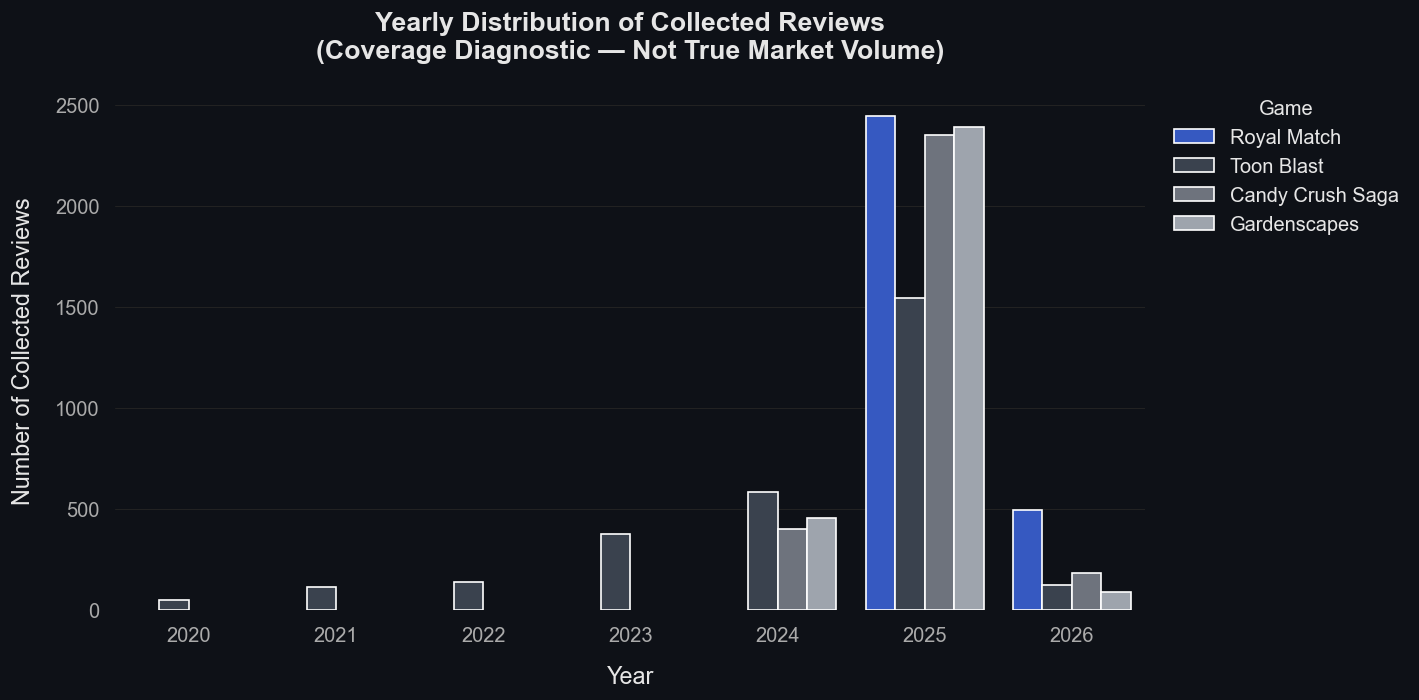

In [7]:
# --- Build year-level view (coverage diagnostic only) ---
year_by_game = (
    df_base
        .assign(year=df_base["date"].dt.year)
        .groupby(["game", "year"])
        .size()
        .reset_index(name="n_reviews")
)

# --- Palette (global visual contract) ---
palette = make_game_palette()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=year_by_game,
    x="year",
    y="n_reviews",
    hue="game",
    hue_order=GAME_ORDER,
    palette=palette
)

# --- Titles & labels (explicitly diagnostic) ---
plt.title(
    "Yearly Distribution of Collected Reviews\n(Coverage Diagnostic — Not True Market Volume)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Year", fontsize=14, fontweight="500", labelpad=12)
plt.ylabel("Number of Collected Reviews", fontsize=14, fontweight="500", labelpad=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# --- Legend ---
plt.legend(
    title="Game",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
    fontsize=12,
    title_fontsize=12
)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


> This chart shows the **year-by-year distribution of the App Store reviews I collected** for each game.
>
> **Important note:**  
> These counts reflect **only the reviews captured from App Store's paginated "recent reviews" pages (10-page limit)**.  
> I use this as a **data coverage check**, not as a measure of true yearly review volume or overall market activity.

### Step 4 Summary & Decisions

#### Key takeaways

- Time coverage across **game × country** pairs is highly uneven under the App Store **10-page pagination limit**. In practice, this dataset reflects **what is visible on the recent review pages**, not true historical volume or a complete archive.  
  A clear example is **Royal Match in the U.S.**, where the collected sample covers only **about 15 days**, while other markets for the same game go much further back. I read this as a sign that the U.S. review feed is **more recency-heavy and refreshes faster** within the same 10-page capture.

- Rating distributions in the collected sample are **highly polarized**, with substantial mass at both **1★ and 5★**.  
  Because of this, I prefer **robust summaries** such as medians and 1★/5★ shares instead of relying on means alone.

- I do see rating differences across markets and games, but both **coverage** and **recency bias** vary by **(game × country)**.  
  Because of that, I only interpret these differences later under **same-window controls (e.g., last 90 days)**.

#### Decisions

- **Base analysis scope:**  
  I restrict the core comparisons to **2025+** (`DATE_MIN = 2025-01-01`) to improve temporal overlap across games and markets.

- **Update impact approach:**  
  Update-level effects are examined descriptively through **pre/post rating shifts** at the country × version level, using rate-based metrics (e.g., 1★ share) rather than raw counts.

- **Version timeline:**  
  I treat the version rollout calendar derived from the full base dataset as the **reference timeline** for all event-study windows.

> As noted in Step 2, all rating statistics in this notebook reflect **written reviews only** and are not directly comparable to App Store headline ratings.

In [8]:
# ============================================================
# Apply Analysis Scope (Post-Summary Decision)
# ============================================================

section("APPLY ANALYSIS SCOPE — 2025+")

DATE_MIN = pd.Timestamp("2025-01-01")

df_scope = df_base.loc[df_base["date"] >= DATE_MIN].copy()

print("Rows before scope filter:", len(df_base))
print("Rows after  scope filter:", len(df_scope))
print("Date range (scoped):", df_scope["date"].min(), "→", df_scope["date"].max())


APPLY ANALYSIS SCOPE — 2025+
Rows before scope filter: 11760
Rows after  scope filter: 9630
Date range (scoped): 2025-01-01 00:25:13 → 2026-01-11 13:59:10


In [9]:
# ============================================================
section("REVIEW PROFILE — POST-SCOPE (2025+)")

# Sanity check: review-level distributions after applying analysis scope
review_data_profile(df_scope)

#I rerun the profile after applying 2025+ to confirm that basic distributions remain comparable under the analysis scope.


REVIEW PROFILE — POST-SCOPE (2025+)

DATASET OVERVIEW
Total reviews: 9,630
Games: 4 → ['Royal Match' 'Candy Crush Saga' 'Gardenscapes' 'Toon Blast']
Countries: 6 → ['United States' 'Japan' 'United Kingdom' 'Turkey' 'Canada' 'Germany']
Versions: 133
Unique users: 9,588
Competitor split: {1: 6690, 0: 2940}

GLOBAL TIME COVERAGE
2025-01-01 → 2026-01-11

TIME COVERAGE BY GAME × COUNTRY


,game,country,first_review,last_review,days_covered,reviews,n_version
17,Royal Match,United States,2025-12-27 02:44:00,2026-01-11 13:23:00,15,490,2
5,Candy Crush Saga,United States,2025-11-11 19:28:56,2026-01-11 05:45:34,60,490,6
23,Toon Blast,United States,2025-10-13 16:08:54,2026-01-11 01:09:47,89,490,14
11,Gardenscapes,United States,2025-09-23 19:39:22,2026-01-10 20:29:04,109,490,7
14,Royal Match,Japan,2025-08-24 12:36:24,2026-01-11 13:19:21,140,490,12
15,Royal Match,Turkey,2025-07-06 20:15:19,2026-01-10 21:31:34,188,490,18
16,Royal Match,United Kingdom,2025-06-29 08:15:04,2026-01-11 08:05:42,195,490,17
20,Toon Blast,Japan,2025-05-18 10:36:35,2026-01-11 13:59:10,238,490,34
3,Candy Crush Saga,Turkey,2025-04-25 21:45:14,2026-01-11 09:05:03,260,490,23
12,Royal Match,Canada,2025-04-14 05:12:47,2026-01-08 21:26:07,269,490,23



AVG RATING BY GAME (GLOBAL)


,game,reviews,avg_rating,median_rating,one_star_pct,five_star_pct
0,Candy Crush Saga,2536,2.492114,2.000000,0.463328,0.242114
1,Gardenscapes,2484,2.638084,2.000000,0.442029,0.270934
2,Royal Match,2940,2.673129,2.000000,0.443878,0.300000
3,Toon Blast,1670,3.023952,3.000000,0.347904,0.378443



RATING BY GAME × COUNTRY


,game,country,reviews,avg_rating,median_rating,p25_rating,p75_rating,one_star_pct,five_star_pct
1,Candy Crush Saga,Germany,289,2.096886,1.000000,1.000000,3.000000,0.529412,0.138408
2,Candy Crush Saga,Japan,379,2.174142,1.000000,1.000000,3.000000,0.522427,0.153034
3,Candy Crush Saga,Turkey,490,2.232653,1.000000,1.000000,4.000000,0.573469,0.224490
4,Candy Crush Saga,United Kingdom,490,2.632653,2.000000,1.000000,5.000000,0.426531,0.261224
0,Candy Crush Saga,Canada,398,2.668342,2.000000,1.000000,5.000000,0.407035,0.271357
5,Candy Crush Saga,United States,490,2.946939,3.000000,1.000000,5.000000,0.351020,0.346939
8,Gardenscapes,Japan,490,2.206122,1.000000,1.000000,3.000000,0.522449,0.167347
6,Gardenscapes,Canada,291,2.347079,1.000000,1.000000,4.000000,0.518900,0.216495
9,Gardenscapes,Turkey,407,2.552826,1.000000,1.000000,5.000000,0.535627,0.309582
7,Gardenscapes,Germany,316,2.560127,2.000000,1.000000,4.000000,0.414557,0.183544



ROYAL MATCH vs COMPETITORS


,reviews,avg_rating,median_rating,p25_rating,p75_rating,one_star_pct,five_star_pct
is_competitor,,,,,,,
0,2940,2.6731,2.0,1.0,5.0,0.4439,0.3000
1,6690,2.6791,2.0,1.0,5.0,0.4266,0.2868


### Coverage Validation & Analysis Readiness (2025+)

- **Clean analysis base:**  
  After filtering to **2025+**, the dataset includes **9,630 reviews** from **9,588 users**, covering **2025-01-01 → 2026-01-11** across **4 games** and **6 countries**.

- **Usable comparison universe:**  
  The 2025+ filter converts a heterogeneous App Store sample into a **more coherent analysis scope**.  
  Coverage is still uneven, but now **explicitly measurable and controllable**, enabling same-window (30/60/90-day) comparisons.

- **Competitive context (scoped sample):**  
  In the 2025+ scope, Royal Match’s average rating sits below Toon Blast and is closer to the rest of the competitor set.  
  Cross-country differences remain visible, which reinforces the need for **market-specific** (not purely global) comparisons under fixed windows.

- **Next step — text/NLP gating:**  
  Rating-based analyses will use `df_scope`.  
  Language-aware filtering and text-eligible subsets will be defined in **Step 5** before running any text-based diagnostics or modeling.

## 5) Language Detection & Language-Aware Text Scope

Before I run any text-based diagnostics or NLP modeling, I first need to assign a language label to each review.  
In this step, I use the **fastText language identification model (`lid.176`)** to do that.

Why this step matters:

- The dataset includes reviews from **multiple countries**, but players often write in **languages other than the main language of that market**.
- Some markets (for example, **Japan**) contain large volumes of text that fall **outside the project's supported languages**.
- Text-based methods such as **topic modeling, sentiment analysis, and aspect-based sentiment analysis** need **language-consistent text** to produce meaningful results.

In this step, I:

1. **Detect the language** of each review using fastText.
2. Label each review as **EN, TR, DE, or OTHER**.
3. Keep diagnostic columns (`lang_prob`, `lang_method`) for quality checks.
4. **Do not filter anything yet** — all languages, including OTHER and Japan, remain in the dataset for coverage analysis.

I apply filtering to language-safe subsets **later in this step**, after I inspect how languages are distributed across markets.

The source-of-truth table for this step remains **`df_scope` (the 2025+ scoped dataset)**.

In [10]:
# ============================================================
# 5.1 — Language Detection Setup (fastText) [EN/TR/DE + OTHER]
# SoT:
# - df_scope (2025+ scoped base table)
# - Column: "review" exists (safe_text applied in Step 4)
# Output (later steps):
# - lang, lang_prob, lang_method
# ============================================================

section("5.1 — LANGUAGE DETECTION SETUP (fastText)")

import re
from pathlib import Path
import fasttext

# -----------------------------
# Supported languages (project scope)
# -----------------------------
SUPPORTED_LANGS = {"EN", "TR", "DE"}

# -----------------------------
# fastText model load
# -----------------------------
FASTTEXT_MODEL_PATH = Path("lid.176.bin")  # keep as-is if model is next to the notebook
ft_lang_model = fasttext.load_model(str(FASTTEXT_MODEL_PATH))
print("✅ fastText model loaded")

# -----------------------------
# Policy thresholds (SoT)
# -----------------------------
CONF_THRESHOLD = 0.55           # accept supported lang if prob >= this
STRONG_OTHER_THRESHOLD = 0.70   # if unsupported + strong confidence → OTHER
EN_WEAK_ACCEPT = 0.40           # allow EN with weaker confidence under constraints
MIN_CHARS = 5                   # too-short guard

# TR rescue heuristic (handles very short TR texts and stray misclassifications)
MIN_TR_CHARS_FOR_RESCUE = 2
TR_CHAR_RE = re.compile(r"[çğıöşüÇĞİÖŞÜı]")
WS_RE = re.compile(r"\s+")

def detect_lang_ft(text: str, *, return_debug: bool = False):
    """
    Fast, single-shot language detection using fastText with small heuristics.

    Returns:
      - if return_debug=False: lang in {EN, TR, DE, OTHER}
      - if return_debug=True: (lang, prob, method)
    """
    raw = str(text).strip()
    trc = len(TR_CHAR_RE.findall(raw))

    # 1) Very short guard + TR rescue
    if len(raw) < MIN_CHARS:
        if trc >= MIN_TR_CHARS_FOR_RESCUE:
            out = ("TR", 1.0, "short_tr_chars")
        else:
            out = ("OTHER", 0.0, "too_short")
        return out if return_debug else out[0]

    # 2) fastText single-shot prediction
    x = WS_RE.sub(" ", raw)
    (label,), (p1,) = ft_lang_model.predict(x, k=1)
    pred = label.replace("__label__", "").upper()
    p1 = float(p1)

    # 3) Decision tree (minimal)
    if pred not in SUPPORTED_LANGS and p1 >= STRONG_OTHER_THRESHOLD:
        out = ("OTHER", p1, f"other_strong:{pred}")
    elif pred in SUPPORTED_LANGS and p1 >= CONF_THRESHOLD:
        out = (pred, p1, "fasttext")
    elif pred == "EN" and p1 >= EN_WEAK_ACCEPT and trc <= 1:
        out = ("EN", p1, "lean_en_stray_tr_char")
    elif trc >= MIN_TR_CHARS_FOR_RESCUE:
        out = ("TR", p1, "rescue_tr_chars")
    else:
        out = ("OTHER", p1, f"weak:{pred}")

    return out if return_debug else out[0]

print("✅ Detector ready. Next: single-pass detection on df_scope.")


5.1 — LANGUAGE DETECTION SETUP (fastText)
✅ fastText model loaded
✅ Detector ready. Next: single-pass detection on df_scope.


In [11]:
# ============================================================
# 5.2 — Run Language Detection (single pass on df_scope)
# ============================================================

section("5.2 — RUN LANGUAGE DETECTION (df_scope)")

# Single pass detection (returns tuples)
res = df_scope["review"].map(lambda x: detect_lang_ft(x, return_debug=True)).tolist()

df_scope[["lang", "lang_prob", "lang_method"]] = pd.DataFrame(res, index=df_scope.index)

print("✅ Language detection complete.")

print("Lang counts:")
display(df_scope["lang"].value_counts().to_frame("n_reviews"))

print("\nTop lang_method (debug):")
display(df_scope["lang_method"].value_counts().head(10).to_frame("count"))

# ============================================================
# 5.3 — QA Samples (3 per label, including OTHER)
# ============================================================

section("5.3 — QA SAMPLES (3 REVIEWS PER LANGUAGE LABEL)")

sample3 = (
    df_scope[["review_id", "review", "country", "game", "lang", "lang_prob", "lang_method"]]
    .sample(frac=1, random_state=42)          # shuffle once for stable sampling
    .groupby("lang", group_keys=False)
    .head(3)
)

display(sample3[["review_id", "country", "game", "lang", "lang_prob", "lang_method", "review"]])


5.2 — RUN LANGUAGE DETECTION (df_scope)
✅ Language detection complete.
Lang counts:


,n_reviews
lang,
EN,4755
OTHER,2372
TR,1389
DE,1114



Top lang_method (debug):


,count
lang_method,
fasttext,7132
other_strong:JA,1749
too_short,172
weak:EN,114
lean_en_stray_tr_char,113
other_strong:FR,87
other_strong:ES,43
other_strong:RU,31
weak:DE,25



5.3 — QA SAMPLES (3 REVIEWS PER LANGUAGE LABEL)


,review_id,country,game,lang,lang_prob,lang_method,review
119,13604429547,United States,Royal Match,EN,0.8937,fasttext,"While there are no adds, the adds for this game are lies. The puzzles you see involving the “King” being trapped don’t exist. They’re just animated adds to get you download. If you’re already Crushing Candy, keep crushin."
4531,13431078479,Turkey,Candy Crush Saga,TR,0.9997,fasttext,Hiçbir güçlendiricim yok reklam izleyip alayım diyorum bir tane bile reklam yok takıldım kaldım ilerlemiyor siliyorum oyunu
971,13062252023,Japan,Royal Match,OTHER,1.0000,other_strong:JA,パズルを消していくだけのゲームで、たまに王の夢と言う部屋が火事なのをパズルを解いて消化するのがある。序盤以外それしか出でこないし、他の方と競っている時に悠長にやってる暇は無い。暇つぶしには良いゲームで気付くとステージカンストしてると思います。
2098,13262185901,Canada,Royal Match,OTHER,0.2594,weak:EN,.. L agame
7929,12873224830,Canada,Gardenscapes,EN,0.9656,fasttext,The game is barely like the adds. It shows you save people but it’s just puzzles where you have to use powerups to break and beat the level. I deleted this game because I got frustrated it was so different. NEVER PLAYING IT AGAIN
3593,12590455369,Japan,Candy Crush Saga,OTHER,1.0000,other_strong:JA,広告見て移動数増やしてその広告のアプリをダウンロードしたらプレイボタンが押せなくなった\n連勝途切れてイライラする
1790,13116436510,Turkey,Royal Match,TR,0.9997,fasttext,Bu oyunun yapımcıları kesinlikle su götürmez sahtekarlar oyun hileli bir oyun dün bir bölümde bütün her şeyi bitirmeme rağmen hala daha 4 adet toprak parçası gösterdi ama baktığımda toprakları da bitirmiştim acaba ben mi yanlış yaptım diye haklarımı bitirdim ve 900 altın karşılığı 5 hak daha aldım ama yine de toprak parçası yoktu tekrar hakkımı bitirip bu defa 1900 altınla devam ettim ama yine aynı durumla karşılaştım sırf ışık topunu kaybetmemek için. Oyunun yapımcılarıyla iletişime geçti ekran görüntüsü aldım ve gönderdim bana çok saçma ve dalga geçer gibi cevap verdiler. Bunun insani bir durum olduğunu gözümden kaçmış olabileceğini söylediler ekran görüntüsüne rağmen suçlarını kabul etmediler. Bu oyunun yapımcıları karaktersiz ve haysiyetsiz oyunun kendisi de hilelidir. Benim gibi boşuna paranızı kaptırmayın bu ahlaksızlara
2310,12767207745,Canada,Royal Match,EN,0.9931,fasttext,All the ads I have seen on this game is inviting until you actually play it. It is just like all the others. I played this game for two months and not once did I get to have the challenge of saving the king.Not at all. So I deleted it. Bummer
8565,12441503371,Germany,Gardenscapes,DE,0.9995,fasttext,"Gefühlt bin ich ein Gardenscape Spieler der ersten Stunde und an sich gefällt mir das Spiel nach wie vor gut! \nLeider fällt aber auch mir in den letzten Jahren vermehrt auf, dass die meisten Zusatzmissionen sich sehr in die Länge ziehen und dann auch noch ohne extra Produkte (welche ich total überteuert finde) zu kaufen kaum zu schaffen sind. Gefühlt müsste man sonst 24/7 das Spiel spielen. \nUnd versteht mich nicht falsch, wenig spiele ich nicht. Komme regelmäßig an die Grenzen, das keine Level mehr da sind... war früher auch nicht. \nFinde ich total schade, dass es nur noch auf Geld bringen ausgelegt ist..."
4450,13568315386,Turkey,Candy Crush Saga,TR,0.9984,fasttext,Amazon. Com reklamında reklam bitiyor ama ödül için reklamı atlamıyor reklamı kaldırabilir misiniz?



5.4 — COUNTRY × LANGUAGE DISTRIBUTION (SHARES)


lang,TR,EN,DE,OTHER
country,,,,
United States,0.00,90.36,0.00,9.64
Japan,0.00,1.30,0.00,98.70
United Kingdom,0.06,95.38,0.00,4.57
Turkey,93.29,2.71,0.00,4.00
Canada,0.00,87.61,0.15,12.24
Germany,0.86,7.53,87.22,4.39



5.4.1 — CHART: LANGUAGE SHARE BY COUNTRY (STACKED BAR)


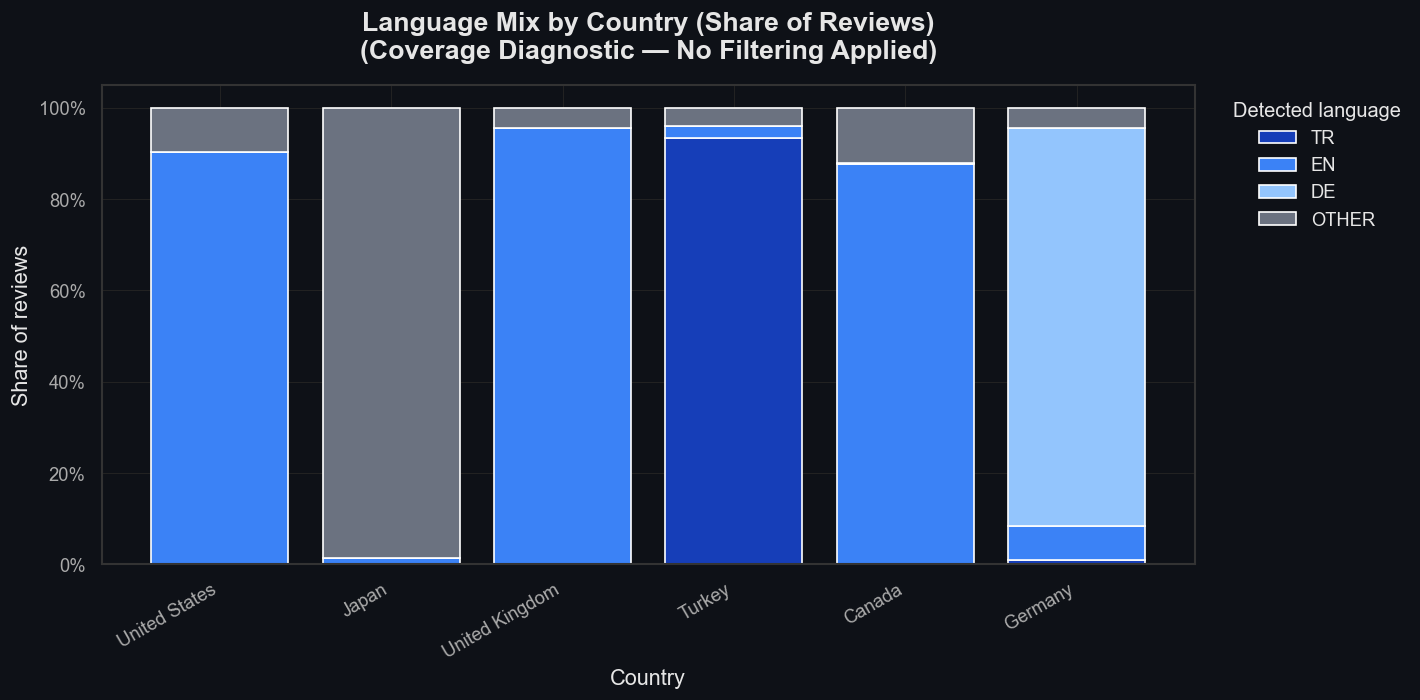

In [12]:
# ============================================================
# 5.4 — Country × Language Distribution 
# ============================================================

section("5.4 — COUNTRY × LANGUAGE DISTRIBUTION (SHARES)")

LANG_PALETTE = {
    "TR": "#163EB8",
    "EN": "#3B82F6",
    "DE": "#93C5FD",
    "OTHER": "#6B7280"
}

# ------------------------------------------------------------
# 1) Country × Language counts
# ------------------------------------------------------------

ct = (
    df_scope
    .groupby(["country", "lang"])
    .size()
    .reset_index(name="n_reviews")
)

# ------------------------------------------------------------
# 2) Shares within each country
# ------------------------------------------------------------

ct["country_total"] = ct.groupby("country")["n_reviews"].transform("sum")
ct["share"] = ct["n_reviews"] / ct["country_total"]

# ------------------------------------------------------------
# 3) Pivot share table (percentage)
# ------------------------------------------------------------

p_share = (
    ct
    .pivot(index="country", columns="lang", values="share")
    .fillna(0)
)

# Stable ordering
country_order = (
    df_scope["country"]
    .value_counts()
    .index
    .tolist()
)

lang_order = [lg for lg in ["TR", "EN", "DE", "OTHER"] if lg in p_share.columns]

p_share = p_share.loc[country_order, lang_order]

# ------------------------------------------------------------
# Display % table
# ------------------------------------------------------------

p_share_pct = (p_share * 100).round(2)
display(p_share_pct)


# ============================================================
section("5.4.1 — CHART: LANGUAGE SHARE BY COUNTRY (STACKED BAR)")

plt.figure(figsize=(12, 6))

bottom = np.zeros(len(p_share))

for lg in lang_order:

    vals = p_share[lg].to_numpy()

    plt.bar(
        p_share.index,
        vals,
        bottom=bottom,
        label=lg,
        color=LANG_PALETTE.get(lg, "#9ca3af")
    )

    bottom += vals


plt.title(
    "Language Mix by Country (Share of Reviews)\n"
    "(Coverage Diagnostic — No Filtering Applied)",
    fontsize=16,
    fontweight="bold",
    pad=16
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("Share of reviews", fontsize=13)

plt.xticks(rotation=30, ha="right")

# Y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.legend(
    title="Detected language",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()
plt.show()

> **Key observation**

>The detected language distribution aligns closely with the dominant language of each market:
English in the United States, United Kingdom, and Canada; German in Germany; and Turkish in Turkey.
This indicates that player feedback is primarily written in the **local market language**, rather than a shared global language, although a small share of cross-language or unidentified reviews also appears.
Because of this, in the **EDA stage only**, text-based exploratory analyses are conducted using the **dominant language of each market**.  
This approach reduces cross-language noise and allows early text patterns to be interpreted more reliably within each regional player base.

In [13]:
# ============================================================
# 5.5 — Build Language-Safe Text Scope (Market Dominant Language)
# Then run text profile on this scope
# ============================================================

section("5.5 — BUILD TEXT SCOPE (MARKET DOMINANT LANGUAGE)")

MAIN_LANG_BY_COUNTRY = {
    "United States": "EN",
    "United Kingdom": "EN",
    "Canada": "EN",
    "Germany": "DE",
    "Turkey": "TR",
    "Japan": "JA",  # unsupported; will naturally drop via SUPPORTED_LANGS filter
}

df_scope["main_market_lang"] = df_scope["country"].map(MAIN_LANG_BY_COUNTRY).fillna("UNKNOWN")

df_text_scope = df_scope.loc[(df_scope["lang"] == df_scope["main_market_lang"])].copy()

text_signal_profile(df_text_scope)


5.5 — BUILD TEXT SCOPE (MARKET DOMINANT LANGUAGE)

TEXT SIGNAL & RATING BY COUNTRY (EXCL: Japan)


,reviews,avg_rating,one_star_pct,avg_char_count,median_char_count,p95_char_count,avg_word_count,median_word_count,p95_word_count
country,,,,,,,,,
Germany,1112,2.4047,0.4613,238.8957,177.0,607.9,39.3174,30.0,101.00
Canada,1174,2.4966,0.4710,170.6721,121.0,511.0,32.8475,23.0,98.35
Turkey,1377,2.5802,0.5091,131.8402,99.0,369.0,18.7691,14.0,53.20
United Kingdom,1650,2.8521,0.3745,193.6370,138.0,575.1,37.4976,27.0,111.00
United States,1771,2.8628,0.3766,198.6685,131.0,604.5,38.3043,25.0,115.00



TEXT SIGNAL BY GAME (EXCL: Japan)


,game,reviews,avg_rating,avg_char_count,median_char_count,p95_char_count,avg_word_count,median_word_count,p95_word_count
0,Candy Crush Saga,1967,2.448399,179.679207,135.000000,504.400000,32.115913,23.000000,91.700000
2,Royal Match,2205,2.651247,184.042177,121.000000,546.000000,32.718821,22.000000,97.800000
1,Gardenscapes,1840,2.700543,196.224457,135.000000,586.050000,35.679891,24.000000,106.050000
3,Toon Blast,1072,3.081157,185.273321,124.000000,544.500000,34.392724,22.500000,103.000000


### Step 5 Summary — Language Labeling & Language-Safe Text Scope

#### Key findings

- **Market language is highly concentrated.**  
  The language mix closely matches each country's dominant language:
  the U.S., U.K., and Canada are overwhelmingly **EN**, Germany is overwhelmingly **DE**, and Turkey is overwhelmingly **TR**.  
  Japan is labeled almost entirely as **OTHER** (mostly **JA**), which is expected given the supported language scope in this project.

- **"OTHER" is not random noise — it is mostly Japan, plus a small cross-market tail.**  
  The debug breakdown shows that a large share of OTHER comes from **`other_strong:JA`**, while the rest is a much smaller mix of languages such as FR, ES, and RU.  
  This makes OTHER a clean group to leave out of downstream NLP without losing meaningful coverage in the EN/TR/DE markets.

#### Decision / Output artifact

- I treat language detection as a **gating step** for all text-based work in this notebook.
- The main source-of-truth split is now:

  - `df_scope` → rating / time / version analyses (all markets including Japan)
  - `df_text` → text-based theme exploration (all EN/TR/DE reviews, `lang != "OTHER"`, defined in Step 6)

  Japan is excluded naturally from text analyses since Japanese is outside the supported language scope (EN/TR/DE).

- Cross-country comparisons of text features (e.g., review length) are not meaningful because structural differences between languages (agglutinative Turkish vs. analytic English/German) make absolute values non-comparable. Where text-length patterns are examined (Step 7), they are interpreted **within each market** only.

## 6) Text EDA — Rule-Based Theme Exploration

Before I move to topic modeling, I run a lightweight **rule-based text EDA** on `df_text`.

The goal of this step is to quickly surface **high-level product signals** from player reviews without adding model complexity.  
I focus on three groups of signals:

- **Product friction:** gameplay or system elements that may cause frustration (for example, difficulty, monetization pressure, bugs, intrusive ads).
- **Product experience:** positive parts of the game experience (for example, enjoyment, rewards, visuals, social features).
- **Player signals:** cues about engagement or churn tendency (for example, loyal players, burnout, uninstall intent).

Detection is intentionally **simple and easy to interpret**, based on normalized text and a small set of keyword/phrase checks.  
The goal is **early discovery and hypothesis generation**, not precise classification.

I keep the normalization logic consistent with the **topic modeling pipeline**, so anything I surface here stays compatible with later modeling steps.

In [14]:
section("STEP 6.1 — NORMALIZATION FUNCTIONS & TEXT CONTRACTS")

# ---------------------------------------------------
# Normalization (SoT — lexicon match space)
# ---------------------------------------------------
TOKEN_RE = re.compile(r"[a-z0-9]+")

_CHAR_FOLD_MAP = str.maketrans({
    "ç": "c", "Ç": "c",
    "ğ": "g", "Ğ": "g",
    "ı": "i", "I": "i", "İ": "i",
    "ö": "o", "Ö": "o",
    "ü": "u", "Ü": "u",
    "ş": "s", "Ş": "s",
    "ä": "a", "Ä": "a",
    "ß": "ss",
})

def normalize_text_for_match(text: str) -> str:
    """
    Canonical match space: NFKC → char fold → casefold → whitespace normalize.
    Lexicon ve token matching için. EDA dışında kullanma.
    """
    t = unicodedata.normalize("NFKC", str(text))
    t = t.translate(_CHAR_FOLD_MAP)
    t = t.casefold()
    t = WS_RE.sub(" ", t).strip()
    return t

def tokens_from_match_text(text_match: str) -> set[str]:
    """Normalize edilmiş metinden token seti üret."""
    return {x for x in TOKEN_RE.findall(str(text_match)) if x}

print("✅ Normalization functions ready.")

# ---------------------------------------------------
# Export 1: Topic modeling (raw review, minimal cols)
# ---------------------------------------------------
df_export_topic = df_scope.loc[
    df_scope["lang"] != "OTHER",
    ["review_id", "game", "review", "lang"]
].copy()

df_export_topic.to_csv("reviews_topic_scope_2025.csv", index=False)
print(f"✅ Topic modeling export → reviews_topic_scope_2025.csv | {len(df_export_topic):,} rows")
display(df_export_topic["lang"].value_counts().to_frame("reviews"))

# ---------------------------------------------------
# Export 2: Sentiment (version + temporal context)
# ---------------------------------------------------
df_export_sentiment = df_scope.loc[
    df_scope["lang"] != "OTHER",
    ["review_id", "game", "country", "lang", "rating", "title",
     "review", "date", "version", "days_since_version", "is_competitor"]
].copy()

df_export_sentiment.to_csv("reviews_sentiment_scope_2025.csv", index=False)
print(f"✅ Sentiment export → reviews_sentiment_scope_2025.csv | {len(df_export_sentiment):,} rows")

# ---------------------------------------------------
# EDA working table
# ---------------------------------------------------
df_text = df_scope.loc[df_scope["lang"] != "OTHER"].copy()
df_text["text_match"] = df_text["review"].map(normalize_text_for_match)
df_text["tokens_match"] = df_text["text_match"].map(tokens_from_match_text)

print(f"\ndf_text (EDA): {len(df_text):,} rows")
display(df_text["lang"].value_counts().to_frame("reviews"))
display(
    df_text.sample(frac=1, random_state=42)
    .groupby("lang", group_keys=False)
    .head(2)[
        ["review_id", "country", "lang", "rating",
         "review", "text_match", "tokens_match"]
    ]
)


STEP 6.1 — NORMALIZATION FUNCTIONS & TEXT CONTRACTS
✅ Normalization functions ready.
✅ Topic modeling export → reviews_topic_scope_2025.csv | 7,258 rows


,reviews
lang,
EN,4755
TR,1389
DE,1114


✅ Sentiment export → reviews_sentiment_scope_2025.csv | 7,258 rows

df_text (EDA): 7,258 rows


,reviews
lang,
EN,4755
TR,1389
DE,1114


,review_id,country,lang,rating,review,text_match,tokens_match
9057,13461662500,United States,EN,5,Easy and time consuming!,easy and time consuming!,"{easy, and, time, consuming}"
1282,13067575372,United Kingdom,EN,2,It’s a good game but you barley gay to do any challenges it’s just the puzzles ig you know what I mean..,it’s a good game but you barley gay to do any challenges it’s just the puzzles ig you know what i mean..,"{barley, just, a, s, do, good, know, to, ig, challenges, but, what, mean, any, puzzles, the, it, game, you, gay, i}"
1814,13081853913,Turkey,TR,2,Bu kadar saçma oyun görmedim. Oyunları bilerek geçirmiyorlar. Takımımdaki herkes aynı sorunu yaşıyor. Normalde bölümü geçmesi gerekirken bilerek oyunu tekrarlatıyorlar. Bir bölümü geçmek için 2-3 günü harcıyor. Neden hayatımdan 3 günüm boşa gidiyor. Sonuç olarak bu oyunu eğlenmek için oynuyoruz. Stres ve gerginlik ten başka bir şey yapmıyor.,bu kadar sacma oyun gormedim. oyunlari bilerek gecirmiyorlar. takimimdaki herkes ayni sorunu yasiyor. normalde bolumu gecmesi gerekirken bilerek oyunu tekrarlatiyorlar. bir bolumu gecmek icin 2-3 gunu harciyor. neden hayatimdan 3 gunum bosa gidiyor. sonuc olarak bu oyunu eglenmek icin oynuyoruz. stres ve gerginlik ten baska bir sey yapmiyor.,"{ayni, hayatimdan, bilerek, bolumu, olarak, harciyor, gunum, bosa, gecirmiyorlar, gecmesi, gecmek, icin, neden, yasiyor, gidiyor, oyunlari, bir, sonuc, 3, ve, herkes, sacma, yapmiyor, gerekirken, oynuyoruz, kadar, ten, 2, baska, sorunu, gerginlik, eglenmek, sey, gunu, takimimdaki, normalde, stres, bu, tekrarlatiyorlar, oyun, oyunu, gormedim}"
4554,13393196500,Turkey,TR,5,"Reklamlardan sonra güclendirici almak istediğimde özellikle amazon reklamında oluyor, app store bağlanmak istiyor. Akabinde sayfaya bağlanılamadı deyip o elim boşa gidiyor.","reklamlardan sonra guclendirici almak istedigimde ozellikle amazon reklaminda oluyor, app store baglanmak istiyor. akabinde sayfaya baglanilamadi deyip o elim bosa gidiyor.","{almak, sonra, reklaminda, baglanmak, reklamlardan, ozellikle, bosa, gidiyor, istiyor, oluyor, elim, istedigimde, store, baglanilamadi, amazon, o, deyip, akabinde, guclendirici, sayfaya, app}"
2884,12564357494,Germany,DE,1,Oft braucht man für ein Level 20 Versuche und es ist soooo nervig. Ich habe das Spiel heute deaktiviert schade weil es eigentlich echt Spaß gemacht hat aber nicht unter den Umständen!,oft braucht man fur ein level 20 versuche und es ist soooo nervig. ich habe das spiel heute deaktiviert schade weil es eigentlich echt spass gemacht hat aber nicht unter den umstanden!,"{level, echt, weil, das, eigentlich, nicht, ist, soooo, ich, man, den, hat, 20, braucht, schade, nervig, es, habe, und, gemacht, heute, versuche, aber, spiel, deaktiviert, umstanden, fur, ein, spass, oft, unter}"
11388,12566394273,Germany,DE,1,"Das Spiel machte anfangs Spaß, doch nach einigen Levels wird klar, dass der Schwierigkeitsgrad bewusst so gestaltet ist, dass man ohne Zukäufe kaum noch weiterkommt. Es geht nicht mehr um Geschick oder Strategie, sondern nur noch darum, Münzen oder Punkte zu kaufen. Das Spiel frustriert mehr, als dass es unterhält – ganz offensichtlich Pay-to-Win. Sehr schade, da das Konzept eigentlich Potenzial hätte.","das spiel machte anfangs spass, doch nach einigen levels wird klar, dass der schwierigkeitsgrad bewusst so gestaltet ist, dass man ohne zukaufe kaum noch weiterkommt. es geht nicht mehr um geschick oder strategie, sondern nur noch darum, munzen oder punkte zu kaufen. das spiel frustriert mehr, als dass es unterhalt – ganz offensichtlich pay-to-win. sehr schade, da das konzept eigentlich potenzial hatte.","{noch, mehr, doch, geschick, anfangs, levels, punkte, nur, ohne, offensichtlich, so, als, to, konzept, das, pay, eigentlich, sondern, kaum, nicht, zu, ist, gestaltet, der, schwierigkeitsgrad, kaufen, man, ganz, strategie, hatte, um, win, schade, dass, unterhalt, nach, es, sehr, geht, klar, bewusst, oder, zukaufe, darum, weiterkommt, einigen, spiel, da, wir

### 6.2 — Product Friction Themes (Rule-Based Signals)

In this step, I surface **core friction signals** with a lightweight rule-based setup.  
The goal is **early discovery**, not precise classification.

I keep the approach simple and aligned with the topic-modeling normalization: **token matching + a small set of phrase patterns**, no heavy regex or complex NLP.

Friction themes cover common sources of **player frustration** (difficulty/balance, monetization pressure, ad intrusion/deception, bugs/performance, and churn intent).  
I later use these signals to build the **mixed-sentiment proxy** and support cross-theme exploration.

In [15]:
section("STEP 6.2 — LEXICON-BASED THEME FLAGS (EDA SCOPE)")

# ---------------------------------------------------
# Minimal keyword lists for exploratory flagging.
# Strategy: token set intersection + substring phrase match
# on normalize_text_for_match output (text_match / tokens_match)
# REGEX excluded intentionally — EDA scope only
# ---------------------------------------------------

_PUNCT_RE = re.compile(r"[^a-z0-9\s]")

EDA_THEMES = {

    "difficulty": {
        "EN": {
            "tokens": {
                "impossible", "difficult", "unbeatable", "unwinnable",
                "harder", "difficulty", "algorithm", "rigged", "stuck"
            },
            "phrases": [
                "too hard", "very hard", "extremely hard", "ridiculously hard",
                "not enough moves", "out of moves", "no moves left", "ran out of moves",
                "too few moves", "need more moves", "always one move short",
                "cant pass", "cant pass this level", "stuck on level",
                "stuck for days", "stuck for weeks", "same level for days",
                "progressively harder", "get harder and harder", "difficulty spike",
                "impossible to pass", "impossible to beat", "impossible to complete",
                "no chance to win", "algorithm wont let you win"
            ]
        },
        "TR": {
            "tokens": {
                "zor", "imkansiz", "adaletsiz", "hileli",
                "takildim", "algoritma", "manipule"
            },
            "phrases": [
                "cok zor", "asiri zor", "hamle yetmiyor", "hamlem bitti",
                "az hamle", "gecemiyorum", "gecilmiyor", "gecirtmiyor",
                "ayni seviyede", "gunlerdir ayni", "haftalarca takildim",
                "her seferinde bir hamle", "imkansiz seviye",
                "giderek zorlasiyor", "zorluk artmaya"
            ]
        },
        "DE": {
            "tokens": {
                "schwer", "unmoeglich", "unmoglich", "unfair",
                "manipuliert", "algorithmus", "weiterkommen"
            },
            "phrases": [
                "zu schwer", "sehr schwer", "extrem schwer", "viel zu schwer",
                "zu wenig zuge", "nicht genug zuge", "keine zuge mehr",
                "komme nicht weiter", "haenge fest", "seit tagen am selben level",
                "wird immer schwerer", "difficulty spike", "unmoeglich zu schaffen",
                "immer einen zug zu wenig"
            ]
        },
    },

    "monetization": {
        "EN": {
            "tokens": {
                "paywall", "greedy", "greed", "expensive", "overpriced",
                "refund", "p2w", "purchase", "purchases", "payment",
                "spending", "buying", "cashgrab", "ripoff", "prices"
            },
            "phrases": [
                "pay to win", "pay-to-win", "cash grab", "money grab",
                "too expensive", "waste of money", "rip off", "ripped off",
                "in app purchases", "in-app purchases", "have to pay",
                "forced to buy", "unless you pay", "without spending",
                "without paying", "aggressive monetization", "manipulative pricing",
                "drain your wallet", "save your wallet", "money grabbing",
                "special offer", "purchase popups", "offer popups"
            ]
        },
        "TR": {
            "tokens": {
                "pahali", "dolandirici", "soygun", "hirsiz", "odeme", "para"
            },
            "phrases": [
                "pay to win", "para tuzagi", "para somuruyor",
                "resmen soygun", "cok pahali", "para harcamak zorunda",
                "para vermeden ilerleyemiyorum", "satin almak zorunda",
                "odeme yapmak zorunda", "zorla para aldirtiyor"
            ]
        },
        "DE": {
            "tokens": {
                "teuer", "abzocke", "gierig", "wucher", "geld",
                "bezahlen", "kaufen", "refund", "paywall"
            },
            "phrases": [
                "pay to win", "zu teuer", "cash grab", "money grab",
                "geldmacherei", "nur auf geld aus", "reine geldmache",
                "ohne geld nicht weiter", "muss zahlen", "muss kaufen",
                "gezwungen zu kaufen", "zu viele kauf popups",
                "geld aus der tasche"
            ]
        },
    },

    "bugs": {
        "EN": {
            "tokens": {
                "bug", "crash", "freeze", "lag", "glitch",
                "freezes", "crashing", "crashes", "laggy", "overheating"
            },
            "phrases": [
                "wont load", "doesnt load", "cant open", "cant load",
                "keeps crashing", "keeps freezing", "stuck at 100",
                "stuck on loading", "black screen", "no sound",
                "sound not working", "not working", "please fix",
                "still not fixed", "had to restart", "constantly crashes"
            ]
        },
        "TR": {
            "tokens": {
                "bug", "hata", "cokuyor", "donuyor", "kasiyor",
                "takiliyor", "cokma", "donma"
            },
            "phrases": [
                "acilmiyor", "yuklenmiyor", "surekli cokuyor",
                "donup kaliyor", "ses gelmiyor", "ses yok",
                "yeniden baslatmak zorunda", "duzeltilmedi", "hala cozulmedi"
            ]
        },
        "DE": {
            "tokens": {
                "bug", "fehler", "absturz", "friert", "haengt",
                "hangt", "sturzt", "kaputt", "ladebildschirm"
            },
            "phrases": [
                "sturzt ab", "ladt nicht", "startet nicht", "schwarzer bildschirm",
                "kein ton", "haengt bei 100", "haengt beim laden",
                "bitte fixen", "immer noch nicht behoben", "bin raus geflogen"
            ]
        },
    },

    "ads_intrusion": {
        "EN": {
            "tokens": {"ads", "advertisement", "adverts"},
            "phrases": [
                "too many ads", "so many ads", "tons of ads", "full of ads",
                "constant ads", "endless ads", "forced ads", "unskippable ads",
                "unskippable", "cant skip", "after every level",
                "had to watch an ad", "ads are annoying", "annoying ads",
                "ads are too long", "ads are relentless", "more time watching ads"
            ]
        },
        "TR": {
            "tokens": {"reklam"},
            "phrases": [
                "cok reklam", "zorla reklam", "her bolum reklam",
                "reklam cok fazla", "atlanamayan reklam", "reklam bitmiyor",
                "surekli reklam", "uzun reklamlar"
            ]
        },
        "DE": {
            "tokens": {"werbung"},
            "phrases": [
                "zu viel werbung", "standig werbung", "nicht uberspringbar",
                "endlose werbung", "werbung nach jedem level",
                "nervige werbung", "werbung uberall"
            ]
        },
    },

    "ads_deception": {
        "EN": {
            "tokens": {"clickbait", "misleading", "scam", "fake"},
            "phrases": [
                "not like the ad", "nothing like the ads", "nothing like the advertisement",
                "fake ad", "fake adverts", "false advertising", "falsely advertised",
                "misleading ads", "bait and switch", "click bait", "clickbait ad",
                "not what is advertised", "not the same game", "completely different",
                "not real gameplay", "fooled by the ad", "downloaded because of the ad",
                "lying ads", "adverts lie", "totally different"
            ]
        },
        "TR": {
            "tokens": {"yaniltici", "aldatici", "yalan"},
            "phrases": [
                "reklamla alakasi yok", "reklamdaki gibi degil",
                "reklamlar yalan", "yaniltici reklam", "sahte reklam",
                "reklamda gordugum oyun degil", "tanitimdaki gibi degil",
                "videodaki gibi degil", "tamamen farkli"
            ]
        },
        "DE": {
            "tokens": {"irrefuhrend", "betrug", "fake"},
            "phrases": [
                "falsche werbung", "nicht wie beworben",
                "irrefuhrende werbung", "nichts mit der werbung zu tun",
                "fake werbung", "vollig anderes spiel", "getauscht worden"
            ]
        },
    },

    "rewards": {
        "EN": {
            "tokens": {
                "rewards", "reward", "boosters", "booster", "powerup",
                "powerups", "coins", "chests", "gifts", "gift", "bombs"
            },
            "phrases": [
                "no rewards", "less rewards", "rewards are bad", "rewards are low",
                "prizes have gone down", "not enough boosters", "boosters are rare",
                "no boosters", "too few chests", "less chests",
                "reward removed", "reward option removed", "duplicate cards",
                "complete the set", "gold cards", "little prizes"
            ]
        },
        "TR": {
            "tokens": {
                "odul", "oduller", "bonus", "sandik", "yildiz",
                "rozet", "altin"
            },
            "phrases": [
                "odul azaldi", "odul yok", "yeterli odul yok",
                "az odul", "bonus azalti", "guclendirici yok"
            ]
        },
        "DE": {
            "tokens": {
                "belohnung", "belohnungen", "bonus", "stern",
                "sterne", "truhe", "booster", "munzen"
            },
            "phrases": [
                "keine belohnung", "weniger belohnungen",
                "belohnungen reduziert", "zu wenig booster",
                "keine booster", "preise gesunken", "schlechtere belohnungen"
            ]
        },
    },

    # ---------------------------------------------------
    # Cross-cut signals (Level1)
    # ---------------------------------------------------
    "churn": {
        "EN": {
            "tokens": {"uninstall", "uninstalling", "deleting", "quit"},
            "phrases": [
                "i quit", "deleting now", "deleting this", "uninstalling now",
                "not fun anymore", "done with this game", "never playing again",
                "switching to another game", "looking for another game"
            ]
        },
        "TR": {
            "tokens": {"siliyorum", "sildim", "birakiyorum", "kaldiriyorum"},
            "phrases": [
                "oyunu birakiyorum", "silecegim", "artik oynamayacagim",
                "baska oyuna geciyorum", "kaldiracagim"
            ]
        },
        "DE": {
            "tokens": {"deinstalliert", "geloscht", "deinstalliere"},
            "phrases": [
                "ich hore auf", "nie wieder", "werde es loschen",
                "suche ein anderes spiel", "war mein letztes spiel"
            ]
        },
    },

    "burnout": {
        "EN": {
            "tokens": {"boring", "repetitive", "monotone", "monotonous"},
            "phrases": [
                "not fun anymore", "lost interest", "waste of time",
                "getting boring", "same thing over and over",
                "no longer fun", "lost its charm", "become tedious"
            ]
        },
        "TR": {
            "tokens": {"sikici", "tekrar", "bezdi"},
            "phrases": [
                "zaman kaybi", "artik eglenceli degil", "sikici hale geldi",
                "ilgimi kaybetti", "hep ayni sey", "monoton oldu"
            ]
        },
        "DE": {
            "tokens": {"langweilig", "monoton", "ode"},
            "phrases": [
                "kein spass mehr", "zeitverschwendung", "wird langweilig",
                "immer das gleiche", "hat seinen reiz verloren",
                "macht keinen spass mehr"
            ]
        },
    },

    "positive": {
        "EN": {
            "tokens": {
                "love", "fun", "addictive", "amazing", "enjoy",
                "brilliant", "fantastic", "awesome", "relaxing", "perfect"
            },
            "phrases": [
                "best game", "highly recommend", "cant stop playing",
                "love this game", "so much fun", "great game",
                "really enjoy", "totally addicted"
            ]
        },
        "TR": {
            "tokens": {
                "harika", "eglenceli", "mukemmel", "seviyorum",
                "muthis", "super", "guzel", "keyifli"
            },
            "phrases": [
                "cok guzel", "tavsiye ederim", "en iyi oyun",
                "cok eglenceli", "bayiliyorum", "cok begendim"
            ]
        },
        "DE": {
            "tokens": {
                "toll", "super", "genial", "spass", "wunderbar",
                "entspannend", "suechtig", "fantastisch"
            },
            "phrases": [
                "sehr gut", "macht spass", "viel spass",
                "beste spiel", "sehr empfehlenswert", "kann nicht aufhoren"
            ]
        },
    },

    "loyal_player": {
        "EN": {
            "tokens": set(),
            "phrases": [
                # direct identity phrases
                "loyal player", "loyal players", "as a loyal player",
                "long time player", "long-time player", "longtime player",
                "long term player", "long time fan", "long-time fan",
                "veteran player", "as a player for a while",
                # duration + play
                "been playing since",
                "playing for years", "played for years",
                "playing for months", "played for months",
                "playing for a good year",
                "playing for a long time", "played for a long time",
                "playing for ages", "played for ages",
                "playing for so long", "years and years",
                "been playing this game for as long as i can remember",
                # since anchor
                "since the beginning", "since day one", "since day 1",
                "since launch", "since release", "since it came out",
                "since 2020", "since 2021", "since 2022", "since 2023",
                # high level milestone (proxy for longevity)
                "my favorite for years",
                "started playing years ago",
                "have had this game for years",
            ]
        },
        "TR": {
            "tokens": {"yillardir", "senelerdir", "aylardir"},
            "phrases": [
                "uzun zamandir oynuyorum", "yillardir oynuyorum",
                "senelerdir oynuyorum", "aylardir oynuyorum",
                "ilk gunden beri", "basindan beri oynuyorum",
                "ciktigindan beri", "ilk yukleyenlerden",
                "uzun suredir oynuyorum", "uzun zamandir oynuyorum",
                "ilk yillardan beri", "yillarca oynadim",
                "2020den beri", "2021den beri", "2022den beri", "2023ten beri",
            ]
        },
        "DE": {
            "tokens": {"jahrelang"},
            "phrases": [
                "schon seit jahren", "schon seit monaten",
                "seit jahren dabei", "von anfang an dabei",
                "seit dem release", "seit dem start",
                "spiele das spiel schon lange",
                "spiele es schon lange", "jahrelang gespielt",
                "seit ganz vielen jahren", "schon ein paar jahre",
                "treue fans", "treuer fan",
                "seit 2020", "seit 2021", "seit 2022", "seit 2023",
            ]
        },
    },
}

# ---------------------------------------------------
# Flag function
# ---------------------------------------------------
def flag_eda_theme(row, spec: dict) -> bool:
    lang = row["lang"]
    lang_spec = spec.get(lang)
    if lang_spec is None:
        return False
    if row["tokens_match"] & lang_spec.get("tokens", set()):
        return True
    text_clean = _PUNCT_RE.sub("", row["text_match"])
    for phrase in lang_spec.get("phrases", []):
        if phrase in text_clean:
            return True
    return False

# ---------------------------------------------------
# Apply flags
# ---------------------------------------------------
LEVEL2_THEMES  = ["difficulty", "monetization", "bugs",
                  "ads_intrusion", "ads_deception", "rewards"]
SIGNAL_THEMES  = ["churn", "burnout", "positive", "loyal_player"]
ALL_THEMES     = LEVEL2_THEMES + SIGNAL_THEMES

for theme in ALL_THEMES:
    df_text[f"theme_{theme}"] = df_text.apply(
        lambda r, t=theme: flag_eda_theme(r, EDA_THEMES[t]),
        axis=1
    )

THEME_COLS  = [f"theme_{t}" for t in LEVEL2_THEMES]
SIGNAL_COLS = [f"theme_{t}" for t in SIGNAL_THEMES]

SIGNAL_COLS_MAP = {
    "Churn":        "theme_churn",
    "Burnout":      "theme_burnout",
    "Positive":     "theme_positive",
    "Loyal Player": "theme_loyal_player",
}

# ---------------------------------------------------
# Prevalence QC
# ---------------------------------------------------
print("\n── Level2 Theme Prevalence ──")
display(
    df_text[THEME_COLS]
    .mean()
    .sort_values(ascending=False)
    .rename(index=lambda x: x.replace("theme_", ""))
    .to_frame("share")
    .style.format("{:.2%}")
)

print("\n── Cross-cut Signal Prevalence ──")
display(
    df_text[SIGNAL_COLS]
    .mean()
    .sort_values(ascending=False)
    .rename(index=lambda x: x.replace("theme_", ""))
    .to_frame("share")
    .style.format("{:.2%}")
)

print("\n── Theme Prevalence by Language ──")
display(
    df_text.groupby("lang")[THEME_COLS]
    .mean()
    .rename(columns=lambda x: x.replace("theme_", ""))
    .style.format("{:.2%}")
)


STEP 6.2 — LEXICON-BASED THEME FLAGS (EDA SCOPE)

── Level2 Theme Prevalence ──


,share
ads_intrusion,16.20%
monetization,15.10%
rewards,14.11%
difficulty,13.92%
bugs,5.35%
ads_deception,5.17%



── Cross-cut Signal Prevalence ──


,share
positive,31.45%
burnout,5.81%
churn,4.06%
loyal_player,1.82%



── Theme Prevalence by Language ──


,difficulty,monetization,bugs,ads_intrusion,ads_deception,rewards
lang,,,,,,
DE,8.71%,29.89%,7.27%,20.02%,2.42%,17.95%
EN,15.39%,13.02%,4.46%,16.53%,6.92%,12.93%
TR,13.03%,10.37%,6.84%,12.02%,1.37%,15.05%


### 6.3 — Friction Drill-Down by Cross-Cut Signal

In this step, I examine how **friction themes distribute within each cross-cut signal group** (churn, burnout, positive, loyal player) to understand which product issues co-occur with different player behaviors.


STEP 6.3 — FRICTION DRILL-DOWN BY CROSS-CUT SIGNAL


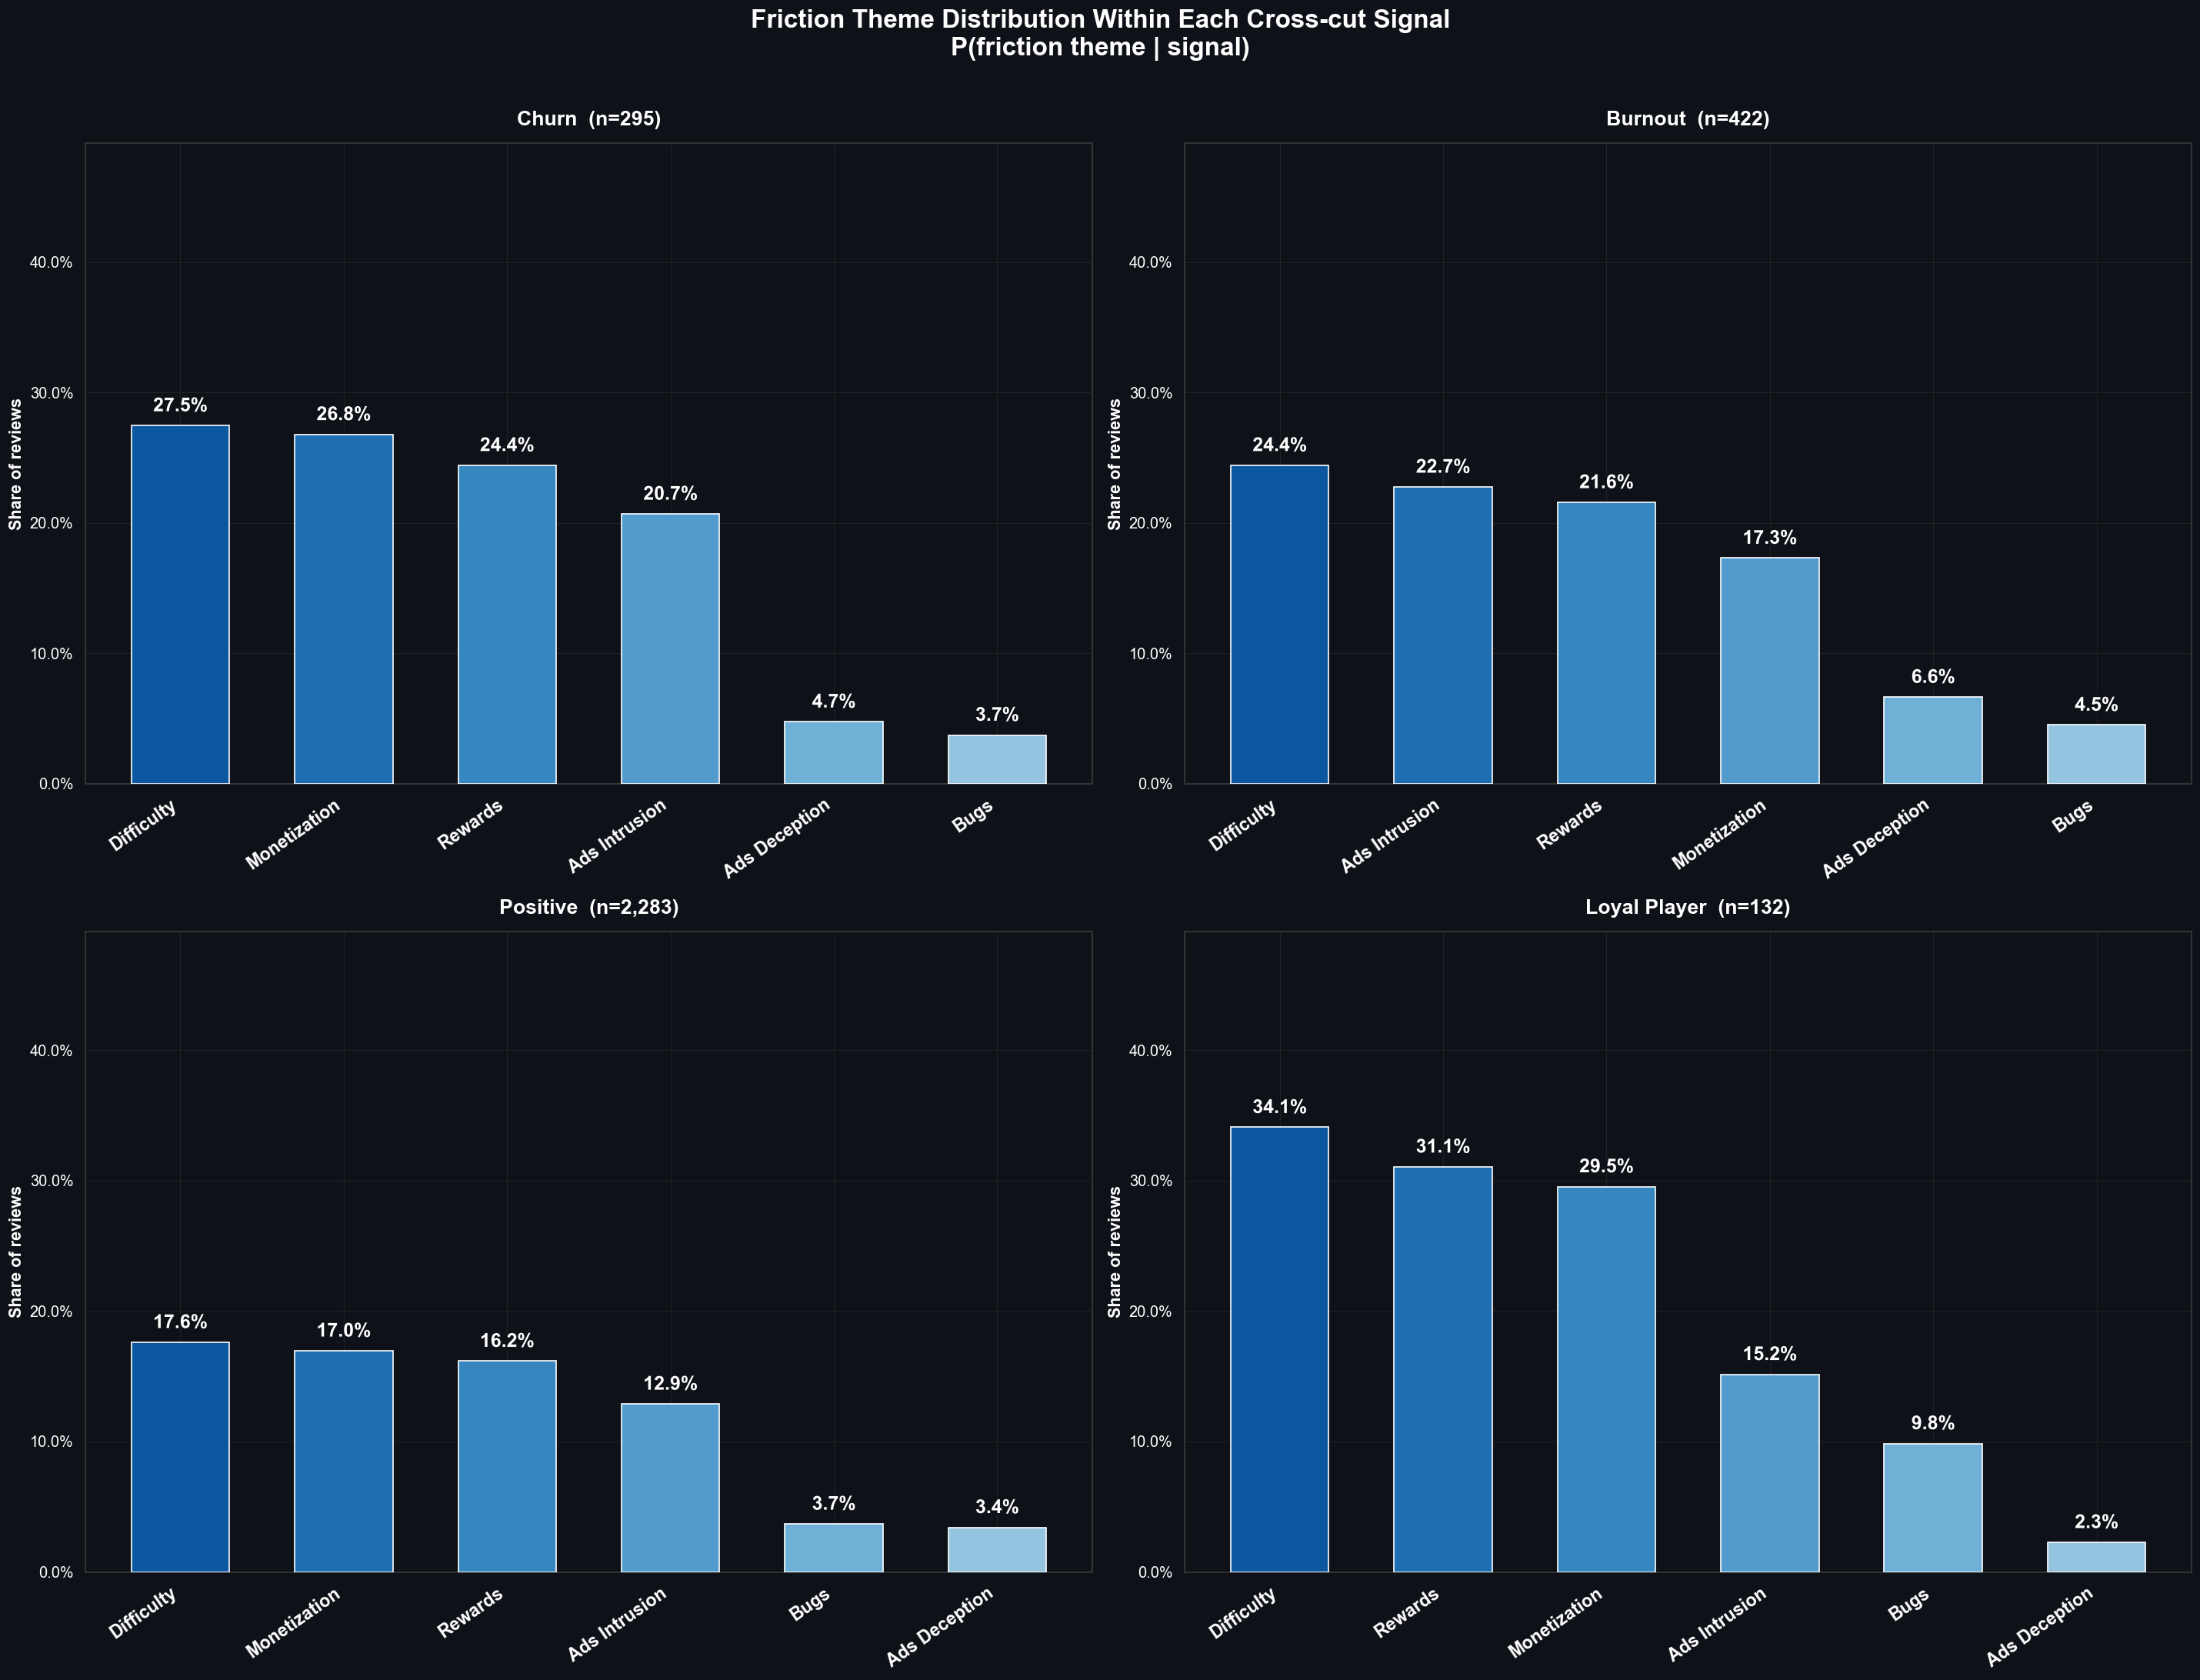


── P(friction | signal) table ──


signal,Burnout,Churn,Loyal Player,Positive
theme,,,,
Difficulty,24.41%,27.46%,34.09%,17.61%
Monetization,17.30%,26.78%,29.55%,16.95%
Rewards,21.56%,24.41%,31.06%,16.16%
Ads Intrusion,22.75%,20.68%,15.15%,12.88%
Ads Deception,6.64%,4.75%,2.27%,3.42%
Bugs,4.50%,3.73%,9.85%,3.68%


In [16]:
section("STEP 6.3 — FRICTION DRILL-DOWN BY CROSS-CUT SIGNAL")

records = []
for signal_label, signal_col in SIGNAL_COLS_MAP.items():
    subset = df_text[df_text[signal_col]]
    if len(subset) == 0:
        continue
    for col in THEME_COLS:
        records.append({
            "signal": signal_label,
            "theme":  col.replace("theme_", "").replace("_", " ").title(),
            "share":  subset[col].mean(),
            "n":      len(subset),
        })

drill_df = pd.DataFrame(records)

# ---------------------------------------------------
# Visualization — 2x2
# ---------------------------------------------------
signals  = list(SIGNAL_COLS_MAP.keys())
n_themes = drill_df["theme"].nunique()
blues    = plt.cm.Blues(np.linspace(0.85, 0.4, n_themes))  # reversed: dark → light

fig, axes = plt.subplots(2, 2, figsize=(24, 18))
axes_flat = axes.flatten()

for ax, signal in zip(axes_flat, signals):
    data = (
        drill_df[drill_df["signal"] == signal]
        .sort_values("share", ascending=False)
        .reset_index(drop=True)
    )
    n = data["n"].iloc[0]

    bars = ax.bar(
        range(len(data)),
        data["share"],
        color=blues,
        width=0.6,
        zorder=3
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.008,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            color="#FFFFFF",
            fontsize=15,
            fontweight="bold",
            path_effects=[
                pe.withStroke(linewidth=3, foreground="#0e1117")
            ]
        )

    ax.set_title(
        f"{signal}  (n={n:,})",
        fontsize=16,
        fontweight="bold",
        color="#FFFFFF",
        pad=14
    )
    ax.set_ylabel("Share of reviews", fontsize=13, fontweight="bold", color="#FFFFFF")
    ax.set_xlabel("")
    ax.set_ylim(0, drill_df["share"].max() + 0.15)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(
        data["theme"],
        ha="right",
        fontsize=14,
        fontweight="bold",
        rotation=35,
        color="#FFFFFF"
    )
    ax.tick_params(axis="y", colors="#FFFFFF", labelsize=12)
    ax.yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle(
    "Friction Theme Distribution Within Each Cross-cut Signal\n"
    "P(friction theme | signal)",
    fontsize=20,
    fontweight="bold",
    color="#FFFFFF",
    y=1.01
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Table QC
# ---------------------------------------------------
print("\n── P(friction | signal) table ──")
display(
    drill_df
    .pivot(index="theme", columns="signal", values="share")
    .sort_values("Churn", ascending=False)
    .style.format("{:.2%}")
)

### 6.4 — Mixed Sentiment Signal

In mobile game reviews, it is common to observe **mixed sentiment cases** where players give a high rating but still express frustration about specific aspects of the game.

To capture this pattern, we define a simple proxy:

Mixed sentiment =  
**rating ≥ 4★ AND at least one product friction signal**

This signal highlights cases where players generally like the game but mention issues such as:

- difficulty spikes
- monetization pressure
- intrusive ads
- bugs or performance issues

These reviews are particularly valuable for product insight, as they often reflect **loyal or engaged players experiencing friction** rather than purely negative feedback.

In [17]:
# ----------------------------------------
# STEP 6.4 — MIXED SENTIMENT FLAG
# ----------------------------------------
section("STEP 6.4 — MIXED SENTIMENT FLAG")

df_text["mixed_sentiment"] = (
    (df_text["rating"] >= 4) &
    (df_text[THEME_COLS].any(axis=1))
)

mixed_rate = df_text["mixed_sentiment"].mean()
print(f"Mixed sentiment rate (global, non-JP): {mixed_rate:.2%}")

display(
    df_text["mixed_sentiment"]
    .value_counts(normalize=True)
    .rename("share")
    .to_frame()
    .style.format("{:.2%}")
)

# Per-language breakdown
print("\n── Mixed Sentiment Rate by Language ──")
display(
    df_text.groupby("lang")["mixed_sentiment"]
    .mean()
    .to_frame("mixed_rate")
    .style.format("{:.2%}")
)

# ----------------------------------------
# STEP 6.5 — QUALITATIVE CHECK
# ----------------------------------------
section("STEP 6.5 — QUALITATIVE CHECK")

def sample_examples(df, flag_col, n_per_lang=1):
    return (
        df[df[flag_col]]
        .sample(frac=1)
        .groupby("lang", group_keys=False)
        .head(n_per_lang)
        [["game", "country", "lang", "rating", "review"]]
    )

# --- Level2 friction themes ---
print("\n── Level2 Friction Themes: Sample Reviews ──")
friction_examples = []
for col in THEME_COLS:
    tmp = sample_examples(df_text, col)
    tmp["theme"] = col.replace("theme_", "")
    friction_examples.append(tmp)

display(
    pd.concat(friction_examples)
    .style.apply(highlight_and_bold_royal_match, axis=1)
)

# --- Cross-cut signals ---
print("\n── Cross-cut Signals: Sample Reviews ──")
signal_examples = []
for col in SIGNAL_COLS:
    tmp = sample_examples(df_text, col)
    tmp["theme"] = col.replace("theme_", "")
    signal_examples.append(tmp)

display(
    pd.concat(signal_examples)
    .style.apply(highlight_and_bold_royal_match, axis=1)
)

# --- Mixed sentiment ---
print("\n── Mixed Sentiment: Sample Reviews ──")
display(
    df_text[df_text["mixed_sentiment"]]
    .sample(frac=1, random_state=42)
    .groupby("lang", group_keys=False)
    .head(2)
    [["game", "country", "lang", "rating", "review"]]
    .style.apply(highlight_and_bold_royal_match, axis=1)
)


STEP 6.4 — MIXED SENTIMENT FLAG
Mixed sentiment rate (global, non-JP): 9.42%


,share
mixed_sentiment,
False,90.58%
True,9.42%



── Mixed Sentiment Rate by Language ──


,mixed_rate
lang,
DE,11.04%
EN,8.69%
TR,10.66%



STEP 6.5 — QUALITATIVE CHECK

── Level2 Friction Themes: Sample Reviews ──


,game,country,lang,rating,review,theme
6909,Gardenscapes,United Kingdom,EN,4,"Whilst I do love this game it does get very repetitive due to the extremely high difficulty of most levels, as well as poor explosives to help beat them. First off if we could combine the rainbow discs with other explosives that would help no end, just as we can in your other brilliant game Homescapes, this would make the levels that much easier and quicker to beat. As it is to have to sit on a level and play it over and over again for days, weeks, or even longer until we beat it makes for an extremely boring, tedious and repetitive game. Especially as some of the levels are next to impossible to beat. Secondly if you could simply drop the very high level of difficulty of the levels even down a fraction that would make this game so much more enjoyable and infinitely more playable. Thank you.",difficulty
5407,Candy Crush Saga,Germany,DE,3,"...der Macher. Muss aber auch, sonst würden sie ja kein Geld verdienen. Generell macht/e mir das Spielen Spaß. Viele Vorredner haben jedoch recht, dass man zum Geld einsetzen genötigt wird, erlangte Booster bedingt durch Zeitbegrenzung nicht nutzen kann, da sie schon abgelaufen sind, bevor man sich durch div. Werbung, bzw. Kauf-Popups geklickt hat. Die „Machenschaften“ der Entwickler waren früher subtiler, jetzt kommt man schnell dahinter, wie manipuliert das Spiel ist, schade. Der Knaller ist zudem, dass ich beim Winterturnier nicht weiterkomme, da es keine neuen Levels mehr gibt. Über die Quali somit ganz umsonst gefreut, die Uhr tickt, aber man kommt nicht weiter. Soviel Fairness und Algorithmus sollte eingesetzt werden, dass man automatisch disqualifiziert o.ä. wird, wenn klar ist, dass man das Spiel nicht wird spielen, bzw. zum Ende wird bringen können.",difficulty
4769,Candy Crush Saga,Turkey,TR,4,"Bazen şansızsanız saçma sapan hamleler yapmak zorunda kalıyorsunuz başka yapamıyorsunuz çünkü BAŞKA HAMLE YOK bu saçma sapan hamleleri yaparken üzülüyorum çünkü yapacak başka bir şey yok bi de üstüne seri sıfırlanıyor kaybedince,Arkadaşlarıma en fazla bir can gönderebilmem ve sonlara doğru çok zorlaşması biraz sıkıntı olabiliyor eskisi kadar güzel olmasada hala önerebileceğim bir oyun 😊lütfen yararlıya basın!",difficulty
10330,Toon Blast,Turkey,TR,1,Para harcamadan asla bölümler geçilmiyor stres atmak için oynanan oyun kabusa döndü 2016 dan beri oynadığım oyun işkence ye dönüştü ödüller azaltıldı turnuvaları asla kazanamıyoruz okadar emeğe rağmen ödül kazanmak zor acilen yeni bir düzenleme gelmesi gerekiyor lütfen yorumlarınızı ciddiye alın saygılarımızla,monetization
3122,Candy Crush Saga,United States,EN,3,"Can’t play unless you pay. Same thing in each level over and over and over again. Meaning it will take over a week to finish one level unless you make a purchase because you will get nothing but three move matches and you are PREVENTED from going further. You will always know when it forces you to make purchases. So predictable. After a year of the same ole same ole, it’s not worth my time.",monetization
2634,Royal Match,Germany,DE,3,Die Anzahl wie oft man ein Level spielen muss ist total nervig... die Software ist gegen dich programmiert und 900 taler für s weiterspielen zu hoch...es Ware viel besser nur 1 Zug z. B. Für 100 Punkte kaufen zu können.,monetization
4718,Candy Crush Saga,Turkey,TR,3,Oyununu 17998. Bölümünde hata var hiç hamle yapmadan bitiyor,bugs
3964,Candy Crush Saga,United Kingdom,EN,2,Never had game freezes before - now it’s freezing about every third game!,bugs
5479,Candy Crush Saga,Germany,DE,1,"Candy Crush bleibt immer wieder hängen und friert während des Spiels ein. Teilweise stürzt es komplett ab, sodass man das Level neu starten muss. Besonders ärgerlich: Gekaufte oder gesammelte Goldbarren verschwinden einfach, ohne dass man sie verwendet hat. Das Spiel macht so keinen Spaß mehr und wirkt unfair gegenüber den Spielern. Bitte behebt dringend die Stabilitätsprobleme und kümmert euch um den


── Cross-cut Signals: Sample Reviews ──


,game,country,lang,rating,review,theme
255,Royal Match,United States,EN,1,"Used to be fun until they made it so hard to complete levels once you get to a certain level. And took away over half of the power ups and tools, and started giving out way less coins for competing levels and challenges. Contacted support. Was given a condescending answer. I get that they need money to make the game. But at this point it just seems like they’re greedy. Many people on my team have quit playing for the same reasons. Bummer it used to be a nice way to relax. Now it’s just frustrating.",churn
4651,Candy Crush Saga,Turkey,TR,1,Hep reklam hep reklam sıkıcı oldu siliyorum,churn
11325,Toon Blast,Germany,DE,3,"Früher klasse, heute leider nur noch Abzocke. Macht süchtig und wenn man ab und zu was gekauft hat scheinen folgende Level ohne zu bezahlen unlösbar zu sein. Entweder ist das Zufallsprinzip (ich glaub es ist tatsächlich programmierte Willkür...) Erfolgreiche Spieler kaufen anscheinend ohne Ende Münzen. Ich spiele das Spiel seit vielen Jahren... und zwar mit rapide nachlassender „Begeisterung“. Ohne das tolle Team im Hintergrund hätte ich die App schon längst gelöscht. Denn Frust und Ärger ist wahrlich KEIN Spiel „wert“!",churn
4077,Candy Crush Saga,United Kingdom,EN,2,So boring!This is the most boring game I have ever come across and it also has to many adds,burnout
4597,Candy Crush Saga,Turkey,TR,1,Sürekli oyunda donuyor ve kapatıp tekrar açmak gerekiyor aynı şey sürekli olunca oyun oynama isteği sıfır böyle giderse sileceğim. Özellikle patlamalar olurken kasıp donuyor.,burnout
5567,Candy Crush Saga,Germany,DE,2,Bin nun Level 55 und habe jedes Level beim ersten Versuch mit 3 Sternen beendet. Ziemlich langweilig und viel zu einfach.,burnout
6251,Gardenscapes,United States,EN,5,I loves this game and the guy is so nice I would play this all day. it’s so cool doing the mini games and the puzzles it’s fun u should download this right now I also say the puppy is so cute and super fun too play with.This game is fun might be the best then other relaxing games super calm also looking all around at the end when u finish everything it’s so cool too look at I can’t unnoticed RIGHT now and I would play this at night it’s super super peaceful alone and I can’t stop playing this THE END download this game it’s so relaxing and peaceful,positive
11379,Toon Blast,Germany,DE,1,"Tolle Idee: Ein Puzzle-Spiel, bei dem nicht Können, sondern Glück (und Geld) entscheidet. Macht richtig Spaß – für die ersten zehn Level. Danach: Zahlen oder verzweifeln!",positive
10339,Toon Blast,Turkey,TR,5,Çok güzel adam gibi oyun çok sarıyo,positive
3300,Candy Crush Saga,United States,EN,3,Long-time player. The recent “music party” update isn’t relaxing. Music is jarring and gameplay feels busy. Please consider keeping a classic version. This change is pushing me to play far less.”,loyal_player



── Mixed Sentiment: Sample Reviews ──


,game,country,lang,rating,review
7551,Gardenscapes,Turkey,TR,4,Oyun iyi güzel Ama Ama Ama Bir tane zor ya da süper zor seviye geçiyorum binbir uğraşla oh be diyorum sonraki BİRKAÇ KOLAY BÖLÜMDE rahatlıyorum ama sonra hop önüme ya zor ya süper zor seviye çıkıyo tekrardan doğru düzgün soluklanamadan ya. Bir on saat daha onlarla uğraşıyorum oyun baya sıkıcılaşıyo valla ya zevk alamıyorum . Onun dışında iyi.Acaba ben mi bölümlerde çok zorlanıyorum ?
2791,Royal Match,Germany,DE,4,"Das einzige ist, der Albtraum des Königs in der Werbung ist vielfältige als im Spiel, ich überspringe das schon lange, immer das gleiche.."
2693,Royal Match,Germany,DE,4,"Die App ist toll aber: Ich habe das Spiel in der Werbung entdeckt und ich finde es doof, dass dieser König gar keine Hilfe vor der „Schlange“ braucht!! Aber sonst gerne runterladen echt cool!!"
1596,Royal Match,Turkey,TR,5,Bölüm geçmek zor
3379,Candy Crush Saga,United States,EN,5,I love the game! I wish the app changed the ads more often and really wish there were fewer ads for bras and Everdry underwear pee pants!!! Saying Not Interested to these does not make them go away. Not every woman over 50 or 65 wants these items! Thanks....
8999,Toon Blast,United States,EN,5,"I think the game is rigged against you as far as the arrows go, they go everywhere but the direction you need. I am now at level 11100 it’s taking me probably 11 years to get this far. I’ve never spent any money."


### Step 6 Summary

#### Theme prevalence

The four most frequently flagged friction themes — **ads intrusion (16.2%), monetization (15.1%), rewards (14.1%), and difficulty (13.9%)** — appear at broadly comparable rates, suggesting no single dominant friction source across the dataset. **Bugs (5.4%) and ads deception (5.2%)** are notably less prevalent, indicating these are either rarer issues or harder to capture with simple keyword matching.

Among cross-cut signals, **positive sentiment (31.5%)** is the most common flag — expected given that a large share of reviews express general satisfaction. **Burnout (5.8%) and churn (4.1%)** are low but non-trivial, while **loyal player (1.8%)** captures a small, self-identifying subset.

#### Language-level patterns

German reviews show a substantially higher **monetization flag rate (29.9%)** compared to EN (13.0%) and TR (10.4%). This may reflect genuine market-level differences in monetization sensitivity, but could also be influenced by lexicon coverage — a caveat inherent to rule-based detection.

#### Friction × signal co-occurrence

The drill-down table reveals that **loyal players who complain** most frequently cite **difficulty (34.1%), rewards (31.1%), and monetization (29.6%)** — this is a product-relevant signal suggesting that long-tenure players experience economy and progression friction. Among **churn-intent reviews**, the top friction themes are **difficulty (27.5%) and monetization (26.8%)**, indicating these are the primary stated reasons for leaving.

#### Mixed sentiment (preliminary proxy)

Approximately **9.4%** of non-JP reviews carry the mixed sentiment flag (rating ≥ 4 AND at least one friction keyword). This is a **crude directional proxy only** — it captures high-rating reviews that mention friction-related words, but does not involve actual sentiment classification. The downstream LLM pipeline applies a proper mixed sentiment definition based on per-aspect sentiment polarity, which supersedes this rule-based approximation.

#### Limitations and downstream handoff

- All theme signals are **rule-based and lexicon-dependent** — precision and recall are unknown and likely uneven across languages and themes.
- These signals serve as **early directional indicators** for hypothesis generation and exploratory pattern recognition, not as production-grade classifiers.
- The downstream **topic modeling pipeline** (BERTopic, 114 topics, three-tier taxonomy) and **LLM sentiment pipeline** (GPT-4.1, per-aspect sentiment + behavioral flags) replace these primitive signals with substantially more precise and comprehensive coverage.



## Step 7 — Rating Landscape (Last 90 Days)

Starting from this step, all rating-based analyses are conducted using a **last-90-days window** to ensure temporal comparability across games and markets.

This step provides a consolidated descriptive snapshot covering:
- **Rating distributions** by game and by country,
- **Game × country comparisons** (violin plots, heatmaps),
- **Review volume context** to assess sample reliability per market,
- **Review length vs rating** patterns (within each market, not cross-market — due to structural differences between languages).

The goal is to establish a clear picture of where Royal Match stands relative to competitors and across markets before examining temporal dynamics in Step 8.

In [18]:
# =========================
# STEP 7.0 — Define 90-day analysis window
# =========================

section("STEP 7.0 — DEFINE ANALYSIS WINDOW (LAST 90 DAYS)")

max_date = df_base["date"].max()
cutoff_date = max_date - pd.Timedelta(days=90)

dfw_90 = df_base[df_base["date"] >= cutoff_date].copy()

print("Max date:", max_date)
print("Cutoff date:", cutoff_date)
print(
    "Rows:", len(dfw_90),
    "| Games:", dfw_90["game"].nunique(),
    "| Countries:", dfw_90["country"].nunique()
)


STEP 7.0 — DEFINE ANALYSIS WINDOW (LAST 90 DAYS)
Max date: 2026-01-11 13:59:10
Cutoff date: 2025-10-13 13:59:10
Rows: 4237 | Games: 4 | Countries: 6



STEP 7.1 — RATING DISTRIBUTIONS BY GAME (LAST 90 DAYS)


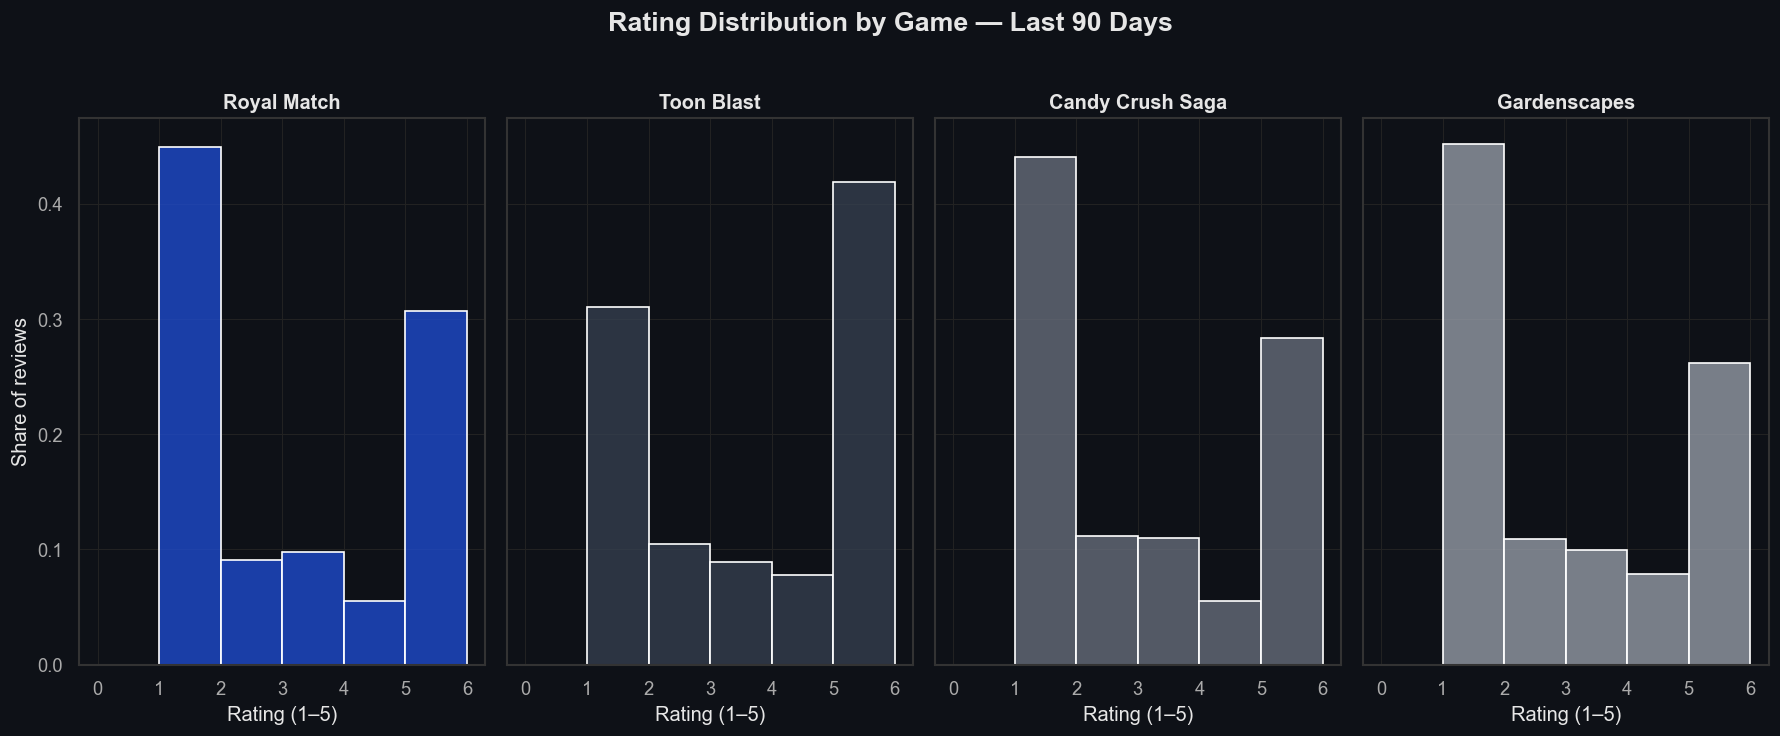

In [19]:
# =========================
# STEP 7.1 — Rating distributions by game (last 90 days)
# =========================

section("STEP 7.1 — RATING DISTRIBUTIONS BY GAME (LAST 90 DAYS)")

palette = make_game_palette()

games = GAME_ORDER
fig, axes = plt.subplots(
    1,
    4,
    figsize=(15, 6),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, game in zip(axes, games):
    subset = dfw_90[dfw_90["game"] == game]

    sns.histplot(
        data=subset,
        x="rating",
        discrete=True,
        binwidth=1,
        binrange=(0.5, 5.5),
        stat="probability",
        color=palette[game],
        edgecolor="white",
        ax=ax
    )

    ax.set_title(game, fontsize=12, fontweight="bold")
    ax.set_xlabel("Rating (1–5)")
    ax.set_ylabel("Share of reviews")

for ax in axes[len(games):]:
    ax.axis("off")

plt.suptitle(
    "Rating Distribution by Game — Last 90 Days",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()


STEP 7.2 — RATING DISTRIBUTIONS BY COUNTRY (ROYAL MATCH, LAST 90 DAYS)


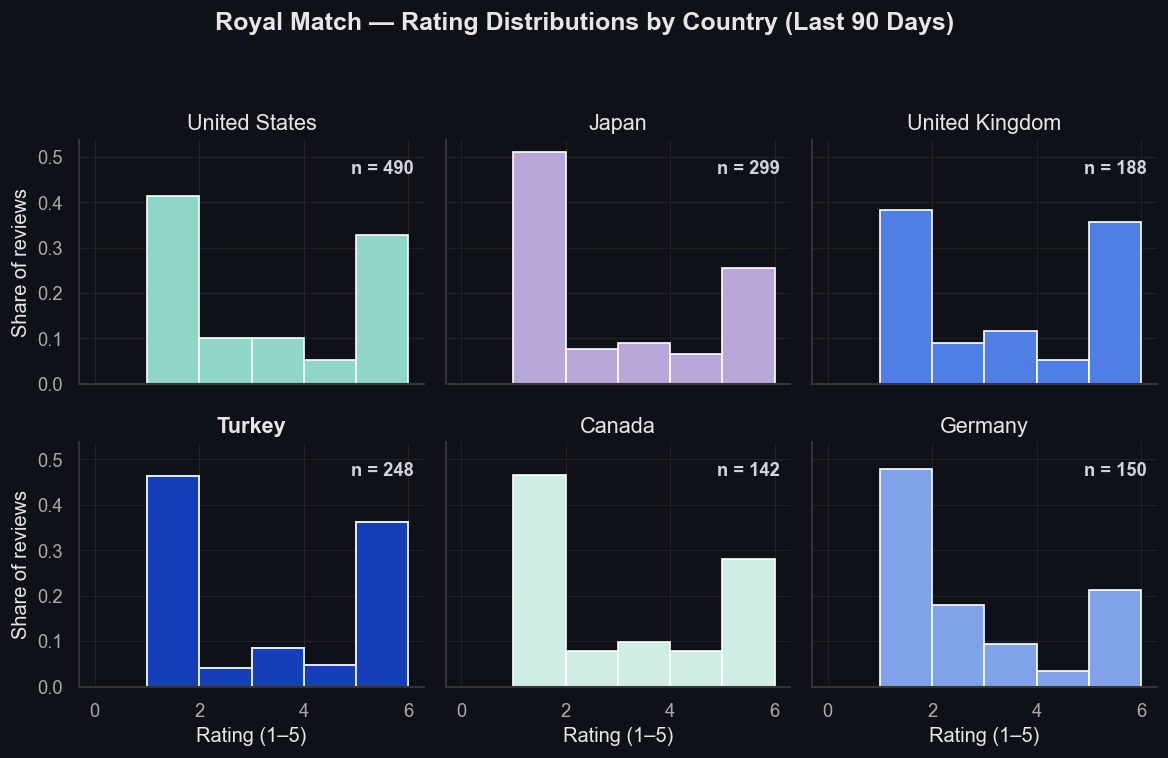

In [20]:
# =========================
# STEP 7.2 — Rating distributions by country
# (Royal Match, last 90 days)
# =========================

section("STEP 7.2 — RATING DISTRIBUTIONS BY COUNTRY (ROYAL MATCH, LAST 90 DAYS)")

df_rm_90 = dfw_90[dfw_90["game"] == "Royal Match"].copy()

g = sns.displot(
    data=df_rm_90,
    x="rating",
    col="country",
    col_wrap=3,
    discrete=True,
    binwidth=1,
    binrange=(0.5, 5.5),
    stat="probability",
    common_norm=False,
    height=3.0,
    aspect=1.1
)

for ax in g.axes.flatten():
    country = ax.get_title().replace("country = ", "")
    color = COUNTRY_PALETTE.get(country, "#9CA3AF")

    for patch in ax.patches:
        patch.set_facecolor(color)
        if country == "Turkey":
            patch.set_edgecolor("#DCE6FF")
            patch.set_linewidth(1.2)

    n = (df_rm_90["country"] == country).sum()
    ax.text(
        0.97, 0.92,
        f"n = {n}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        color="#D1D5DB",
        weight="bold"
    )

    ax.set_title(
        country,
        fontsize=13,
        weight="bold" if country == "Turkey" else None
    )

g.set_axis_labels("Rating (1–5)", "Share of reviews")

plt.suptitle(
    "Royal Match — Rating Distributions by Country (Last 90 Days)",
    y=1.05,
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()


STEP 7.3 — REVIEW VOLUME BY GAME × COUNTRY (LAST 90 DAYS)


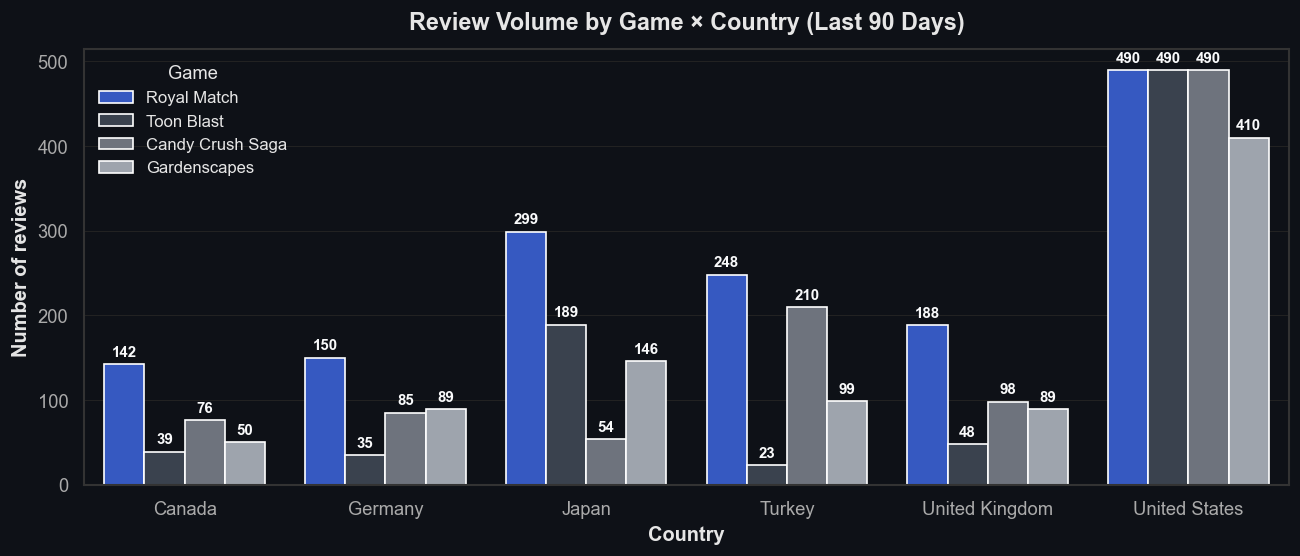

In [21]:
# =========================
# STEP 7.3 — Review volume by Game × Country (last 90 days)
# =========================

section("STEP 7.3 — REVIEW VOLUME BY GAME × COUNTRY (LAST 90 DAYS)")

volume_df = (
    dfw_90
        .groupby(["country", "game"])
        .size()
        .reset_index(name="n_reviews")
)

plt.figure(figsize=(11, 4.8))

ax = sns.barplot(
    data=volume_df,
    x="country",
    y="n_reviews",
    hue="game",
    order=sorted(volume_df["country"].unique()),
    hue_order=GAME_ORDER,
    palette=make_game_palette()
)

ax.set_title(
    "Review Volume by Game × Country (Last 90 Days)",
    fontsize=14,
    weight="bold",
    pad=12
)

ax.set_xlabel("Country", fontsize=12, weight="bold")
ax.set_ylabel("Number of reviews", fontsize=12, weight="bold")

ax.tick_params(axis="x", labelrotation=0, labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{int(v.get_height())}" for v in container],
        padding=3,
        fontsize=9,
        color="#F9FAFB",
        fontweight="bold"
    )

ax.legend(
    title="Game",
    title_fontsize=11,
    fontsize=10,
    frameon=False
)

plt.tight_layout()
plt.show()


STEP 7.4 — GAME × COUNTRY COMPARISONS (LAST 90 DAYS)


/var/folders/fx/jr13m5ds0l9d8cq0zzcs_ht40000gn/T/ipykernel_32970/1219721743.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


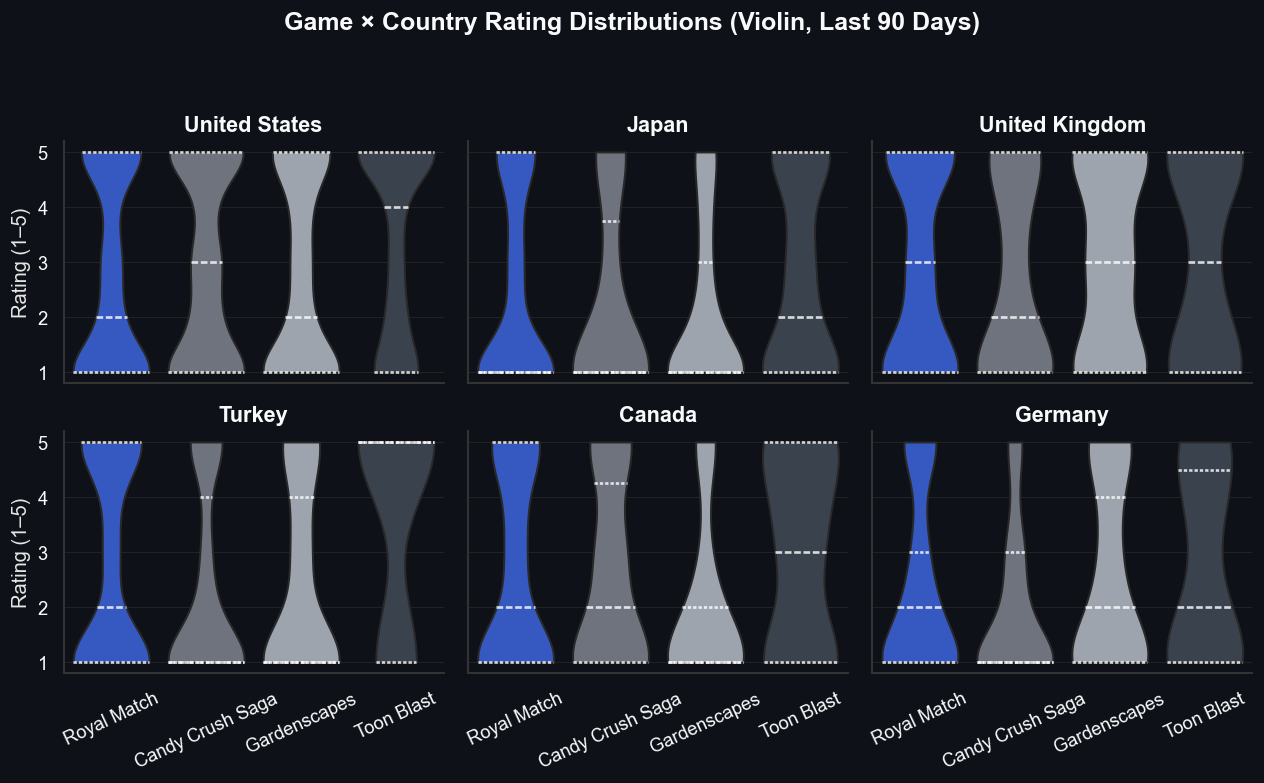

In [22]:
# =========================
# STEP 7.4 — Game × Country comparison (Violin, last 90 days)
# =========================

section("STEP 7.4 — GAME × COUNTRY COMPARISONS (LAST 90 DAYS)")

palette = make_game_palette()

g = sns.catplot(
    data=dfw_90,
    x="game",
    y="rating",
    col="country",
    col_wrap=3,
    kind="violin",
    inner="quartile",
    cut=0,
    palette=palette,
    linewidth=1.2,
    height=3.1,
    aspect=1.15,
    sharey=True
)

for ax in g.axes.flatten():
    country = ax.get_title().split(" = ")[-1]
    ax.set_title(
        country,
        fontsize=13,
        weight="bold",
        color="#F9FAFB"
    )

    for line in ax.lines:
        line.set_color("white")
        line.set_linewidth(1.6)
        line.set_alpha(0.8)

    ax.tick_params(
        axis="x",
        rotation=25,
        labelsize=11,
        colors="#F9FAFB"
    )
    ax.tick_params(
        axis="y",
        labelsize=11,
        colors="#F9FAFB"
    )

g.set_axis_labels("", "Rating (1–5)")

plt.suptitle(
    "Game × Country Rating Distributions (Violin, Last 90 Days)",
    y=1.05,
    fontsize=15,
    weight="bold",
    color="#F9FAFB"
)

plt.tight_layout()
plt.show()

In [23]:
# =========================
# STEP 7.4.2 — Derived Metrics & Polarization (Game × Country, last 90 days)
# =========================

section("STEP 7.4.2 — DERIVED METRICS & POLARIZATION (GAME × COUNTRY, LAST 90 DAYS)")

metrics_gc = (
    dfw_90
        .groupby(["game", "country"], as_index=False)
        .agg(
            n_reviews=("rating", "size"),
            mean_rating=("rating", "mean"),
            std_rating=("rating", "std"),
            pct_1star=("rating", lambda x: (x == 1).mean()),
            pct_5star=("rating", lambda x: (x == 5).mean()),
        )
)

metrics_gc["polarization"] = metrics_gc["pct_1star"] + metrics_gc["pct_5star"]

# Display formatting
metrics_gc_display = metrics_gc.copy()
for c in ["pct_1star", "pct_5star", "polarization"]:
    metrics_gc_display[c] = (metrics_gc_display[c] * 100).round(1)

metrics_gc_display["mean_rating"] = metrics_gc_display["mean_rating"].round(2)
metrics_gc_display["std_rating"] = metrics_gc_display["std_rating"].round(2)

metrics_gc_display = metrics_gc_display.sort_values(
    ["polarization", "n_reviews"],
    ascending=[False, False]
)

display(
    metrics_gc_display
        .style
        .apply(highlight_and_bold_royal_match, axis=1)
        .format({"n_reviews": "{:.0f}"})
)


STEP 7.4.2 — DERIVED METRICS & POLARIZATION (GAME × COUNTRY, LAST 90 DAYS)


,game,country,n_reviews,mean_rating,std_rating,pct_1star,pct_5star,polarization
21,Toon Blast,Turkey,23,3.610000,1.950000,34.800000,65.200000,100.000000
15,Royal Match,Turkey,248,2.810000,1.840000,46.400000,36.300000,82.700000
3,Candy Crush Saga,Turkey,210,2.280000,1.680000,56.200000,23.800000,80.000000
2,Candy Crush Saga,Japan,54,2.240000,1.670000,57.400000,22.200000,79.600000
22,Toon Blast,United Kingdom,48,3.040000,1.830000,37.500000,41.700000,79.200000
9,Gardenscapes,Turkey,99,2.430000,1.700000,52.500000,24.200000,76.800000
14,Royal Match,Japan,299,2.470000,1.720000,51.200000,25.400000,76.600000
12,Royal Match,Canada,142,2.630000,1.740000,46.500000,28.200000,74.600000
17,Royal Match,United States,490,2.780000,1.760000,41.400000,32.900000,74.300000
6,Gardenscapes,Canada,50,2.000000,1.480000,58.000000,16.000000,74.000000



STEP 7.5 — HEATMAP: MEAN RATING (GAME × COUNTRY, LAST 90 DAYS)


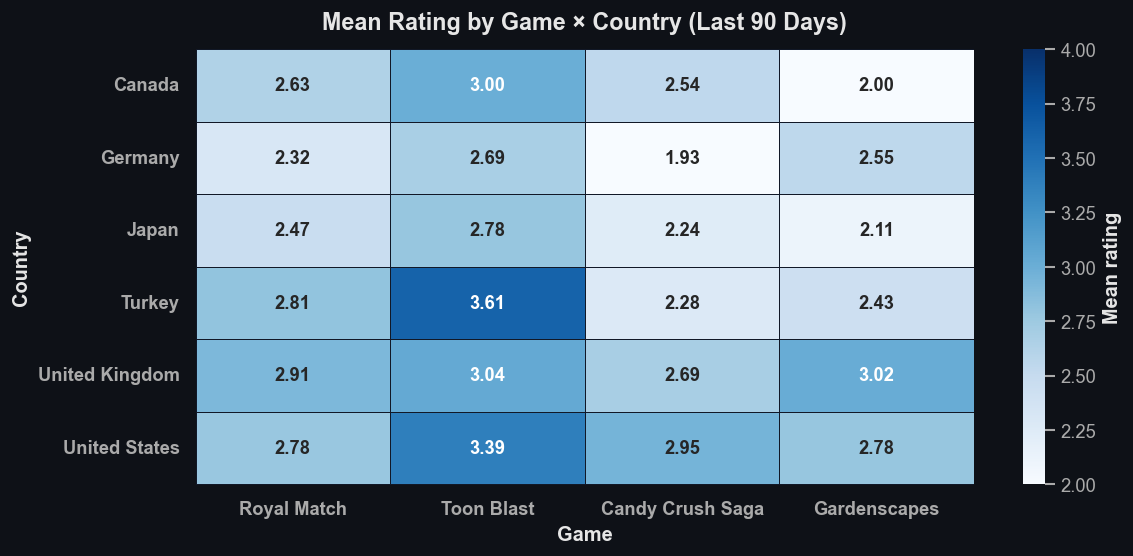

In [24]:
# =========================
# STEP 7.5 — Heatmap: mean rating by Game × Country (last 90 days)
# =========================

section("STEP 7.5 — HEATMAP: MEAN RATING (GAME × COUNTRY, LAST 90 DAYS)")

mean_mat = (
    dfw_90
        .pivot_table(
            index="country",
            columns="game",
            values="rating",
            aggfunc="mean"
        )
        .reindex(columns=GAME_ORDER)
)

plt.figure(figsize=(10, 4.8))

ax = sns.heatmap(
    mean_mat,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette("Blues", as_cmap=True),
    vmin=2.0,
    vmax=4.0,
    linewidths=0.6,
    linecolor="#111827",
    cbar_kws={"label": "Mean rating"},
    annot_kws={
        "fontsize": 11,
        "fontweight": "bold"
    }
)

plt.title(
    "Mean Rating by Game × Country (Last 90 Days)",
    fontsize=14,
    weight="bold",
    pad=12
)

plt.xlabel("Game", fontsize=12, weight="bold")
plt.ylabel("Country", fontsize=12, weight="bold")

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for t in ax.get_xticklabels():
    t.set_fontweight("bold")

for t in ax.get_yticklabels():
    t.set_fontweight("bold")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Mean rating", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()


STEP 7.6 — REVIEW LENGTH vs RATING (ROYAL MATCH, LAST 90 DAYS, NON-JP)


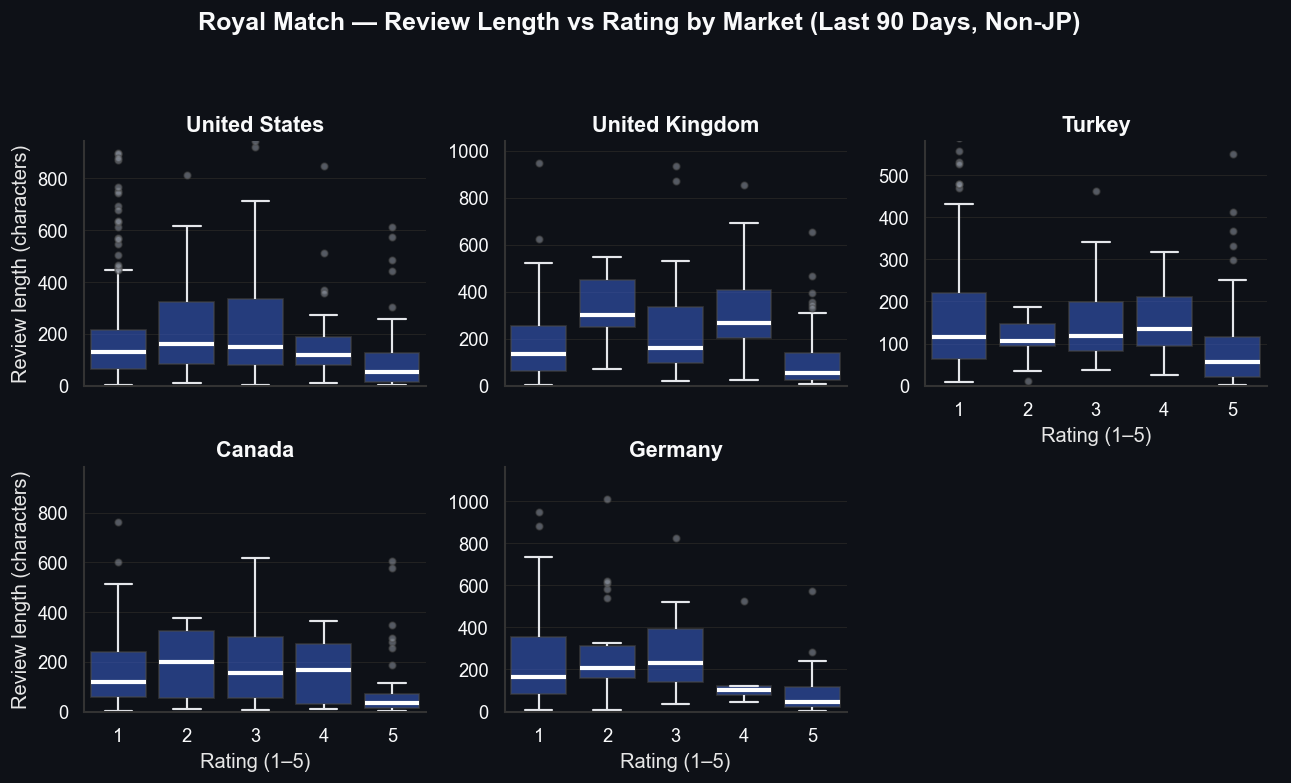

In [25]:
# =========================
# STEP 7.6 — Review Length vs Rating
# (Royal Match, last 90 days, non-JP, within-market panels)
# =========================

section("STEP 7.6 — REVIEW LENGTH vs RATING (ROYAL MATCH, LAST 90 DAYS, NON-JP)")

df_rm_90_nonjp = (
    dfw_90[
        (dfw_90["game"] == "Royal Match") &
        (dfw_90["country"] != "Japan")
    ]
    .copy()
)

g = sns.catplot(
    data=df_rm_90_nonjp,
    x="rating",
    y="char_count",
    col="country",
    col_wrap=3,
    kind="box",
    height=3.1,
    aspect=1.15,
    sharey=False,
    color="#1f4ed8",
    showfliers=True,
    boxprops={"alpha": 0.6},
    medianprops={"color": "white", "linewidth": 2.5},
    whiskerprops={"color": "#E5E7EB", "linewidth": 1.3},
    capprops={"color": "#E5E7EB", "linewidth": 1.3},
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#9CA3AF",
        "alpha": 0.5
    }
)

for ax in g.axes.flatten():
    country = ax.get_title().split(" = ")[-1]

    upper = (
        df_rm_90_nonjp[df_rm_90_nonjp["country"] == country]["char_count"]
        .quantile(0.99)
    )

    ax.set_ylim(0, upper * 1.05)

    ax.set_title(country, fontsize=13, weight="bold", color="#F9FAFB")
    ax.tick_params(axis="x", labelsize=11, colors="#F9FAFB")
    ax.tick_params(axis="y", labelsize=11, colors="#F9FAFB")

g.set_axis_labels("Rating (1–5)", "Review length (characters)")

plt.suptitle(
    "Royal Match — Review Length vs Rating by Market (Last 90 Days, Non-JP)",
    y=1.05,
    fontsize=15,
    weight="bold",
    color="#F9FAFB"
)

plt.tight_layout()
plt.show()

### Step 7 Summary — Rating Landscape (Last 90 Days)

#### Rating distributions by game 

All four games show **strongly bimodal distributions** with mass concentrated at 1★ and 5★, confirming the polarized nature of App Store written reviews. **Toon Blast** stands out with the highest 5★ share and lowest 1★ share, making it the relative leader in this sample. **Royal Match, Candy Crush Saga, and Gardenscapes** all show a 1★-heavy skew, with Royal Match sitting between Toon Blast and the legacy titles.

#### Royal Match across markets 

Within Royal Match, market-level differences are pronounced. **Japan and Germany** show the heaviest 1★ concentration (~48–51%), while **Turkey** follows closely (~46%). **United States and United Kingdom** are more balanced, with a stronger 5★ presence (~33–36%). This suggests that dissatisfaction patterns are market-specific rather than uniform.

#### Volume context 

The **United States** is by far the most data-dense market (490 reviews for RM, and 490 each for Toon Blast and CCS — likely hitting the pagination cap). **Turkey (248), Japan (299), UK (188), Germany (150), and Canada (142)** provide usable but smaller samples. Low-volume cells (e.g., Toon Blast Turkey: n=23) should be interpreted with caution.

#### Game × country comparisons 

The heatmap confirms that **Toon Blast** leads in mean rating across nearly all markets, most notably in **Turkey (3.61)** and **US (3.39)**. Royal Match is competitive in **UK (2.91 vs Toon Blast 3.04)** — the narrowest gap in the dataset — and ahead of Candy Crush and Gardenscapes in Turkey. **Germany** is the weakest market for Royal Match (mean 2.32), with Candy Crush Saga even lower (1.93).

#### Polarization

Polarization (pct_1★ + pct_5★) ranges from ~66% to ~100% across game × country pairs. **Toon Blast Turkey (100%)** is an extreme case driven by very small sample size (n=23). Among reliable cells, **Royal Match Turkey (82.7%)** shows the highest polarization — a large 1★ block coexisting with strong 5★ advocacy. This pattern suggests that improvement opportunities lie in **converting dissatisfied users** rather than shifting a moderate middle.

#### Review length vs rating 

Within each market, the pattern is consistent: **lower ratings are associated with longer reviews**, while **5★ feedback tends to be short**. This holds across all five non-JP markets. The pattern reflects a behavioral signal — dissatisfied users invest more effort in explaining their frustration — rather than a linguistic artifact. Cross-market absolute comparisons of review length are avoided due to structural differences between languages (agglutinative Turkish vs. analytic English/German).

> **Note:** Step 7.6 uses all non-JP Royal Match reviews without a dominant-language filter. Since markets are overwhelmingly single-language (Step 5), this has minimal practical impact but is noted for completeness.

#### Key takeaways for downstream steps

- **Market-specific diagnosis is essential** — Germany and Japan behave structurally differently from US/UK/Turkey.
- **Toon Blast is the primary competitive benchmark** — it leads in nearly every market.
- **UK is the closest competitive parity zone** for Royal Match — the narrowest gap to Toon Blast and the most balanced 1★/5★ split.
- These descriptive patterns set the stage for **temporal analysis (Step 8)** to determine whether rating shifts align with specific app updates.

>Across all non-JP markets, 5★ reviews tend to be consistently shorter than lower-rated reviews.
This suggests that positive feedback is often expressed with low effort, while dissatisfaction (especially 1–3★) more frequently triggers longer, more detailed explanations.
The pattern is stable across markets, indicating a behavioral signal rather than a market-specific artifact.

**Note:** Review length distributions are highly right-skewed across markets. To improve visual readability without removing any observations, y-axis limits are set using the 99th percentile of review length per market, with a small buffer above the cutoff.

## Step 8 — Temporal Dynamics & Update Impact (Royal Match, Last 90 Days)

This step introduces a time-series perspective to assess whether daily review signals for Royal Match show **meaningful temporal patterns and update-aligned shifts**.

Daily aggregates are examined for review volume, average rating, and extreme rating shares (1★ and 5★), with explicit safeguards for low-volume days. Rolling averages and simple baselines are used to smooth short-term noise and to identify periods where event-based dynamics may be present.

The step covers two layers:
- **Temporal diagnostics** (8.1–8.4): daily signals, smoothed ratings, baseline deviation, and critical drop detection.
- **Update impact preview** (8.5–8.8): event-level pre/post comparison at the country × version level.

The goal is descriptive — identifying *which* updates align with visible rating shifts — not causal inference.

In [26]:
# =========================
# STEP 8.1a — Daily aggregation (diagnostic layer)
# =========================

section("STEP 8.1a — DAILY TIME SERIES (ROYAL MATCH, LAST 90 DAYS)")

# Base filter
df_ts = df_rm_90.copy()

# --- Country-level avg rating (review-level, constant per country)
country_rating = (
    df_ts.groupby("country")["rating"]
         .mean()
         .rename("country_avg_rating")
         .reset_index()
)

# --- Daily aggregation by country
df_day = (
    df_ts
        .groupby(["country", "day"])
        .agg(
            n_reviews=("rating", "size"),
            avg_rating=("rating", "mean"),
            p_1star=("rating", lambda x: (x == 1).mean()),
            p_5star=("rating", lambda x: (x == 5).mean())
        )
        .reset_index()
        .merge(country_rating, on="country", how="left")
        .sort_values(["country", "day"])
)

df_day.head()


STEP 8.1a — DAILY TIME SERIES (ROYAL MATCH, LAST 90 DAYS)


,country,day,n_reviews,avg_rating,p_1star,p_5star,country_avg_rating
0,Canada,2025-10-13,4,3.25,0.25,0.5,2.6338
1,Canada,2025-10-14,1,5.00,0.00,1.0,2.6338
2,Canada,2025-10-15,1,5.00,0.00,1.0,2.6338
3,Canada,2025-10-17,1,1.00,1.00,0.0,2.6338
4,Canada,2025-10-18,1,1.00,1.00,0.0,2.6338



STEP 8.1 — DIAGNOSTIC LAYER (RAW DAILY SIGNALS, RM, LAST 90 DAYS)


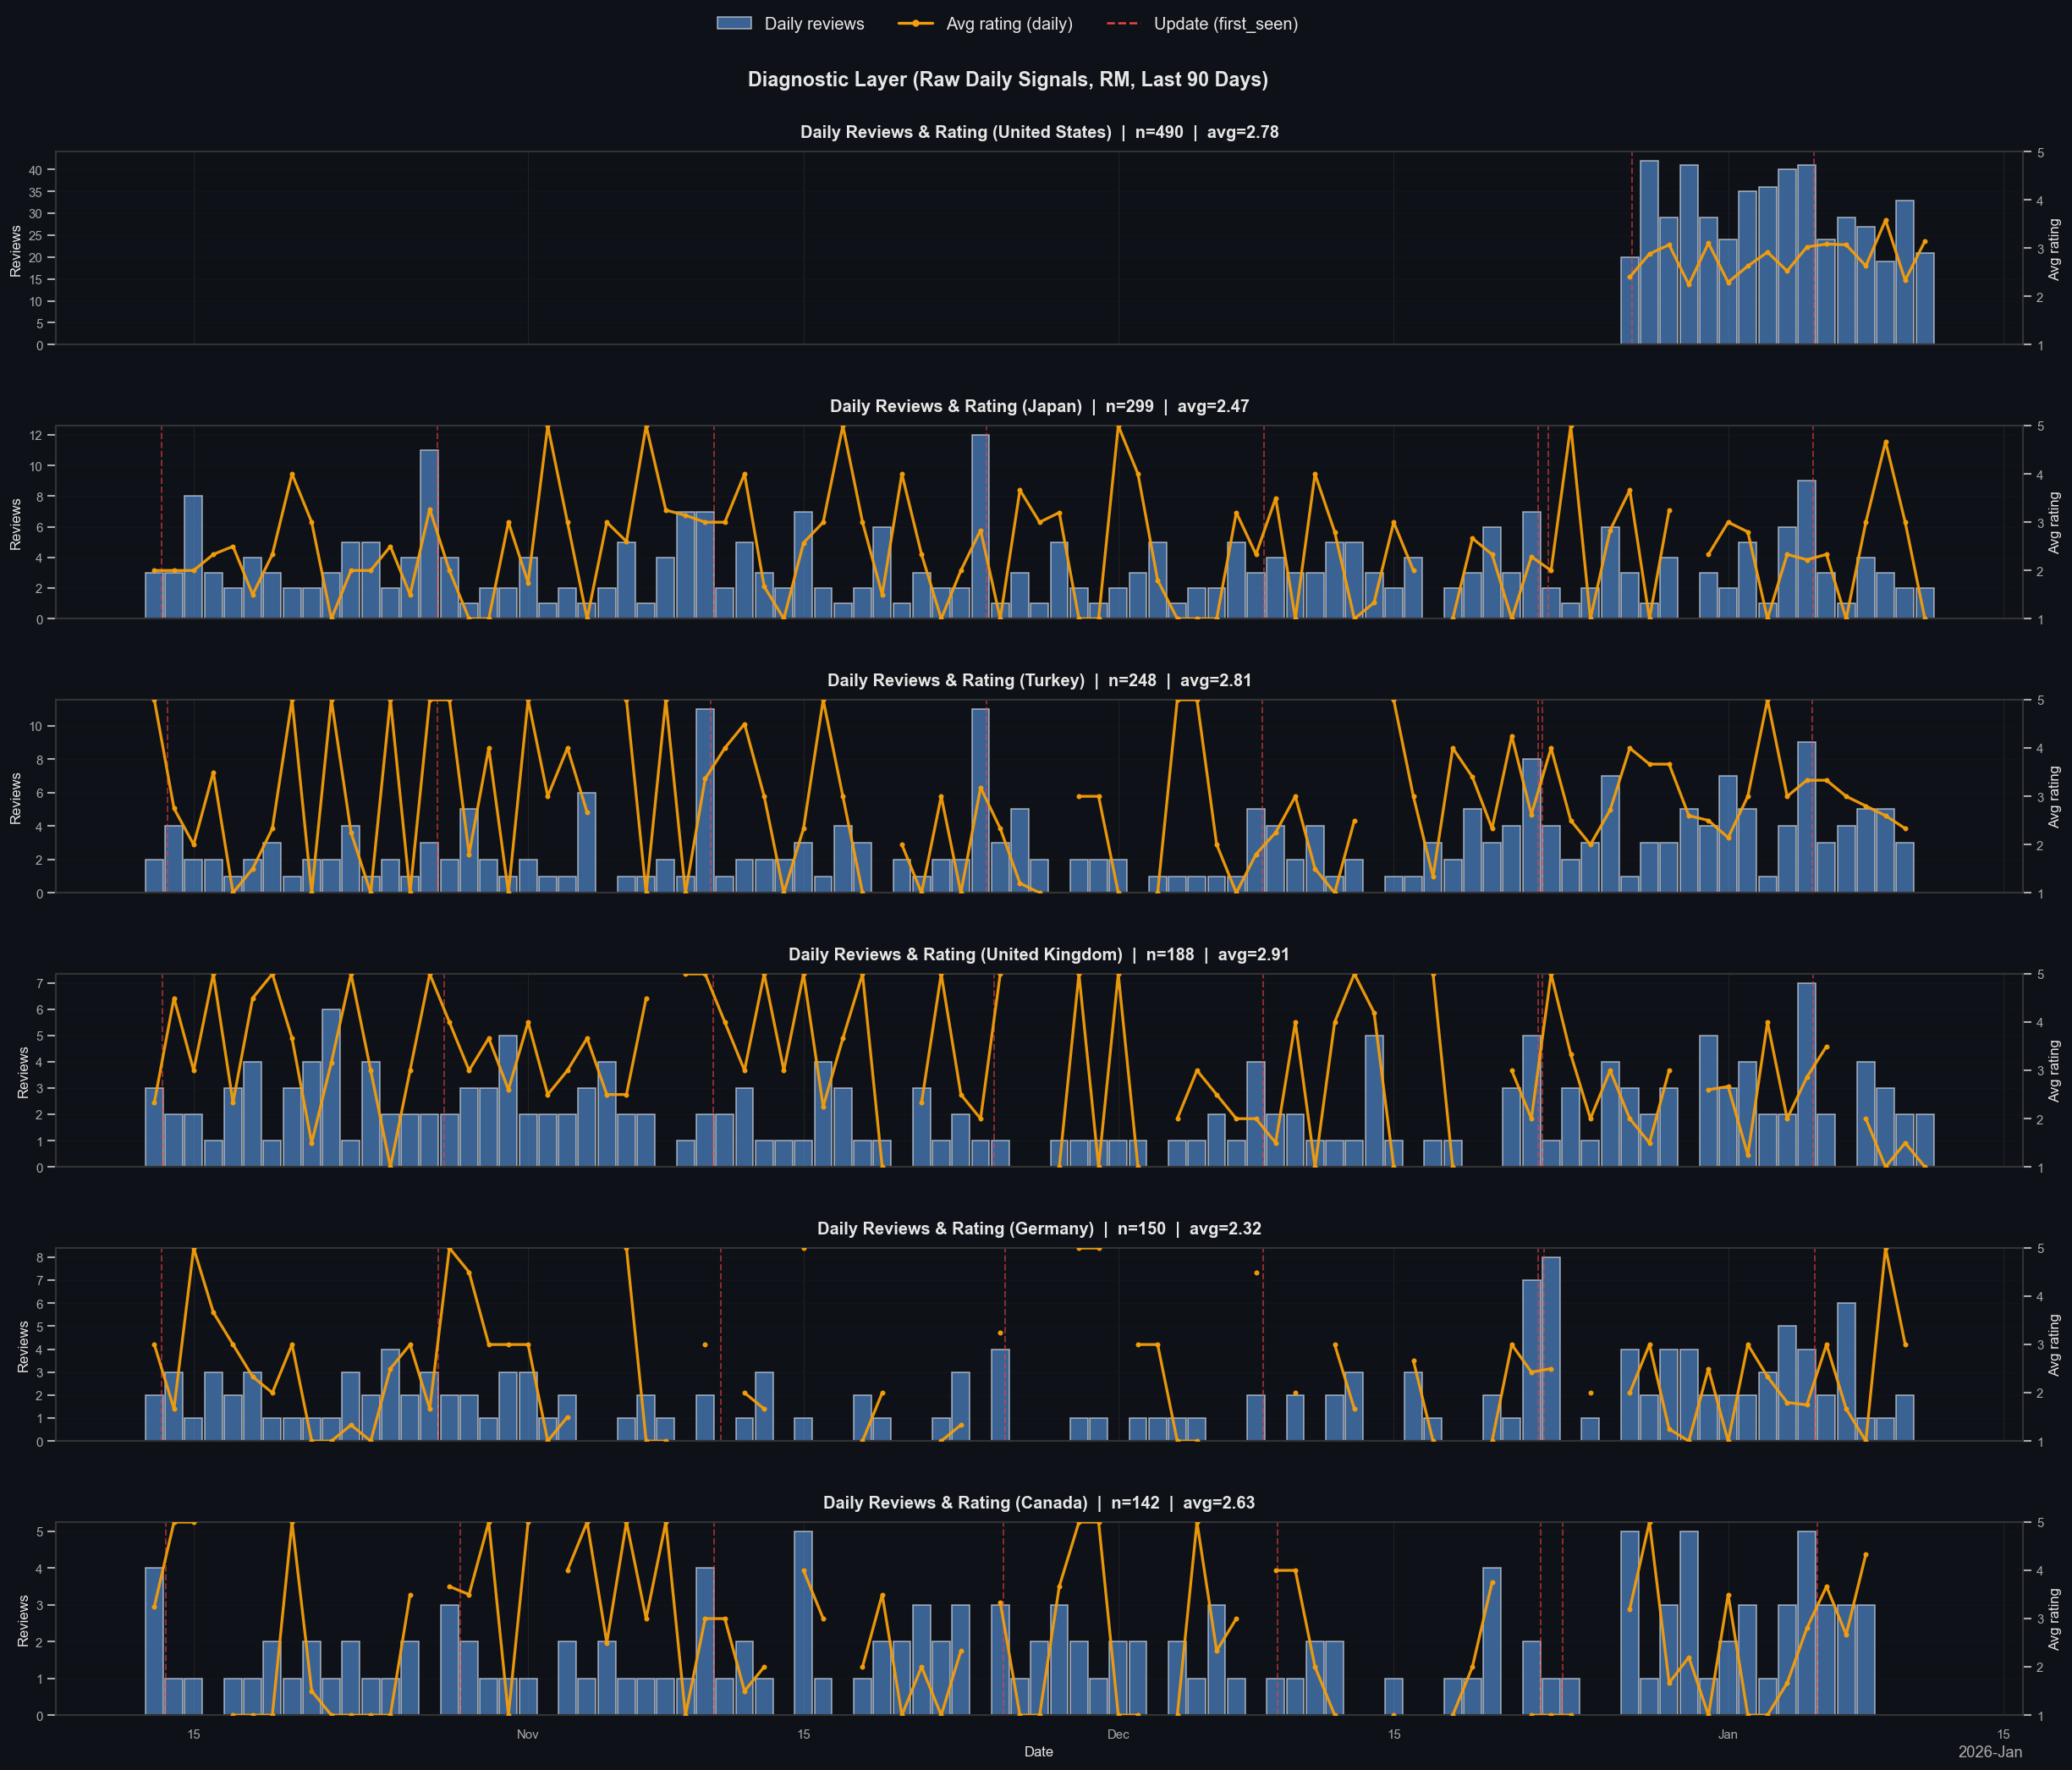

In [27]:
# =========================
# STEP 8.1 — Diagnostic Layer 
# =========================

section("STEP 8.1 — DIAGNOSTIC LAYER (RAW DAILY SIGNALS, RM, LAST 90 DAYS)")

# --- Colors
COLOR_VOL = "#60A5FA"     # volume
COLOR_RAT = "#F59E0B"     # rating
COLOR_UPDATE = "#EF4444"  # update markers

# --- Defensive copies & datetime
df_day = df_day.copy()
df_day["day"] = pd.to_datetime(df_day["day"])

df_rm_90 = df_rm_90.copy()
df_rm_90["first_seen"] = pd.to_datetime(df_rm_90["first_seen"])

# --- Order countries by total volume 
countries = (
    df_day.groupby("country")["n_reviews"]
          .sum()
          .sort_values(ascending=False)
          .index
          .tolist()
)

# --- Global date range 
global_min = df_day["day"].min()
global_max = df_day["day"].max()
all_days = pd.date_range(global_min, global_max, freq="D")

# --- Date formatting 
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
formatter = mdates.ConciseDateFormatter(locator)

# --- Figure / axes
fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    figsize=(25, 20),
    sharex=True
)
if len(countries) == 1:
    axes = [axes]

fig.subplots_adjust(top=0.88, hspace=0.42)

for ax, country in zip(axes, countries):
    # -------------------------
    # Build full daily frame 
    # -------------------------
    d0 = (
        df_day[df_day["country"] == country]
        .sort_values("day")
        .set_index("day")
        .reindex(all_days)
    )

    d0["country"] = country
    d0["n_reviews"] = d0["n_reviews"].fillna(0).astype(int)

    # -------------------------
    # Volume as bars (clean)
    # -------------------------
    ax.bar(
        d0.index,
        d0["n_reviews"],
        color=COLOR_VOL,
        alpha=0.55,
        width=0.9,
        zorder=1
    )
    ax.set_ylabel("Reviews", fontsize=10)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="y", labelsize=9)

    # -------------------------
    # Rating as line 
    # -------------------------
    ax2 = ax.twinx()
    ax2.plot(
        d0.index,
        d0["avg_rating"],
        color=COLOR_RAT,
        linewidth=2.0,
        marker="o",
        markersize=2.6,
        alpha=0.95,
        zorder=3
    )
    ax2.set_ylim(1, 5)
    ax2.set_ylabel("Avg rating", fontsize=10)
    ax2.tick_params(axis="y", labelsize=9)
    ax2.grid(False)

    # -------------------------
    # Update markers 
    # -------------------------
    updates = (
        df_rm_90.loc[df_rm_90["country"] == country, "first_seen"]
              .dropna()
              .drop_duplicates()
              .sort_values()
    )
    updates = updates[(updates >= global_min) & (updates <= global_max)]

    for fs in updates:
        ax.axvline(
            fs,
            linestyle="--",
            color=COLOR_UPDATE,
            alpha=0.55,
            linewidth=1.2,
            zorder=2
        )

    # -------------------------
    # Title
    # -------------------------
    total_n = int(d0["n_reviews"].sum())

    country_avg = (
        df_day.loc[df_day["country"] == country, "country_avg_rating"]
              .dropna()
    )
    avg_txt = f"{float(country_avg.iloc[0]):.2f}" if len(country_avg) > 0 else "NA"

    ax.set_title(
        f"Daily Reviews & Rating ({country})  |  n={total_n:,}  |  avg={avg_txt}",
        fontsize=12,
        fontweight="bold",
        pad=10
    )

# --- X-axis formatting 
axes[-1].set_xlabel("Date", fontsize=10)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(formatter)
axes[-1].tick_params(axis="x", labelsize=9)

# --- Single shared legend
legend_handles = [
    Patch(facecolor=COLOR_VOL, alpha=0.55, label="Daily reviews"),
    Line2D([0], [0], color=COLOR_RAT, lw=2.0, marker="o", markersize=4, label="Avg rating (daily)"),
    Line2D([0], [0], color=COLOR_UPDATE, lw=1.5, ls="--", label="Update (first_seen)")
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.95),
    borderaxespad=0.0
)

# --- Main title
fig.suptitle(
    "Diagnostic Layer (Raw Daily Signals, RM, Last 90 Days)",
    fontsize=14,
    fontweight="bold",
    y=0.92
)

plt.show()

> Daily average ratings exhibit noticeable short-term volatility across markets; however, in the United States, the consistently high daily review volume appears to anchor ratings within a relatively narrow range. In Turkey, daily review volumes increase visibly following recent updates, while in the United Kingdom, multiple updates—most notably in early November—are followed by higher review activity even as average ratings appear to decline. Overall, rating movements do not align perfectly with update timings, indicating that **update impacts require more detailed, event-focused analysis in subsequent steps**.


In [28]:
# =========================
# STEP 8.2a — Volume-weighted rolling rating (7d)
# =========================

section("STEP 8.2a — SMOOTHED RATING (VOLUME-WEIGHTED, 7D)")

df_roll = df_day.copy()
df_roll = df_roll.sort_values(["country", "day"])

# --- Helper columns
df_roll["rating_x_volume"] = df_roll["avg_rating"] * df_roll["n_reviews"]

# --- Rolling (country-specific) 
num = (
    df_roll.groupby("country")["rating_x_volume"]
          .transform(lambda s: s.rolling(window=7, min_periods=4).sum())
)

den = (
    df_roll.groupby("country")["n_reviews"]
          .transform(lambda s: s.rolling(window=7, min_periods=4).sum())
)

df_roll["rating_weighted_7d"] = num / den

# --- QC: quick sanity check
df_roll[
    ["country", "day", "n_reviews", "avg_rating", "rating_weighted_7d"]
].head(10)



STEP 8.2a — SMOOTHED RATING (VOLUME-WEIGHTED, 7D)


,country,day,n_reviews,avg_rating,rating_weighted_7d
0,Canada,2025-10-13,4,3.25,NaN
1,Canada,2025-10-14,1,5.00,NaN
2,Canada,2025-10-15,1,5.00,NaN
3,Canada,2025-10-17,1,1.00,3.4286
4,Canada,2025-10-18,1,1.00,3.1250
5,Canada,2025-10-19,2,1.00,2.7000
6,Canada,2025-10-20,1,5.00,2.9091
7,Canada,2025-10-21,2,1.50,2.4444
8,Canada,2025-10-22,1,1.00,2.0000
9,Canada,2025-10-23,2,1.00,1.5000


>I apply a 7-day, volume-weighted rolling average with **a minimum of four active days to reduce day-level noise**—**especially in low-volume markets**—while retaining short-term, multi-day movements that may reflect genuine post-update sentiment shifts.

In [29]:
# =========================
# STEP 8.2b — 14-day baseline & deviation (VOLUME-WEIGHTED)
# =========================

section("STEP 8.2b — BASELINE (14D, VOLUME-WEIGHTED) & DEVIATION")

df_roll = df_roll.sort_values(["country", "day"])

df_roll["rating_x_volume"] = df_roll["avg_rating"] * df_roll["n_reviews"]

# --- Past-only 14d volume-weighted baseline
num_14 = (
    df_roll
        .groupby("country")["rating_x_volume"]
        .transform(lambda s: s.shift(1).rolling(window=14, min_periods=10).sum())
)

den_14 = (
    df_roll
        .groupby("country")["n_reviews"]
        .transform(lambda s: s.shift(1).rolling(window=14, min_periods=10).sum())
)

df_roll["baseline_14d_rating"] = num_14 / den_14

# --- Deviation vs baseline
df_roll["delta_vs_baseline"] = (
    df_roll["rating_weighted_7d"] - df_roll["baseline_14d_rating"]
)

# --- QC snapshot
df_roll[
    [
        "country",
        "day",
        "n_reviews",
        "rating_weighted_7d",
        "baseline_14d_rating",
        "delta_vs_baseline"
    ]
].head(15)



STEP 8.2b — BASELINE (14D, VOLUME-WEIGHTED) & DEVIATION


,country,day,n_reviews,rating_weighted_7d,baseline_14d_rating,delta_vs_baseline
0,Canada,2025-10-13,4,NaN,NaN,NaN
1,Canada,2025-10-14,1,NaN,NaN,NaN
2,Canada,2025-10-15,1,NaN,NaN,NaN
3,Canada,2025-10-17,1,3.4286,NaN,NaN
4,Canada,2025-10-18,1,3.1250,NaN,NaN
5,Canada,2025-10-19,2,2.7000,NaN,NaN
6,Canada,2025-10-20,1,2.9091,NaN,NaN
7,Canada,2025-10-21,2,2.4444,NaN,NaN
8,Canada,2025-10-22,1,2.0000,NaN,NaN
9,Canada,2025-10-23,2,1.5000,NaN,NaN


>I construct a past-only, **14-day volume-weighted baseline** (min. 10 days) to represent a stable recent reference level, and compute a **delta vs baseline** by comparing this reference to the smoothed 7-day signal. This delta captures **relative deviation from each country’s own recent norm**, allowing consistent detection of potential sentiment shifts beyond normal fluctuation, independent of absolute rating levels.

In [30]:
# =========================
# STEP 8.3 — Directional support (%1★ / %5★, rolling 7d)
# =========================

section("STEP 8.3 — DIRECTIONAL SUPPORT (1★ / 5★, ROLLING 7D)")


# --- Helper counts (daily)
df_roll["n_1star"] = df_roll["p_1star"] * df_roll["n_reviews"]
df_roll["n_5star"] = df_roll["p_5star"] * df_roll["n_reviews"]

# --- Rolling 7d totals (past + today)
n1_7d = (
    df_roll.groupby("country")["n_1star"]
           .transform(lambda s: s.rolling(window=7, min_periods=4).sum())
)

n5_7d = (
    df_roll.groupby("country")["n_5star"]
           .transform(lambda s: s.rolling(window=7, min_periods=4).sum())
)

nrev_7d = (
    df_roll.groupby("country")["n_reviews"]
           .transform(lambda s: s.rolling(window=7, min_periods=4).sum())
)

# --- Rolling proportions
df_roll["p1_7d"] = n1_7d / nrev_7d
df_roll["p5_7d"] = n5_7d / nrev_7d

df_roll["n_reviews_7d"] = (
    df_roll.groupby("country")["n_reviews"]
           .transform(lambda s: s.rolling(window=7, min_periods=4).sum())
)

# --- QC snapshot
df_roll[
    [
        "country",
        "day",
        "rating_weighted_7d",
        "baseline_14d_rating",
        "delta_vs_baseline",
        "p1_7d",
        "p5_7d"
    ]
].head(15)



STEP 8.3 — DIRECTIONAL SUPPORT (1★ / 5★, ROLLING 7D)


,country,day,rating_weighted_7d,baseline_14d_rating,delta_vs_baseline,p1_7d,p5_7d
0,Canada,2025-10-13,NaN,NaN,NaN,NaN,NaN
1,Canada,2025-10-14,NaN,NaN,NaN,NaN,NaN
2,Canada,2025-10-15,NaN,NaN,NaN,NaN,NaN
3,Canada,2025-10-17,3.4286,NaN,NaN,0.2857,0.5714
4,Canada,2025-10-18,3.1250,NaN,NaN,0.3750,0.5000
5,Canada,2025-10-19,2.7000,NaN,NaN,0.5000,0.4000
6,Canada,2025-10-20,2.9091,NaN,NaN,0.4545,0.4545
7,Canada,2025-10-21,2.4444,NaN,NaN,0.5556,0.3333
8,Canada,2025-10-22,2.0000,NaN,NaN,0.6667,0.2222
9,Canada,2025-10-23,1.5000,NaN,NaN,0.8000,0.1000


>I compute 7-day rolling **shares of 1★ and 5★ reviews** to provide directional support for rating movements, helping distinguish whether deviations are driven by increased negative feedback, positive reinforcement, or changes in review volume composition.

In [31]:
# =========================
# Volume profile per country (7d)
# =========================

vol_profile = (
    df_roll
        .groupby("country")["n_reviews_7d"]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .reset_index()
)

vol_profile


,country,count,mean,std,min,25%,50%,75%,max
0,Canada,71.0000,12.9296,3.3735,6.0000,11.0000,12.0000,15.0000,21.0000
1,Germany,64.0000,15.5625,5.2247,6.0000,12.0000,14.0000,19.0000,30.0000
2,Japan,87.0000,23.3678,4.7277,13.0000,20.0000,24.0000,27.0000,34.0000
3,Turkey,83.0000,19.7349,6.8273,8.0000,15.0000,17.0000,26.0000,35.0000
4,United Kingdom,79.0000,15.8354,4.9702,7.0000,12.0000,16.0000,20.0000,26.0000
5,United States,14.0000,201.2857,45.0323,91.0000,187.2500,218.0000,231.2500,246.0000


> **Critical drop candidates (event signals)**
To surface **dates that may represent meaningful negative events**, we flag *critical drop candidates* where the smoothed rating falls notably below a recent, country-specific baseline—without claiming statistical certainty. Because low review counts can create noisy movements, we first profile each country’s **7-day review volume** and require sufficient activity before treating a drop as interpretable. 
We set an absolute floor of **15 reviews** as a practical minimum to reduce binomial-style noise in daily/weekly sentiment composition, and combine it with market adaptiveness by using a **country-specific threshold based on the median 7-day volume**:  
`min_reviews_7d(c) = max(15, median_c(n_reviews_7d))`.  
Given the relatively low volumes in parts of the sample, we also tighten the drop criterion to **Δ vs baseline ≤ -0.30** to remain conservative and focus on the most credible event candidates.


In [32]:
# =========================
# STEP 8.4 — CRITICAL DROP DETECTION (EVENT CANDIDATES)
# =========================

section("STEP 8.4 — CRITICAL DROP DETECTION (EVENT CANDIDATES)")

# -------------------------------------------------
#    Country-specific volume thresholds
#    min_reviews_7d(country) = max(15, p50_country)
# -------------------------------------------------
country_p50 = (
    df_roll
        .groupby("country")["n_reviews_7d"]
        .median()
)

df_roll["min_reviews_7d"] = df_roll["country"].map(
    lambda c: max(15, country_p50.loc[c])
)

DROP_THRESHOLD = -0.3

df_roll["is_critical_drop"] = (
    (df_roll["delta_vs_baseline"] <= DROP_THRESHOLD) &
    (df_roll["n_reviews_7d"] >= df_roll["min_reviews_7d"])
)

# --- "Dip gün" filtresi: delta yerel minimum mu? (country içinde)
prev_delta = df_roll.groupby("country")["delta_vs_baseline"].shift(1)
next_delta = df_roll.groupby("country")["delta_vs_baseline"].shift(-1)

df_roll["is_local_min_delta"] = (
    df_roll["delta_vs_baseline"].notna() &
    (df_roll["delta_vs_baseline"] <= prev_delta) &
    (df_roll["delta_vs_baseline"] <= next_delta)
)

df_roll["critical_drop_peak"] = df_roll["is_critical_drop"] & df_roll["is_local_min_delta"]


event_candidates = df_roll.loc[df_roll["critical_drop_peak"]==True]

event_candidates[["day","country", "n_reviews", "n_reviews_7d", "avg_rating", "rating_weighted_7d", "baseline_14d_rating","delta_vs_baseline"]]. \
    sort_values("delta_vs_baseline")



STEP 8.4 — CRITICAL DROP DETECTION (EVENT CANDIDATES)


,day,country,n_reviews,n_reviews_7d,avg_rating,rating_weighted_7d,baseline_14d_rating,delta_vs_baseline
39,2025-11-27,Canada,2,16.0,1.0000,1.8750,2.5806,-0.7056
87,2025-10-27,Germany,3,16.0,1.6667,1.8125,2.3793,-0.5668
68,2026-01-04,Canada,3,18.0,1.6667,1.8333,2.2903,-0.4570
381,2025-12-28,United Kingdom,2,19.0,1.5000,2.5263,2.9677,-0.4414
269,2025-11-25,Turkey,3,24.0,2.3333,2.4167,2.8298,-0.4131
129,2026-01-01,Germany,2,19.0,1.0000,1.6842,2.0909,-0.4067
325,2025-10-25,United Kingdom,2,21.0,1.0000,2.8571,3.2353,-0.3782
250,2025-11-04,Turkey,6,18.0,2.6667,2.8333,3.2069,-0.3736
206,2025-12-20,Japan,6,25.0,2.3333,1.8800,2.2391,-0.3591
31,2025-11-18,Canada,1,15.0,2.0000,3.0000,3.3333,-0.3333


>In this step, I identify **critical drop candidates** as dates where the smoothed rating falls sharply below its recent baseline (Δ ≤ −0.30) under sufficient review volume support, without asserting statistical causality. To avoid fragmented signals during multi-day declines, we retain only **local minima in the delta series**, capturing the lowest point of each potential event. While this table provides a concise shortlist of candidates, **event-centric time-series visualization is required** to interpret context, recovery patterns, and alignment with updates.



STEP 8.4b — EVENT-CENTRIC TIME SERIES (RM, LAST 90 DAYS)
Update dates (unique, all countries):
2025-10-13, 2025-10-13, 2025-10-13, 2025-10-13, 2025-10-13, 2025-10-27, 2025-10-27, 2025-10-27, 2025-10-27, 2025-10-28, 2025-11-10, 2025-11-10, 2025-11-10, 2025-11-10, 2025-11-10, 2025-11-24, 2025-11-24, 2025-11-24, 2025-11-25, 2025-11-25, 2025-12-08, 2025-12-08, 2025-12-08, 2025-12-08, 2025-12-09, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-22, 2025-12-23, 2025-12-27, 2026-01-05, 2026-01-05, 2026-01-05, 2026-01-05, 2026-01-05, 2026-01-05


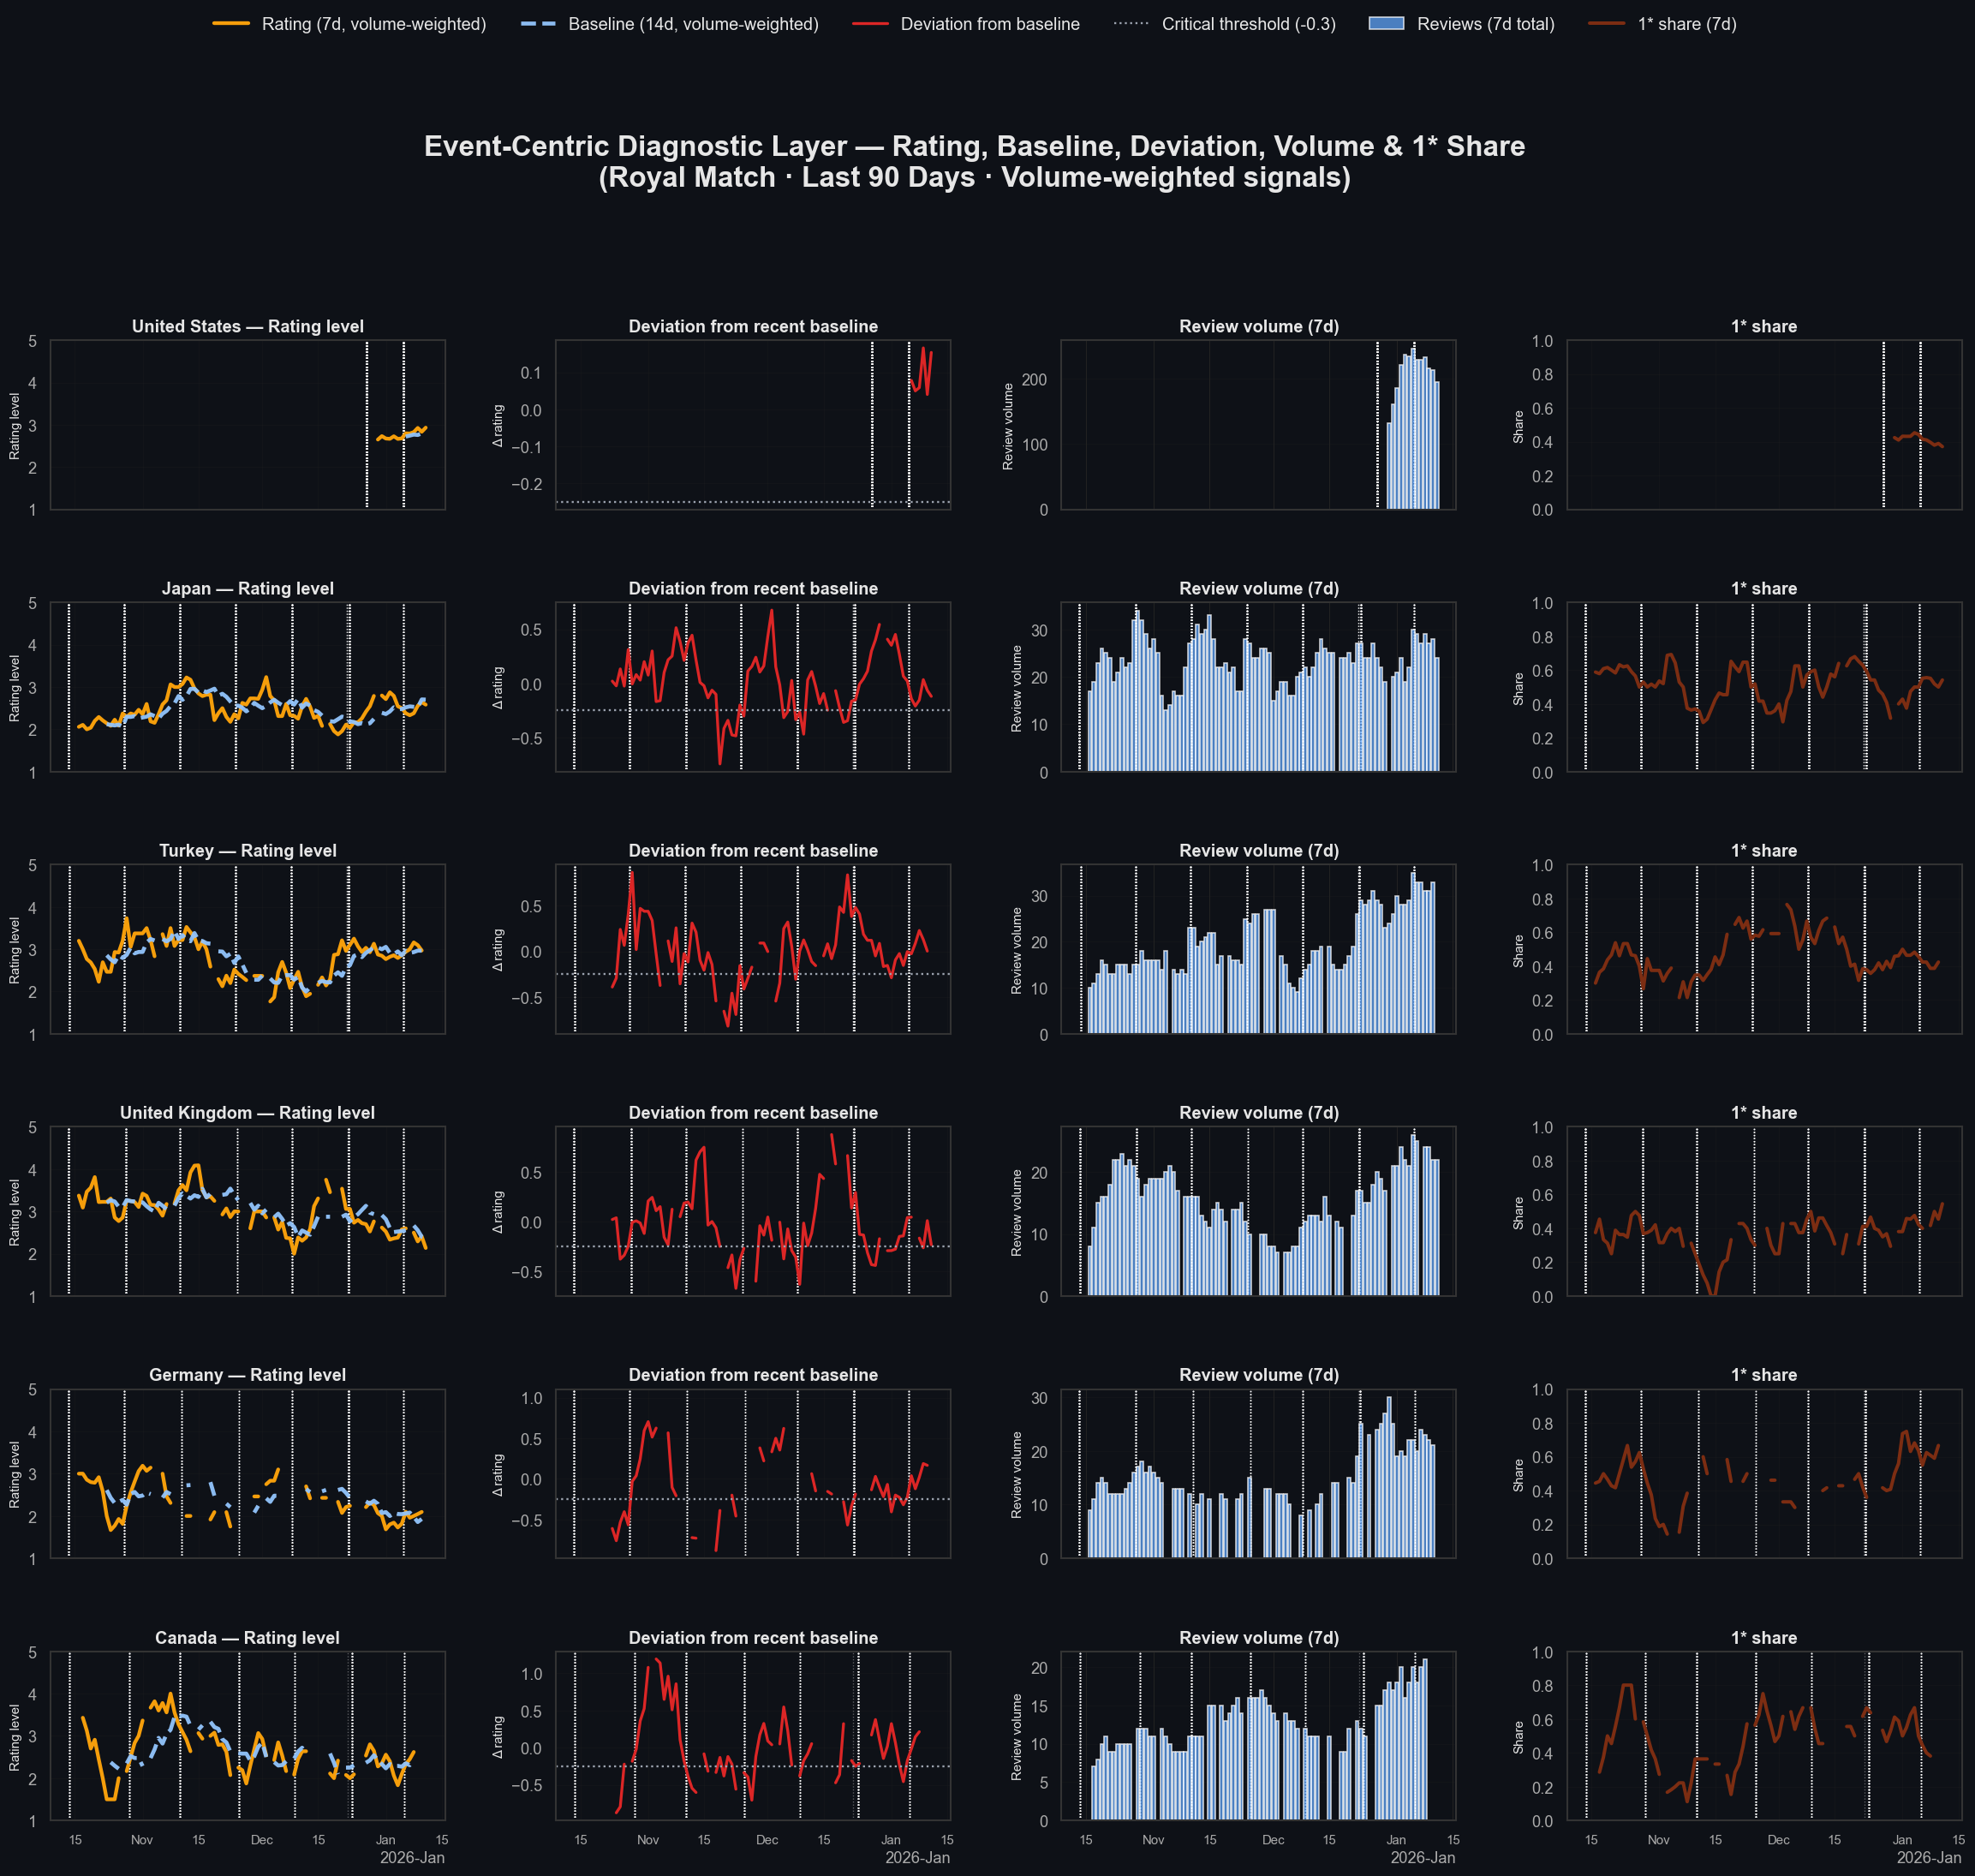

In [33]:
# =========================
# STEP 8.4b — EVENT-CENTRIC TIME SERIES (STACKED, LABELED)
# =========================

section("STEP 8.4b — EVENT-CENTRIC TIME SERIES (RM, LAST 90 DAYS)")

print("Update dates (unique, all countries):")
print(", ".join(pd.Series(df_rm_90["first_seen"].unique()).sort_values().dt.strftime("%Y-%m-%d").tolist()))

# -------------------------------------------------
# Colors (explicit & readable)
# -------------------------------------------------
COLOR_RATING   = "#F59E0B"   # rating_weighted_7d (orange)
COLOR_BASELINE = "#93C5FD"   # baseline_14d_rating (light blue)
COLOR_DELTA    = "#DC2626"   # deviation
COLOR_VOL      = "#60A5FA"   # volume
COLOR_P1       = "#7C2D12"   # 1★ share
COLOR_UPDATE   = "#FFFFFF"   # update marker (very subtle)
COLOR_THRESH   = "#9CA3AF"   # threshold

# -------------------------------------------------
# Typography
# -------------------------------------------------
SUBTITLE_FS = 12
YLABEL_FS   = 9
XLABEL_FS   = 9

# -------------------------------------------------
# Figure
# -------------------------------------------------
fig, axes = plt.subplots(
    nrows=len(countries),
    ncols=4,
    figsize=(24, 20),
    sharex=True
)

# Legend + suptitle için üstte ekstra boşluk
fig.subplots_adjust(top=0.83, hspace=0.55, wspace=0.28)

# -------------------------------------------------
# Loop per country
# -------------------------------------------------
for r, country in enumerate(countries):

    d0 = (
        df_roll[df_roll["country"] == country]
        .set_index("day")
        .reindex(all_days)
    )

    # --- Update dates
    updates = (
        df_rm_90.loc[df_rm_90["country"] == country, "first_seen"]
        .dropna()
        .sort_values()
    )
    updates = updates[(updates >= global_min) & (updates <= global_max)]

    # =========================
    # PANEL 1 — Rating level
    # =========================
    ax = axes[r, 0]
    ax.plot(
        d0.index,
        d0["rating_weighted_7d"],
        color=COLOR_RATING,
        lw=2.6,
        label="Rating (7d, volume-weighted)"
    )
    ax.plot(
        d0.index,
        d0["baseline_14d_rating"],
        color=COLOR_BASELINE,
        lw=2.8,            # thicker
        ls="--",
        alpha=0.95,
        label="Baseline (14d, volume-weighted)"
    )
    ax.set_ylim(1, 5)
    ax.set_ylabel("Rating level", fontsize=YLABEL_FS)
    ax.set_title(f"{country} — Rating level", fontsize=SUBTITLE_FS, fontweight="bold")
    ax.grid(alpha=0.25)

    # =========================
    # PANEL 2 — Deviation
    # =========================
    ax = axes[r, 1]
    ax.plot(
        d0.index,
        d0["delta_vs_baseline"],
        color=COLOR_DELTA,
        lw=2.0,
        label="Deviation from baseline"
    )
    ax.axhline(
        -0.25,
        color=COLOR_THRESH,
        lw=1.4,
        ls=":",
        label="Critical threshold (-0.3)"
    )
    ax.set_ylabel("Δ rating", fontsize=YLABEL_FS)
    ax.set_title("Deviation from recent baseline", fontsize=SUBTITLE_FS, fontweight="bold")
    ax.grid(alpha=0.25)

    # =========================
    # PANEL 3 — Review volume
    # =========================
    ax = axes[r, 2]
    ax.bar(
        d0.index,
        d0["n_reviews_7d"],
        color=COLOR_VOL,
        alpha=0.75,
        label="Reviews (7d total)"
    )
    ax.set_ylabel("Review volume", fontsize=YLABEL_FS)
    ax.set_title("Review volume (7d)", fontsize=SUBTITLE_FS, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

    # =========================
    # PANEL 4 — 1★ share
    # =========================
    ax = axes[r, 3]
    ax.plot(
        d0.index,
        d0["p1_7d"],
        color=COLOR_P1,
        lw=2.4,
        label="1* share (7d)"
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share", fontsize=YLABEL_FS)
    ax.set_title("1* share", fontsize=SUBTITLE_FS, fontweight="bold")
    ax.grid(alpha=0.25)

    # -------------------------
    # Update markers (all panels)
    # -------------------------
    for fs in updates:
        for c in range(4):
            axes[r, c].axvline(
                fs,
                color=COLOR_UPDATE,
                lw=0.8,
                ls=":",
                alpha=0.35,
                zorder=0
            )

# -------------------------------------------------
# X-axis formatting
# -------------------------------------------------
for ax in axes[-1]:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis="x", labelsize=XLABEL_FS)

# -------------------------------------------------
# GLOBAL LEGEND (top, shared)
# -------------------------------------------------
handles, labels = [], []
for ax in fig.axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# unique (preserve order)
seen = set()
uniq_handles, uniq_labels = [], []
for h, l in zip(handles, labels):
    if l and (l not in seen):
        seen.add(l)
        uniq_handles.append(h)
        uniq_labels.append(l)

fig.legend(
    uniq_handles,
    uniq_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),   # en üst
    ncol=6,
    frameon=False,
    fontsize=12
)

# -------------------------------------------------
# Main title (under legend)
# -------------------------------------------------
fig.suptitle(
    "Event-Centric Diagnostic Layer — Rating, Baseline, Deviation, Volume & 1* Share\n"
    "(Royal Match · Last 90 Days · Volume-weighted signals)",
    fontsize=20,
    fontweight="bold",
    y=0.93
)

plt.show()


### Step 8 Summary — Temporal Dynamics & Update Impact

#### Key decisions

- **Daily signals are too noisy for attribution on their own**, so we moved from raw daily averages (8.1) to a controlled diagnostic stack:  
  **7-day volume-weighted rating (min 4 days)** + **past-only 14-day volume-weighted baseline (min 10 days)** + **Δ vs baseline**.
- For event screening, we defined **critical drop candidates** using a conservative rule set:  
  **Δ vs baseline ≤ -0.30** and **n_reviews_7d ≥ min_reviews_7d(country)**.
- The minimum activity gate is **country-adaptive**:  
  `min_reviews_7d(c) = max(15, median_c(n_reviews_7d))`
- Because rating declines can span multiple days, we de-duplicated events by keeping only **local minima** in the delta series, turning threshold breaches into **event-level candidates** rather than fragmented daily flags.

#### What the diagnostics suggest

- Several markets show **event-shaped dynamics**: short-lived improvements around some update windows followed by renewed volatility and deterioration.
- **Oct 27 update window** aligns with a **visible upward drift** in multiple markets — most clearly **Turkey, Japan, and Germany** — suggesting a potentially broad, update-timed improvement.
- **Dec 22 update window** shows **meaningful positive movement in Japan and Turkey**, a distinct "improvement-type" window separate from the November turbulence.
- Not all update windows are positive: **Dec 8** shows a **clear deterioration signal** in **Turkey and Japan**, and **Dec 22** coincides with a **drop in the UK**, indicating that same-date windows can behave very differently by market.
- A cross-market clustering of drops around **Nov 25–Nov 27** provides a strong signal for a shared negative event window.

#### Downstream handoff

These temporal patterns identify **which update windows merit deeper investigation** through the downstream pipelines:

- **Topic modeling** can reveal whether the thematic composition of reviews shifts around critical drop dates (e.g., does difficulty or monetization spike post-update?).
- **LLM sentiment pipeline** can provide per-aspect sentiment shifts within event windows, replacing the crude 1★ share proxy with granular sentiment polarity.
- **Hypothesis testing notebook** can formalize the pre/post comparisons identified here (e.g., Nov 10 deterioration, Oct 27 uplift) with appropriate statistical tests and competitor controls.

## Step 9 — EDA Synthesis & Update Impact Preview

This final step brings together the key findings from the EDA and provides a compact, event-level view of update impacts.

Each update is treated as a localized intervention, evaluated through pre/post shifts in ratings and star distributions. The goal is not to test causality, but to identify which updates are directionally meaningful and worth deeper investigation through downstream pipelines (topic modeling, sentiment analysis, hypothesis testing).

The step closes with a synthesis of the notebook's key findings and an explicit handoff to downstream work.

In [34]:
# =========================
# STEP 9.1 — UPDATE EVENT LIST (ROYAL MATCH, 90D)
# =========================

section("STEP 9.1 — UPDATE EVENT LIST (ROYAL MATCH, 90D)")

# -------------------------------------------------
# Event definition:
# One update = first user-visible day of a version
# at country level
# -------------------------------------------------
df_events_90 = (
    df_rm_90[
        ["country", "version", "first_seen"]
    ]
    .dropna(subset=["country", "version", "first_seen"])
    .drop_duplicates(subset=["country", "version"])
    .rename(columns={"first_seen": "update_date"})
)

# --- Ensure date anchor
df_events_90["update_date"] = (
    pd.to_datetime(df_events_90["update_date"])
      .dt.floor("D")
)

# --- Canonical ordering
df_events_90 = (
    df_events_90
        .sort_values(["country", "update_date"])
        .reset_index(drop=True)
)

# --- Update sequence within country (cadence awareness)
df_events_90["update_seq_in_country"] = (
    df_events_90
        .groupby("country")["update_date"]
        .rank(method="dense")
        .astype(int)
)

# -------------------------
# Diagnostics
# -------------------------
print("Royal Match update events (90D) — preview:")
display(df_events_90.head(15))

print("\nUnique versions per country (90D):")
display(
    df_events_90
        .groupby("country")["version"]
        .nunique()
        .reset_index(name="n_versions_unique")
        .sort_values("n_versions_unique", ascending=False)
)

print(
    "\nTotal unique (country, version) events (90D):",
    df_events_90.shape[0]
)

print(
    "Date range:",
    df_events_90["update_date"].min(),
    "→",
    df_events_90["update_date"].max()
)


STEP 9.1 — UPDATE EVENT LIST (ROYAL MATCH, 90D)
Royal Match update events (90D) — preview:


,country,version,update_date,update_seq_in_country
0,Canada,31832,2025-10-13,1
1,Canada,32131,2025-10-28,2
2,Canada,32263,2025-11-10,3
3,Canada,32473,2025-11-25,4
4,Canada,32672,2025-12-09,5
5,Canada,32967,2025-12-22,6
6,Canada,32984,2025-12-23,7
7,Canada,33201,2026-01-05,8
8,Germany,31832,2025-10-13,1
9,Germany,32131,2025-10-27,2



Unique versions per country (90D):


,country,n_versions_unique
0,Canada,8
1,Germany,8
2,Japan,8
3,Turkey,8
4,United Kingdom,8
5,United States,2



Total unique (country, version) events (90D): 42
Date range: 2025-10-13 00:00:00 → 2026-01-05 00:00:00


In [35]:
# =========================
# STEP 9.2 — EVENT × DAILY OUTCOME ALIGNMENT (ROYAL MATCH)
# =========================

section("STEP 9.2 — EVENT × DAILY OUTCOME ALIGNMENT (ROYAL MATCH)")

# -------------------------------------------------
# Join: country-level alignment
# (df_roll already contains only Royal Match)
# -------------------------------------------------
df_event_daily = df_events_90.merge(
    df_roll,
    on="country",
    how="left"
)

# -------------------------------------------------
# Event-time axis
# -------------------------------------------------
df_event_daily["t"] = (
    df_event_daily["day"] - df_event_daily["update_date"]
).dt.days

# -------------------------------------------------
# Keep local diagnostic window only
# (no impact calculation yet)
# -------------------------------------------------
WINDOW_PRE  = 14
WINDOW_POST = 14

df_event_daily = df_event_daily.loc[
    (df_event_daily["t"] >= -WINDOW_PRE) &
    (df_event_daily["t"] <=  WINDOW_POST)
].reset_index(drop=True)

# -------------------------
# Diagnostics
# -------------------------
print("Event-aligned daily data — preview:")
display(
    df_event_daily[
        [
            "country",
            "version",
            "update_date",
            "day",
            "t",
            "rating_weighted_7d",
            "baseline_14d_rating",
            "p1_7d",
            "p5_7d",
            "n_reviews_7d",
            "is_critical_drop"
        ]
    ].head(5)
)

print("\nEvent-time coverage (row count by t):")
display(
    df_event_daily
        .groupby("t")["version"]
        .count()
        .reset_index(name="n_rows")
        .sort_values("t")
)



STEP 9.2 — EVENT × DAILY OUTCOME ALIGNMENT (ROYAL MATCH)
Event-aligned daily data — preview:


,country,version,update_date,day,t,rating_weighted_7d,baseline_14d_rating,p1_7d,p5_7d,n_reviews_7d,is_critical_drop
0,Canada,31832,2025-10-13,2025-10-13,0,NaN,NaN,NaN,NaN,NaN,False
1,Canada,31832,2025-10-13,2025-10-14,1,NaN,NaN,NaN,NaN,NaN,False
2,Canada,31832,2025-10-13,2025-10-15,2,NaN,NaN,NaN,NaN,NaN,False
3,Canada,31832,2025-10-13,2025-10-17,4,3.4286,NaN,0.2857,0.5714,7.0,False
4,Canada,31832,2025-10-13,2025-10-18,5,3.1250,NaN,0.3750,0.5000,8.0,False



Event-time coverage (row count by t):


,t,n_rows
0,-14,31
1,-13,33
2,-12,31
3,-11,28
4,-10,30
5,-9,33
6,-8,28
7,-7,32
8,-6,27
9,-5,28


>In this step, **daily Royal Match outcome** signals are aligned around each update event using an event-time axis.
This produces a day-by-day view of rating and star distribution dynamics before and after each update, without yet computing any impact metrics.


In [36]:
# -------------------------------------------------
# STEP 9.3a — POST window summary (t = 0..7)
# - rating: volume-weighted over daily avg_rating
# - p1/p5: computed from star counts over total reviews
# - volume: total daily n_reviews over the window
# -------------------------------------------------

df_event_post = (
    df_event_daily
        .loc[df_event_daily["t"].between(0, 7)]
        .groupby(["country", "version", "update_date"])
        .apply(lambda g: pd.Series({
            "post_rating_0_7": (g["avg_rating"] * g["n_reviews"]).sum() / g["n_reviews"].sum()
                              if g["n_reviews"].sum() > 0 else float("nan"),
            "post_p1_0_7": g["n_1star"].sum() / g["n_reviews"].sum()
                          if g["n_reviews"].sum() > 0 else float("nan"),
            "post_p5_0_7": g["n_5star"].sum() / g["n_reviews"].sum()
                          if g["n_reviews"].sum() > 0 else float("nan"),
            "post_n_reviews_sum_0_7": g["n_reviews"].sum()
        }), include_groups=False)
        .reset_index()
)

df_event_post.head()

,country,version,update_date,post_rating_0_7,post_p1_0_7,post_p5_0_7,post_n_reviews_sum_0_7
0,Canada,31832,2025-10-13,2.9091,0.4545,0.4545,11.0
1,Canada,32131,2025-10-28,3.8182,0.1818,0.5455,11.0
2,Canada,32263,2025-11-10,3.0714,0.2857,0.3571,14.0
3,Canada,32473,2025-11-25,2.6875,0.5625,0.3750,16.0
4,Canada,32672,2025-12-09,2.1429,0.5714,0.0000,7.0


In [37]:
# -------------------------------------------------
# STEP 9.3b — BASE window summary (t = -14..-1)
# - rating: volume-weighted over daily avg_rating
# - p1/p5: computed from star counts over total reviews
# - volume: total daily n_reviews over the window
# -------------------------------------------------

df_event_base = (
    df_event_daily
        .loc[df_event_daily["t"].between(-14, -1)]
        .groupby(["country", "version", "update_date"])
        .apply(lambda g: pd.Series({
            "base_rating_14d": (g["avg_rating"] * g["n_reviews"]).sum() / g["n_reviews"].sum()
                              if g["n_reviews"].sum() > 0 else float("nan"),
            "base_p1_14d": g["n_1star"].sum() / g["n_reviews"].sum()
                          if g["n_reviews"].sum() > 0 else float("nan"),
            "base_p5_14d": g["n_5star"].sum() / g["n_reviews"].sum()
                          if g["n_reviews"].sum() > 0 else float("nan"),
            "base_n_reviews_sum_14d": g["n_reviews"].sum()
        }), include_groups=False)
        .reset_index()
)

df_event_base.head()

,country,version,update_date,base_rating_14d,base_p1_14d,base_p5_14d,base_n_reviews_sum_14d
0,Canada,32131,2025-10-28,2.1250,0.6250,0.2500,16.0
1,Canada,32263,2025-11-10,3.5882,0.2353,0.4706,17.0
2,Canada,32473,2025-11-25,2.4783,0.4348,0.2174,23.0
3,Canada,32672,2025-12-09,2.6087,0.5652,0.3478,23.0
4,Canada,32967,2025-12-22,2.5385,0.4615,0.1538,13.0


### Post vs. Base Windows 

In this step, we build two event-level summaries for each update: **post** and **base**.  
For the **post** window (t = 0..7), we compute the *true* 7-day average rating by volume-weighting daily `avg_rating` with daily review counts (`n_reviews`), and we derive 1★/5★ shares using **total star counts divided by total reviews** (instead of averaging daily shares).  
For the **base** window (t = -14..-1), we apply the same measurement logic over the 14 days before the update, ensuring a **consistent baseline definition** for comparison with the post period.

**Note:** For some countries, the first observed version within the 90-day window may not have sufficient pre-history. In such cases, the base metrics cannot be computed and those updates are excluded from impact (delta) calculations.


In [38]:
# -------------------------------------------------
# STEP 9.3c — MERGE POST + BASE → EVENT SNAPSHOT
# -------------------------------------------------

df_event_snapshot = (
    df_event_post
        .merge(
            df_event_base,
            on=["country", "version", "update_date"],
            how="left"
        )
)

# Flag: base exists?
df_event_snapshot["has_base_14d"] = df_event_snapshot["base_rating_14d"].notna()

print("Snapshot preview:")
display(df_event_snapshot.head(10))

print("\nBase availability:")
print("Total events:", len(df_event_snapshot))
print("Has base (14d):", df_event_snapshot["has_base_14d"].sum())
print("Missing base (excluded later):", (~df_event_snapshot["has_base_14d"]).sum())

Snapshot preview:


,country,version,update_date,post_rating_0_7,post_p1_0_7,post_p5_0_7,post_n_reviews_sum_0_7,base_rating_14d,base_p1_14d,base_p5_14d,base_n_reviews_sum_14d,has_base_14d
0,Canada,31832,2025-10-13,2.9091,0.4545,0.4545,11.0,NaN,NaN,NaN,NaN,False
1,Canada,32131,2025-10-28,3.8182,0.1818,0.5455,11.0,2.1250,0.6250,0.2500,16.0,True
2,Canada,32263,2025-11-10,3.0714,0.2857,0.3571,14.0,3.5882,0.2353,0.4706,17.0,True
3,Canada,32473,2025-11-25,2.6875,0.5625,0.3750,16.0,2.4783,0.4348,0.2174,23.0,True
4,Canada,32672,2025-12-09,2.1429,0.5714,0.0000,7.0,2.6087,0.5652,0.3478,23.0,True
5,Canada,32967,2025-12-22,2.3077,0.6154,0.2308,13.0,2.5385,0.4615,0.1538,13.0,True
6,Canada,32984,2025-12-23,2.4375,0.5625,0.2500,16.0,2.3333,0.5333,0.1333,15.0,True
7,Canada,33201,2026-01-05,3.2857,0.1429,0.3571,14.0,2.0714,0.6429,0.1429,28.0,True
8,Germany,31832,2025-10-13,2.8125,0.4375,0.3750,16.0,NaN,NaN,NaN,NaN,False
9,Germany,32131,2025-10-27,2.8824,0.2353,0.2353,17.0,2.3793,0.5172,0.2414,29.0,True



Base availability:
Total events: 42
Has base (14d): 36
Missing base (excluded later): 6


In [39]:
# =========================
# STEP 9.4 — BEST / WORST UPDATES (GLOBAL, COUNTRY-NORMALIZED SCORES)
# =========================

section("STEP 9.4 — BEST / WORST UPDATES (GLOBAL, COUNTRY-NORMALIZED SCORES)")

TOP_N = 10

# --- Delta metrics (directional)
df_event_snapshot["delta_rating"] = (
    df_event_snapshot["post_rating_0_7"] - df_event_snapshot["base_rating_14d"]
)
df_event_snapshot["delta_p1"] = (
    df_event_snapshot["post_p1_0_7"] - df_event_snapshot["base_p1_14d"]
)
df_event_snapshot["delta_p5"] = (
    df_event_snapshot["post_p5_0_7"] - df_event_snapshot["base_p5_14d"]
)

# --- Effective sample size (bottleneck side: post vs base)
df_event_snapshot["n_eff"] = df_event_snapshot[
    ["post_n_reviews_sum_0_7", "base_n_reviews_sum_14d"]
].min(axis=1)

# --- Country-typical volume (median) for normalization
country_med = (
    df_event_snapshot.loc[df_event_snapshot["has_base_14d"]]
        .groupby("country")["n_eff"]
        .median()
)

df_event_snapshot["n_eff_country_med"] = df_event_snapshot["country"].map(country_med)

# --- Normalized effective sample size (relative to each country's typical volume)
df_event_snapshot["n_eff_norm"] = df_event_snapshot["n_eff"] / df_event_snapshot["n_eff_country_med"]

# --- Shared weight (same for all outcomes)
df_event_snapshot["w_eff"] = df_event_snapshot["n_eff_norm"] ** 0.5

# --- Global scores (country-normalized)
df_event_snapshot["score_rating"] = df_event_snapshot["delta_rating"] * df_event_snapshot["w_eff"]
df_event_snapshot["score_p1"]     = df_event_snapshot["delta_p1"]     * df_event_snapshot["w_eff"] * -1
df_event_snapshot["score_p5"]     = df_event_snapshot["delta_p5"]     * df_event_snapshot["w_eff"] 

# -------------------------
# Rating ranking 
# -------------------------
print("Worst updates (by score_rating):")
display(
    df_event_snapshot
        .loc[df_event_snapshot["has_base_14d"]]
        .sort_values("score_rating", ascending=True)
        .head(TOP_N)
)

print("\nBest updates (by score_rating):")
display(
    df_event_snapshot
        .loc[df_event_snapshot["has_base_14d"]]
        .sort_values("score_rating", ascending=False)
        .head(TOP_N)
)





STEP 9.4 — BEST / WORST UPDATES (GLOBAL, COUNTRY-NORMALIZED SCORES)
Worst updates (by score_rating):


,country,version,update_date,post_rating_0_7,post_p1_0_7,post_p5_0_7,post_n_reviews_sum_0_7,base_rating_14d,base_p1_14d,base_p5_14d,base_n_reviews_sum_14d,has_base_14d,delta_rating,delta_p1,delta_p5,n_eff,n_eff_country_med,n_eff_norm,w_eff,score_rating,score_p1,score_p5
2,Canada,32263,2025-11-10,3.0714,0.2857,0.3571,14.0,3.5882,0.2353,0.4706,17.0,True,-0.5168,0.0504,-0.1134,14.0,14.0,1.0000,1.0000,-0.5168,-0.0504,-0.1134
38,United Kingdom,32984,2025-12-22,2.5909,0.3636,0.2273,22.0,3.0000,0.4091,0.4091,22.0,True,-0.4091,-0.0455,-0.1818,22.0,20.0,1.1000,1.0488,-0.4291,0.0477,-0.1907
37,United Kingdom,32967,2025-12-22,2.5909,0.3636,0.2273,22.0,3.0000,0.4091,0.4091,22.0,True,-0.4091,-0.0455,-0.1818,22.0,20.0,1.1000,1.0488,-0.4291,0.0477,-0.1907
27,Turkey,32473,2025-11-24,2.3704,0.5926,0.2963,27.0,2.7222,0.5278,0.3611,36.0,True,-0.3519,0.0648,-0.0648,27.0,27.0,1.0000,1.0000,-0.3519,-0.0648,-0.0648
20,Japan,32672,2025-12-08,2.3214,0.5714,0.2500,28.0,2.6667,0.4222,0.2667,45.0,True,-0.3452,0.1492,-0.0167,28.0,27.0,1.0370,1.0184,-0.3516,-0.1519,-0.0170
39,United Kingdom,33201,2026-01-05,2.1500,0.5500,0.1500,20.0,2.5000,0.4211,0.2368,38.0,True,-0.3500,0.1289,-0.0868,20.0,20.0,1.0000,1.0000,-0.3500,-0.1289,-0.0868
4,Canada,32672,2025-12-09,2.1429,0.5714,0.0000,7.0,2.6087,0.5652,0.3478,23.0,True,-0.4658,0.0062,-0.3478,7.0,14.0,0.5000,0.7071,-0.3294,-0.0044,-0.2460
12,Germany,32672,2025-12-08,2.6667,0.3333,0.2222,9.0,3.1000,0.3000,0.4000,10.0,True,-0.4333,0.0333,-0.1778,9.0,16.0,0.5625,0.7500,-0.3250,-0.0250,-0.1333
28,Turkey,32672,2025-12-08,2.1579,0.6316,0.1579,19.0,2.4375,0.5625,0.3125,32.0,True,-0.2796,0.0691,-0.1546,19.0,27.0,0.7037,0.8389,-0.2346,-0.0579,-0.1297
5,Canada,32967,2025-12-22,2.3077,0.6154,0.2308,13.0,2.5385,0.4615,0.1538,13.0,True,-0.2308,0.1538,0.0769,13.0,14.0,0.9286,0.9636,-0.2224,-0.1482,0.0741



Best updates (by score_rating):


,country,version,update_date,post_rating_0_7,post_p1_0_7,post_p5_0_7,post_n_reviews_sum_0_7,base_rating_14d,base_p1_14d,base_p5_14d,base_n_reviews_sum_14d,has_base_14d,delta_rating,delta_p1,delta_p5,n_eff,n_eff_country_med,n_eff_norm,w_eff,score_rating,score_p1,score_p5
1,Canada,32131,2025-10-28,3.8182,0.1818,0.5455,11.0,2.1250,0.6250,0.2500,16.0,True,1.6932,-0.4432,0.2955,11.0,14.0,0.7857,0.8864,1.5008,0.3928,0.2619
11,Germany,32473,2025-11-25,3.7143,0.1429,0.5714,7.0,1.7500,0.5000,0.0833,12.0,True,1.9643,-0.3571,0.4881,7.0,16.0,0.4375,0.6614,1.2993,0.2362,0.3228
7,Canada,33201,2026-01-05,3.2857,0.1429,0.3571,14.0,2.0714,0.6429,0.1429,28.0,True,1.2143,-0.5000,0.2143,14.0,14.0,1.0000,1.0000,1.2143,0.5000,0.2143
25,Turkey,32131,2025-10-27,3.5294,0.2941,0.5294,17.0,2.7931,0.4483,0.3448,29.0,True,0.7363,-0.1542,0.1846,17.0,27.0,0.6296,0.7935,0.5843,0.1223,0.1465
17,Japan,32131,2025-10-27,2.6296,0.5185,0.3333,27.0,2.0612,0.5918,0.1429,49.0,True,0.5684,-0.0733,0.1905,27.0,27.0,1.0000,1.0000,0.5684,0.0733,0.1905
9,Germany,32131,2025-10-27,2.8824,0.2353,0.2353,17.0,2.3793,0.5172,0.2414,29.0,True,0.5030,-0.2819,-0.0061,17.0,16.0,1.0625,1.0308,0.5185,0.2906,-0.0063
22,Japan,32984,2025-12-22,2.6538,0.3846,0.3077,26.0,2.1739,0.6087,0.2174,46.0,True,0.4799,-0.2241,0.0903,26.0,27.0,0.9630,0.9813,0.4710,0.2199,0.0886
21,Japan,32967,2025-12-22,2.6538,0.3846,0.3077,26.0,2.1739,0.6087,0.2174,46.0,True,0.4799,-0.2241,0.0903,26.0,27.0,0.9630,0.9813,0.4710,0.2199,0.0886
30,Turkey,32984,2025-12-22,3.0000,0.4194,0.4194,31.0,2.6216,0.4865,0.2973,37.0,True,0.3784,-0.0671,0.1221,31.0,27.0,1.1481,1.0715,0.4054,0.0719,0.1308
29,Turkey,32967,2025-12-22,3.0000,0.4194,0.4194,31.0,2.6216,0.4865,0.2973,37.0,True,0.3784,-0.0671,0.1221,31.0,27.0,1.1481,1.0715,0.4054,0.0719,0.1308



STEP 9.5 — DELTA SCATTER (BY COUNTRY, ALL EVENTS, PALETTE)


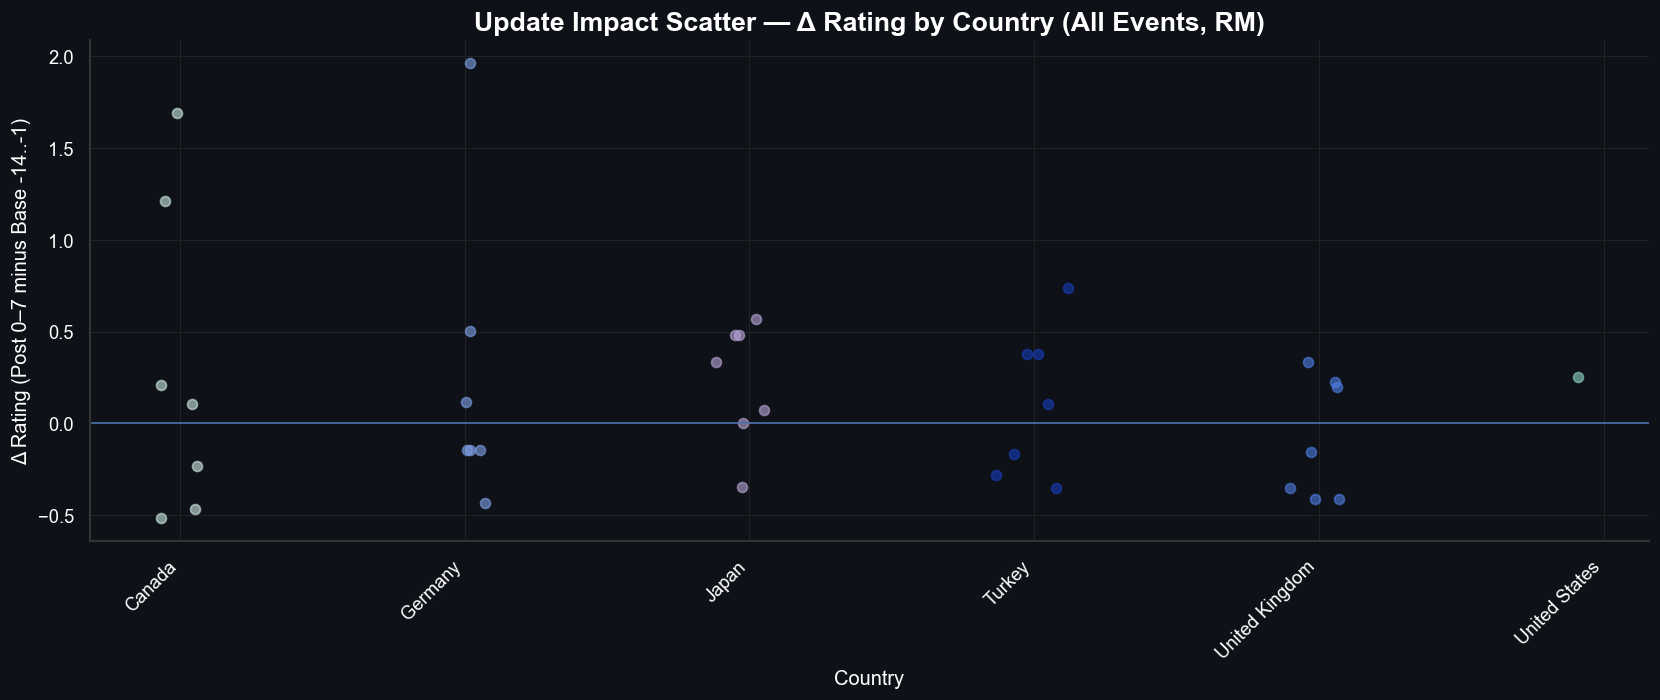

In [40]:
# =========================
# STEP 9.5 — DELTA SCATTER BY COUNTRY (WITH COUNTRY PALETTE)
# =========================

section("STEP 9.5 — DELTA SCATTER (BY COUNTRY, ALL EVENTS, PALETTE)")

df_plot = df_event_snapshot.loc[df_event_snapshot["has_base_14d"]].copy()

# --- Country order: most events first (readability)
country_order = (
    df_plot["country"]
        .value_counts()
        .index
        .tolist()
)

# --- x positions + jitter for visibility
country_to_x = {c: i for i, c in enumerate(country_order)}
x = df_plot["country"].map(country_to_x).astype(float).values

rng = np.random.default_rng(42)
x_j = x + rng.normal(0, 0.08, size=len(df_plot))

y = df_plot["delta_rating"].values

# --- Colors from your palette (fallback if any unexpected country appears)
df_plot["color"] = df_plot["country"].map(COUNTRY_PALETTE).fillna("#9CA3AF")

plt.figure(figsize=(14, 6))

# Plot each country separately to get correct colors + legend
for c in country_order:
    d = df_plot[df_plot["country"] == c]
    x_c = d["country"].map(country_to_x).astype(float).values + rng.normal(0, 0.08, size=len(d))
    plt.scatter(
        x_c,
        d["delta_rating"].values,
        alpha=0.6,
        label=c,
        c=d["color"].iloc[0]
    )

# --- Baseline line
plt.axhline(0, linewidth=1)

# --- Axes labels + ticks (labels in white)
plt.xticks(range(len(country_order)), country_order, rotation=45, ha="right", color="white")
plt.yticks(color="white")
plt.xlabel("Country", color="white")
plt.ylabel("Δ Rating (Post 0–7 minus Base -14..-1)", color="white")
plt.title("Update Impact Scatter — Δ Rating by Country (All Events, RM)", color="white", fontsize=16, fontweight="bold")

# --- Make spines visible on dark background (if you use dark theme)
ax = plt.gca()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### Step 9 Summary — Update Impact Preview

#### Methodology

This step translated the temporal diagnostics from Step 8 into an **update-impact view** at the country × version level. Each update event is summarized using a consistent pre/post design (**Base: t = −14..−1**, **Post: t = 0..7**) with **true volume-weighted metrics** (Σ avg_rating·n / Σ n) and count-based 1★/5★ shares (Σ n_1star / Σ n) to avoid "averages of averages."

**⚠ Important caveat on version data:** The version field in App Store RSS reflects the **current app version on the store at the time of review submission**, not the version the user actually has installed. This means pre/post windows are approximations based on store-level version transitions, not user-level update events. Observed rating shifts may therefore include reviews from users on older versions. This limitation should be considered when interpreting update-level effects; formal hypothesis testing (Notebook 5) confirmed that neither the strongest negative nor positive update candidate produced a statistically significant sentiment shift.

For global ranking, we used `n_eff = min(post_reviews, base_reviews)` normalized by each country's median, so the score reflects **impact magnitude** rather than market size. Updates without sufficient pre-history (6 of 42 events) were excluded from delta calculations.

#### Key findings

- **Dec 8–9 (v32672)** is the clearest negative event: consistent **1★ share increase** and **5★ share decrease** across multiple markets (TR/JP/DE/CA), supporting an update-driven deterioration rather than isolated noise.
- **v32131 (Oct 27–28)** is the clearest positive event: clean improvement pattern (1★ down, 5★ up) across multiple markets (TR/JP/DE), providing a strong reference for what a "good update" looks like in the data.
- **Dec 22** remains heterogeneous: UK shows a rating drop driven by 5★ decreasing, while TR/JP show improvement — reinforcing that same-date windows can behave very differently by market.
- **v32473** illustrates cross-market divergence (strongly negative in TR but positive in DE), making market-specific drill-down essential.
- The **delta scatter** confirms that most updates produce small shifts (|Δ| < 0.5), with a few high-impact outliers in both directions — primarily in lower-volume markets (Canada, Germany) where small sample sizes amplify deltas.

---

## EDA Notebook — Closing Summary

### What this notebook accomplished

This EDA established a **clean, structured, and well-documented analytical foundation** for Royal Match App Store review data across 6 markets, 4 games, and a 2025+ analysis scope.

#### Coverage & data quality (Steps 0–5)
- Raw data was loaded, parsed, and validated with an immutable raw table preserved throughout.
- A **2025+ analysis scope** was defined to ensure temporal comparability, yielding **9,630 reviews** across 4 games and 6 countries.
- **Language detection** (fastText) cleanly separated EN/TR/DE reviews from Japanese and other unsupported languages, enabling language-aware downstream work.

#### Text-based exploration (Step 6)
- Rule-based theme detection surfaced **directional friction signals** — ads intrusion, monetization, rewards, and difficulty emerged as the most prevalent themes at roughly comparable rates (13–16%).
- **Loyal players who complain** most frequently cite difficulty (34%) and rewards (31%) — a product-relevant finding.
- A **preliminary mixed sentiment proxy** (~9.4%) identified high-rating reviews with friction keywords, though this is a crude approximation awaiting proper sentiment classification.

#### Rating landscape (Step 7)
- All games show **strongly bimodal distributions** (1★ and 5★ dominant), confirming the polarized nature of App Store written reviews.
- **Toon Blast** is the competitive benchmark — leading in nearly every market.
- **UK** is the closest competitive parity zone for Royal Match; **Germany and Japan** are structurally challenging markets.
- Within each market, **lower ratings correlate with longer reviews** — a consistent behavioral signal.

#### Temporal dynamics (Step 8)
- Daily signals are too noisy for direct attribution; a controlled diagnostic stack (7d volume-weighted rolling + 14d past-only baseline + Δ vs baseline) was built to surface meaningful movements.
- **Critical drop detection** identified event candidates with conservative thresholds (Δ ≤ −0.30, country-adaptive volume gates, local minima filtering).
- Several update windows show clear event-shaped dynamics: Oct 27 (multi-market uplift), Dec 8 (multi-market deterioration), Dec 22 (heterogeneous).

#### Update impact (Step 9)
- Pre/post event-level analysis confirmed **Dec 8 (v32672)** as the strongest negative update and **Oct 27 (v32131)** as the strongest positive, both with multi-market evidence.
- Cross-market heterogeneity is a recurring pattern — the same version can produce opposite effects in different markets.

### Downstream handoff

This EDA provides explicit inputs for three downstream pipelines:

**1. Topic Modeling (BERTopic)**
- Input: `reviews_topic_scope_2025.csv` (EN/TR/DE reviews, exported in Step 6.1)
- Key question: Do the primitive rule-based themes hold up under unsupervised topic discovery? Which finer-grained topics emerge within broad friction categories?

**2. Sentiment Analysis & ABSA**
- Input: `reviews_sentiment_scope_2025.csv` (with temporal and version context, exported in Step 6.1)
- Key question: Can per-aspect sentiment polarity replace the crude mixed sentiment proxy? Do sentiment shifts align with the critical drop / uplift windows identified here?

**3. Hypothesis Testing**
- Key windows to formalize: Dec 8 (v32672) deterioration, Oct 27 (v32131) uplift, Dec 22 heterogeneous behavior
- Market-specific tests needed: cross-market divergence cases (v32473) require separate treatment per market
- Competitor controls: same-window competitor behavior should be checked to distinguish product-specific from category-wide effects